# CHronoZ Delta Transformation Analysis

Explore the distributions of one native-period change for all 36 cleaned economic series. Scroll through standalone figures in Sections 3-7. Exploratory research only: no benchmark construction, model training, outlier removal, resampling, or source edits.

## 1. Dataset Inventory

The first table lists every cleaned dataset. Inputs: cleaned CSVs, series_metadata.csv, cleaning audit, and Resources.md. Dependencies: requirements-notebook.txt. Run all cells from the repository or a notebook subfolder.

In [1]:
from pathlib import Path
import hashlib, re, textwrap, platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data/cleaned/series_metadata.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Run inside the CHronoZ repository.')
metadata = pd.read_csv(ROOT/'data/cleaned/series_metadata.csv')
audit = pd.read_csv(ROOT/'data/audit/data_cleaning_audit.csv').set_index('series_id')
resources = (ROOT/'Resources.md').read_text(encoding='utf-8')
def sha256(p):
    return hashlib.sha256(p.read_bytes()).hexdigest()
source_paths = sorted((ROOT/'data/cleaned').glob('*.csv')) + [ROOT/'Resources.md', ROOT/'data/audit/data_cleaning_audit.csv']
source_hashes = {str(p.relative_to(ROOT)): sha256(p) for p in source_paths}
def table(frame):
    display(HTML(frame.to_html(index=False, float_format=lambda x: f'{x:,.4g}', escape=True)))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'figure.facecolor':'white','figure.dpi':100,'axes.spines.top':False,'axes.spines.right':False})
MAX_BINS = 80
DISPLAY_NAMES = {'BUSLOANS': 'Commercial & Industrial Loans', 'DRBLACBS': 'Delinquency Rate on Business Loans', 'DRSDCILM': 'SLOOS: Stronger Demand for C&I Loans', 'DRTSCILM': 'SLOOS: Banks Tightening C&I Lending Standards', 'TOTALSL': 'Consumer Credit', 'EXPGSC1': 'Real Exports of Goods and Services', 'IMPGSC1': 'Real Imports of Goods and Services', 'OPHNFB': 'Nonfarm Business Sector Labor Productivity', 'TCU': 'Total Capacity Utilization', 'HOUST': 'Housing Starts', 'INDPRO': 'Industrial Production', 'IPMAN': 'Manufacturing Production', 'PCEC96': 'Real Personal Consumption Expenditure', 'PERMIT': 'Building Permits', 'RPI': 'Real Personal Income', 'RRSFS': 'Real Retail & Food Services Sales', 'W875RX1': 'Real Personal Income excluding transfers', 'CPIAUCSL': 'CPI All Items', 'CPILFESL': 'Core CPI', 'PCEPI': 'PCE Price Index', 'PCEPILFE': 'Core PCE Price Index', 'PPIACO': 'Producer Prices — All Commodities', 'PPIFID': 'Producer Prices — Final Demand', 'AWHAETP': 'Average Weekly Hours — Total Private', 'AWHMAN': 'Average Weekly Hours — Manufacturing', 'CES0500000003': 'Average Hourly Earnings — Total Private', 'CIVPART': 'Labor Force Participation Rate', 'ICSA': 'Initial Claims', 'JTSJOL': 'Job Openings', 'PAYEMS': 'Nonfarm Payroll Employment', 'UNRATE': 'Unemployment Rate', 'FEDFUNDS': 'Federal Funds Rate', 'M2SL': 'M2 Money Supply', 'TOTRESNS': 'Total Bank Reserves', 'WALCL': 'Federal Reserve Total Assets', 'WRESBAL': 'Reserve Balances with Federal Reserve Banks'}

In [2]:
FAMILY_IDS = {
 'growth': 'INDPRO IPMAN PCEC96 W875RX1 RPI RRSFS HOUST PERMIT PAYEMS JTSJOL CES0500000003 CPIAUCSL CPILFESL PCEPI PCEPILFE PPIFID PPIACO BUSLOANS TOTALSL M2SL EXPGSC1 IMPGSC1 OPHNFB'.split(),
 'first_difference': 'UNRATE AWHAETP AWHMAN CIVPART FEDFUNDS TCU'.split(),
 'stress': ['ICSA','DRBLACBS'], 'semantic_balance': ['DRTSCILM','DRSDCILM'],
 'regime_sensitive': ['TOTRESNS','WRESBAL','WALCL']}
FAMILY_NAMES = {'growth':'Log-growth / percentage-growth mode','first_difference':'First-difference mode',
 'stress':'Exploratory stress delta','semantic_balance':'Semantic-balance mode',
 'regime_sensitive':'REGIME-SENSITIVE - DELTA ANALYSIS ONLY'}
REASONS = {
 'growth':'Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.',
 'first_difference':'Point/hour changes retain the economic meaning of rates, utilization, and hours; percentage growth can be misleading.',
 'stress':'Event-sensitive stress measure; right tails do not automatically indicate secular growth. Compare absolute and proportional changes.',
 'semantic_balance':'Native zero remains economically meaningful. Delta measures momentum, not a replacement for the level.',
 'regime_sensitive':'Delta is useful, but liquidity/policy regime changes may persist after transformation.'}
registry = {}
for family, ids in FAMILY_IDS.items():
 for sid in ids:
    assert sid not in registry
    methods = ['log_change','percentage_change'] if family=='growth' else ['absolute_delta'] if family in {'first_difference','semantic_balance'} else ['absolute_delta','percentage_change','log_change']
    housing = sid in {'HOUST','PERMIT'}
    if housing: methods = methods + ['absolute_delta']
    registry[sid] = {'family':family,'candidate_delta_family':FAMILY_NAMES[family],'transformations':methods,
       'delta_suitability':'MEDIUM' if housing else 'SPECIAL_CASE' if family in {'stress','semantic_balance','regime_sensitive'} else 'HIGH',
       'reason':'Positive housing quantity with strong cyclicality; compare growth and native-unit change without presuming a secular trend.' if housing else REASONS[family]}
assert len(metadata)==36 and metadata.series_id.is_unique and set(registry)==set(metadata.series_id)
raw_data, descriptions, inventory_rows = {}, {}, []
for r in metadata.itertuples(index=False):
    d = pd.read_csv(ROOT/'data/cleaned'/f'{r.series_id}.csv')
    assert list(d)==['date','value']
    d['date']=pd.to_datetime(d.date,errors='raise'); d['value']=pd.to_numeric(d.value,errors='raise')
    assert d.date.notna().all() and d.date.is_unique and d.date.is_monotonic_increasing
    assert np.isfinite(d.value).all()
    assert len(d)==r.valid_observations==audit.loc[r.series_id,'clean_rows']
    assert str(d.date.min().date())==r.first_date and str(d.date.max().date())==r.last_date
    assert r.expected_frequency in {'weekly','monthly','quarterly'}
    if r.expected_frequency!='weekly':
        assert d.date.dt.to_period('M' if r.expected_frequency=='monthly' else 'Q').is_unique
    pattern = r'^## '+re.escape(r.series_id)+r' .*?\*\*Representasi real world\*\*\s*(.*?)\n\n'
    match=re.search(pattern,resources,re.M|re.S)
    assert match, r.series_id
    descriptions[r.series_id]=match.group(1).strip()
    raw_data[r.series_id]=d
    spec=registry[r.series_id]
    inventory_rows.append({'series_id':r.series_id,'dataset_name':DISPLAY_NAMES[r.series_id],'category':r.category,
      'frequency':r.expected_frequency,'start_date':r.first_date,'end_date':r.last_date,'observations':len(d),
      'candidate_delta_family':spec['candidate_delta_family'],'delta_suitability':spec['delta_suitability'],'reason':spec['reason']})
inventory=pd.DataFrame(inventory_rows)
table(inventory)


series_id,dataset_name,category,frequency,start_date,end_date,observations,candidate_delta_family,delta_suitability,reason
INDPRO,Industrial Production,growth_activity,monthly,1919-01-01,2026-07-01,1291,Log-growth / percentage-growth mode,HIGH,"Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family."
IPMAN,Manufacturing Production,growth_activity,monthly,1972-01-01,2026-07-01,655,Log-growth / percentage-growth mode,HIGH,"Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family."
PCEC96,Real Personal Consumption Expenditure,growth_activity,monthly,2007-01-01,2026-07-01,235,Log-growth / percentage-growth mode,HIGH,"Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family."
W875RX1,Real Personal Income excluding transfers,growth_activity,monthly,1959-01-01,2026-07-01,811,Log-growth / percentage-growth mode,HIGH,"Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family."
RPI,Real Personal Income,growth_activity,monthly,1959-01-01,2026-07-01,811,Log-growth / percentage-growth mode,HIGH,"Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family."
RRSFS,Real Retail & Food Services Sales,growth_activity,monthly,1992-01-01,2026-08-01,415,Log-growth / percentage-growth mode,HIGH,"Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family."
HOUST,Housing Starts,growth_activity,monthly,1959-01-01,2026-08-01,812,Log-growth / percentage-growth mode,MEDIUM,Positive housing quantity with strong cyclicality; compare growth and native-unit change without presuming a secular trend.
PERMIT,Building Permits,growth_activity,monthly,1960-01-01,2026-08-01,800,Log-growth / percentage-growth mode,MEDIUM,Positive housing quantity with strong cyclicality; compare growth and native-unit change without presuming a secular trend.
PAYEMS,Nonfarm Payroll Employment,labor,monthly,1939-01-01,2026-08-01,1052,Log-growth / percentage-growth mode,HIGH,"Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family."
UNRATE,Unemployment Rate,labor,monthly,1948-01-01,2026-08-01,943,First-difference mode,HIGH,"Point/hour changes retain the economic meaning of rates, utilization, and hours; percentage growth can be misleading."


## 2. Methodology

**Formulas.** Absolute delta = X(t) - X(t-1); percentage change = 100 * (X(t)/X(t-1) - 1); log change = 100 * (log X(t) - log X(t-1)). Log units are 100 times the log ratio: approximately percent for small moves, not exact percent. No annualization or future values enter these transforms.

**Native frequency.** delta_horizon = native_frequency_step. Weekly pairs require exactly 7 days; monthly/quarterly pairs must occupy consecutive calendar periods. No filling or resampling. The initial row is unavailable, not a skipped gap. Exclusions are disjoint: gap, nonfinite input, nonpositive endpoint for proportional candidates, then nonfinite output. Signed balances and rates use differences only.

**Economic registry.** The existing correlation notebook uses monthly percent changes and first differences. This study adds log growth, all weekly/quarterly series, housing absolute-change diagnostics, and separate stress, semantic-balance, and regime-sensitive families. Positivity was inspected. HIGH means economic interpretability, not normality/stability. Housing is MEDIUM; stress, semantic-balance, and liquidity variables are SPECIAL_CASE.

**Statistics.** Sample standard deviation uses ddof=1. MAD is unscaled median absolute deviation from the median. Quantiles use linear interpolation. Skewness and excess kurtosis use pandas bias-corrected sample estimators. Normal-reference excess kurtosis is zero; normality is not assumed. Mean-median gaps retain units: do not rank across incompatible units/frequencies.

**Descriptive labels.** Below 60 observations: insufficient_history. Otherwise absolute skewness <= 0.5: approximately_symmetric; larger signed values: right_skewed or left_skewed. Excess kurtosis > 3 adds heavy_tailed; > 10 adds highly_heavy_tailed. Undefined moments are labeled explicitly. These are exploratory thresholds, not tests. Multimodality and instability require further diagnostics and are not inferred from moments.

**Raw/change comparison.** Raw moments use the same ending dates as each eligible change. Lower absolute skewness/kurtosis is descriptive only, not proof of stationarity or benchmark quality. Full-history distributions pool regimes and use the sample retrospectively, not as forecasts. Inputs can include revisions; release timing and seasonal-adjustment metadata are unavailable. No new seasonal adjustment is inferred/applied.

**Charts.** Each candidate has a standalone histogram and horizontal boxplot sharing a full-range x-axis. NumPy auto bins capped at 80. No clipping, winsorizing, or crisis removal. Axes vary across figures: compare numbers/units, not widths. Full unit scales are absent in metadata: quantities use native-unit change; rates use percentage points; hours use hours.

In [3]:
def consecutive_pairs(dates, frequency):
    if frequency=='weekly': return dates.diff().eq(pd.Timedelta(days=7))
    return dates.dt.to_period({'monthly':'M','quarterly':'Q'}[frequency]).astype('int64').diff().eq(1)
def calculate_delta(data, frequency, method):
    a,b=data.value,data.value.shift(1)
    has_previous=pd.Series(np.arange(len(data))>0,index=data.index)
    consecutive=consecutive_pairs(data.date,frequency)
    gap=has_previous & ~consecutive
    finite=np.isfinite(a)&np.isfinite(b)
    bad_input=has_previous & consecutive & ~finite
    eligible=has_previous & consecutive & finite
    nonpositive=pd.Series(False,index=data.index)
    if method in {'log_change','percentage_change'}:
        nonpositive=eligible & ((a<=0)|(b<=0)); eligible=eligible & ~nonpositive
    x,y=a.where(eligible),b.where(eligible)
    with np.errstate(divide='ignore',invalid='ignore',over='ignore'):
        if method=='absolute_delta': result=x-y
        elif method=='percentage_change': result=100*(x/y-1)
        elif method=='log_change': result=100*(np.log(x)-np.log(y))
        else: raise ValueError(method)
    bad_result=eligible & ~np.isfinite(result)
    result=result.where(eligible & ~bad_result)
    checks={'valid_observations':int(result.notna().sum()),'skipped_gap_pairs':int(gap.sum()),
            'nonpositive_skipped':int(nonpositive.sum()),'nonfinite_skipped':int(bad_input.sum()+bad_result.sum())}
    assert sum(checks.values())==len(data)-1
    return result,checks
def stats(values):
    s=pd.Series(values).dropna(); median=s.median()
    out={'count':len(s),'mean':s.mean(),'median':median,'std':s.std(ddof=1),'MAD':(s-median).abs().median(),
         'minimum':s.min(),'maximum':s.max(),'skewness':s.skew(),'kurtosis':s.kurt(),'mean_minus_median':s.mean()-median}
    out.update({f'q{q:02d}':s.quantile(q/100) for q in [1,5,10,25,50,75,90,95,99]})
    return out
def behavior(s):
    if s['count']<60: return 'insufficient_history'
    if not np.isfinite([s['skewness'],s['kurtosis']]).all(): return 'undefined_moments'
    label='approximately_symmetric' if abs(s['skewness'])<=0.5 else 'right_skewed' if s['skewness']>0 else 'left_skewed'
    if s['kurtosis']>10: label+='; highly_heavy_tailed'
    elif s['kurtosis']>3: label+='; heavy_tailed'
    return label
# Native gap and denominator boundary checks.
for frequency,dates in {'monthly':['2025-09-01','2025-11-01','2025-12-01'],
                       'weekly':['2025-01-01','2025-01-15','2025-01-22'],
                       'quarterly':['2025-01-01','2025-07-01','2025-10-01']}.items():
    probe=pd.DataFrame({'date':pd.to_datetime(dates),'value':[100.,120.,132.]})
    for method,expected in [('absolute_delta',12.),('percentage_change',10.),('log_change',100*np.log(1.1))]:
        result,check=calculate_delta(probe,frequency,method)
        assert result.iloc[:2].isna().all() and np.isclose(result.iloc[2],expected) and check['skipped_gap_pairs']==1
probe=pd.DataFrame({'date':pd.date_range('2020-01-01',periods=4,freq='MS'),'value':[0.,2.,np.inf,3.]})
for method in ['log_change','percentage_change']:
    result,check=calculate_delta(probe,'monthly',method)
    assert result.isna().all() and check['nonpositive_skipped']==1 and check['nonfinite_skipped']==2


In [4]:
transformed_data, rows, gaps = {}, [], []
for r in inventory.itertuples(index=False):
    data,spec=raw_data[r.series_id],registry[r.series_id]
    consecutive=consecutive_pairs(data.date,r.frequency)
    for i in np.flatnonzero(~consecutive.to_numpy())[1:]:
        gaps.append({'series_id':r.series_id,'dataset_name':r.dataset_name,'frequency':r.frequency,
                     'previous_date':str(data.date.iloc[i-1].date()),'current_date':str(data.date.iloc[i].date())})
    for method in spec['transformations']:
        delta,checks=calculate_delta(data,r.frequency,method)
        transformed_data[r.series_id,method]=pd.DataFrame({'date':data.date,'delta':delta})
        s=stats(delta); raw=stats(data.loc[delta.notna(),'value'])
        rows.append({'series_id':r.series_id,'dataset_name':r.dataset_name,'category':r.category,'frequency':r.frequency,
          'native_frequency':r.frequency,'family':spec['family'],'transformation':method,'delta_horizon':'native_frequency_step',
          'observations':s['count'],**checks,**s,'gap_pairs_skipped':checks['skipped_gap_pairs'],
          'absolute_mean_median_gap':abs(s['mean_minus_median']),'raw_skewness_matched':raw['skewness'],
          'raw_kurtosis_matched':raw['kurtosis'],'smaller_absolute_skewness':abs(s['skewness'])<abs(raw['skewness']),
          'smaller_absolute_kurtosis':abs(s['kurtosis'])<abs(raw['kurtosis']),
          'behavior_label':behavior(s),'delta_suitability':spec['delta_suitability'],'reason':spec['reason']})
comparison=pd.DataFrame(rows)
assert len(comparison)==71 and comparison.series_id.nunique()==36
pair_audit=inventory[['series_id','dataset_name','frequency']].copy()
pair_audit['nonconsecutive_pairs_skipped']=pair_audit.series_id.map(comparison.groupby('series_id').skipped_gap_pairs.first())
pair_audit['missing_value_rows_removed_in_cleaning']=pair_audit.series_id.map(audit.missing_value_rows_removed)
display(Markdown('### Coverage and gap audit\nCounts below are per dataset, not summed across candidate transforms.'))
table(pair_audit);table(pd.DataFrame(gaps))
print(f'{len(gaps)} skipped pairs; {comparison.nonpositive_skipped.sum()} nonpositive and {comparison.nonfinite_skipped.sum()} nonfinite exclusions across candidates.')


### Coverage and gap audit
Counts below are per dataset, not summed across candidate transforms.

series_id,dataset_name,frequency,nonconsecutive_pairs_skipped,missing_value_rows_removed_in_cleaning
INDPRO,Industrial Production,monthly,0,0
IPMAN,Manufacturing Production,monthly,0,0
PCEC96,Real Personal Consumption Expenditure,monthly,0,0
W875RX1,Real Personal Income excluding transfers,monthly,0,0
RPI,Real Personal Income,monthly,0,0
RRSFS,Real Retail & Food Services Sales,monthly,1,1
HOUST,Housing Starts,monthly,0,0
PERMIT,Building Permits,monthly,0,0
PAYEMS,Nonfarm Payroll Employment,monthly,0,0
UNRATE,Unemployment Rate,monthly,1,1


series_id,dataset_name,frequency,previous_date,current_date
RRSFS,Real Retail & Food Services Sales,monthly,2025-09-01,2025-11-01
UNRATE,Unemployment Rate,monthly,2025-09-01,2025-11-01
CIVPART,Labor Force Participation Rate,monthly,2025-09-01,2025-11-01
CPIAUCSL,CPI All Items,monthly,2025-09-01,2025-11-01
CPILFESL,Core CPI,monthly,2025-09-01,2025-11-01


5 skipped pairs; 0 nonpositive and 0 nonfinite exclusions across candidates.


In [5]:
def transform_name(method,frequency):
    step={'weekly':'week','monthly':'month','quarterly':'quarter'}[frequency]
    return f'one-{step} '+{'absolute_delta':'absolute change','percentage_change':'percentage change','log_change':'log growth'}[method]
def units(sid,method):
    if method=='log_change': return '100 x log ratio (approximately percent for small changes)'
    if method=='percentage_change': return 'Percent change (%)'
    if sid in {'AWHAETP','AWHMAN'}: return 'Hours change'
    if sid in {'UNRATE','CIVPART','FEDFUNDS','TCU','DRBLACBS','DRTSCILM','DRSDCILM'}: return 'Percentage-point change'
    return 'Native-unit change (source file scale)'
def dataset_header(sid):
    r=inventory.set_index('series_id').loc[sid]; spec=registry[sid]; raw=stats(raw_data[sid].value)
    transforms='\n'.join('- '+transform_name(t,r.frequency) for t in spec['transformations'])
    display(Markdown(f"---\n### {sid} - {r.dataset_name}\n\n**Economic meaning:** {descriptions[sid]}\n\n"
       f"**Raw distribution observation:** Skewness {raw['skewness']:.3f}; excess kurtosis {raw['kurtosis']:.3f}; "
       f"minimum {raw['minimum']:,.4g}; maximum {raw['maximum']:,.4g}. Histogram moments do not establish trend or stationarity.\n\n"
       f"**Candidate delta family:** {spec['candidate_delta_family']}\n\n**Native frequency:** {r.frequency}. "
       f"**Suitability:** {spec['delta_suitability']}. {spec['reason']}\n\n**Transformations shown:**\n{transforms}\n\n"
       'Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.'))
rendered_figures=[]
def plot_distribution(sid,method):
    r=comparison.loc[(comparison.series_id==sid)&(comparison.transformation==method)].iloc[0]
    d=transformed_data[sid,method].dropna(subset=['delta']); values=d.delta.to_numpy()
    if not len(d):
        display(Markdown('No valid observations; inspect the audit.'));return
    edges=np.histogram_bin_edges(values,bins='auto')
    if len(edges)-1>MAX_BINS: edges=np.linspace(values.min(),values.max(),MAX_BINS+1)
    assert np.histogram(values,bins=edges)[0].sum()==r['count']
    fig,(ax,box)=plt.subplots(2,1,figsize=(11,6.4),sharex=True,gridspec_kw={'height_ratios':[4,1]},layout='constrained')
    ax.hist(values,bins=edges,color='#3576A8',edgecolor='white',linewidth=0.4)
    for panel in (ax,box):
        panel.axvline(r['mean'],color='#AB6400',linestyle='--',linewidth=1.7,label=f"Mean {r['mean']:.4g}")
        panel.axvline(r['median'],color='#222222',linestyle=':',linewidth=1.7,label=f"Median {r['median']:.4g}")
    ax.set_ylabel('Observation count');ax.grid(axis='y',alpha=0.18);ax.set_axisbelow(True);ax.legend(frameon=False)
    box.boxplot(values,orientation='horizontal',widths=0.5,patch_artist=True,
       boxprops={'facecolor':'#C8DDEB','edgecolor':'#3576A8'},medianprops={'color':'#222222'},
       flierprops={'marker':'o','markersize':3,'markerfacecolor':'none','markeredgecolor':'#555555'})
    box.set_yticks([]);box.set_xlabel(units(sid,method))
    title=textwrap.fill(r.dataset_name,65)
    fig.suptitle(f'{title}\nDistribution of {transform_name(method,r.frequency)}\n'
       f'{d.date.min():%Y-%m-%d} to {d.date.max():%Y-%m-%d} | {len(d):,} valid observations\n'
       f'Native frequency: {r.frequency} | Source: FRED',fontsize=12)
    plt.show();plt.close(fig);rendered_figures.append((sid,method))
    table(pd.DataFrame([r[['transformation','observations','mean','median','std','MAD','skewness','kurtosis','gap_pairs_skipped']]]))
    display(Markdown(f'**Diagnostic:** {r.behavior_label}. Matched-date raw skewness / excess kurtosis: '
       f'{r.raw_skewness_matched:.3f} / {r.raw_kurtosis_matched:.3f}; '
       f'delta: {r.skewness:.3f} / {r["kurtosis"]:.3f}. Smaller moments alone do not establish stationarity or benchmark suitability.'))


## 3. Growth / Log-Delta Candidates

In [6]:
dataset_header('INDPRO')

---
### INDPRO - Industrial Production

**Economic meaning:** Measures real output produced by U.S. manufacturing, mining, and utilities.

**Raw distribution observation:** Skewness 0.341; excess kurtosis -1.390; minimum 3.689; maximum 104.1. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

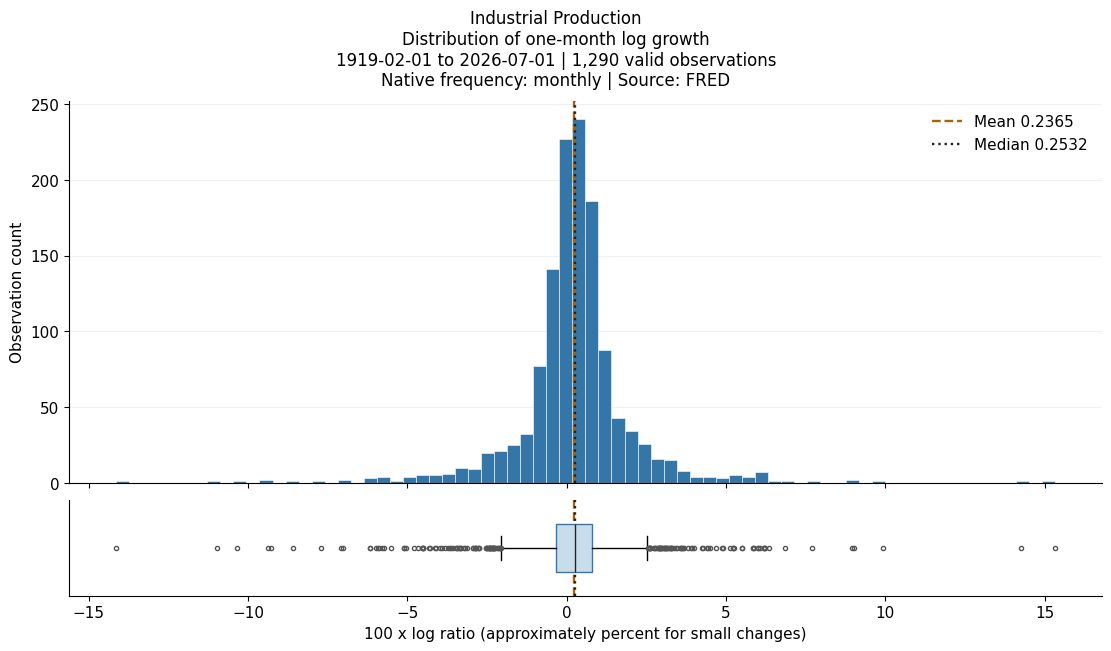

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,1290,0.2365,0.2532,1.9,0.5823,-0.02418,13.09,0


**Diagnostic:** approximately_symmetric; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.340 / -1.391; delta: -0.024 / 13.086. Smaller moments alone do not establish stationarity or benchmark suitability.

In [7]:
plot_distribution('INDPRO', 'log_change')

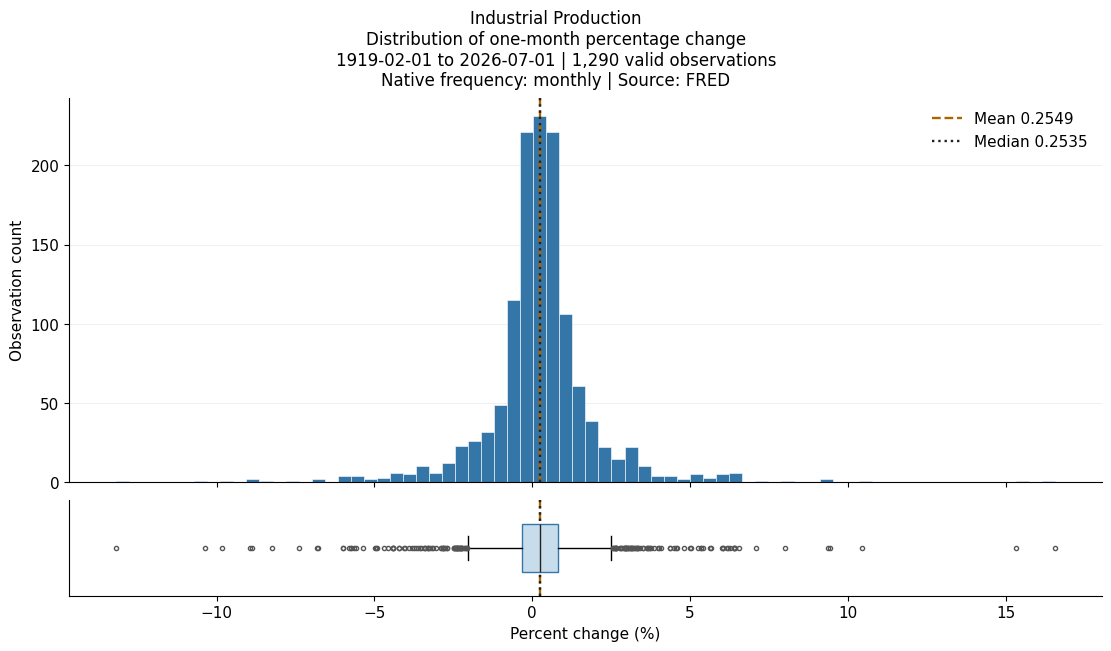

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,1290,0.2549,0.2535,1.907,0.5822,0.4106,13.87,0


**Diagnostic:** approximately_symmetric; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.340 / -1.391; delta: 0.411 / 13.874. Smaller moments alone do not establish stationarity or benchmark suitability.

In [8]:
plot_distribution('INDPRO', 'percentage_change')

In [9]:
dataset_header('IPMAN')

---
### IPMAN - Manufacturing Production

**Economic meaning:** Measures real output produced by U.S. manufacturing industries.

**Raw distribution observation:** Skewness -0.301; excess kurtosis -1.583; minimum 35.36; maximum 106.6. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

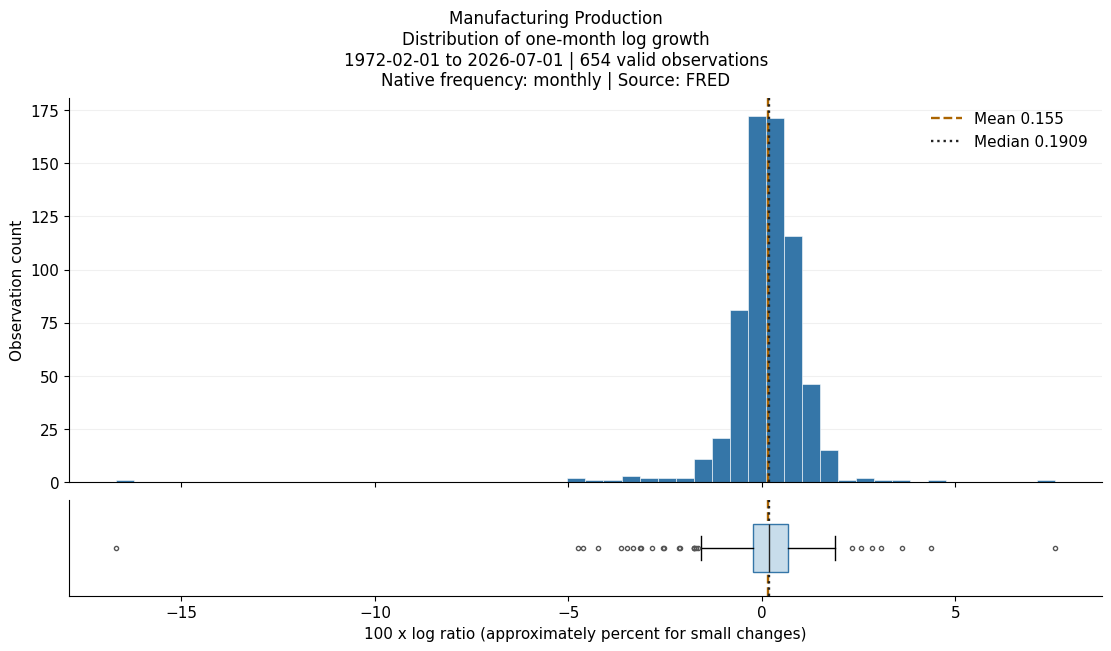

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,654,0.155,0.1909,1.128,0.4428,-5.12,80.14,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: -0.304 / -1.582; delta: -5.120 / 80.141. Smaller moments alone do not establish stationarity or benchmark suitability.

In [10]:
plot_distribution('IPMAN', 'log_change')

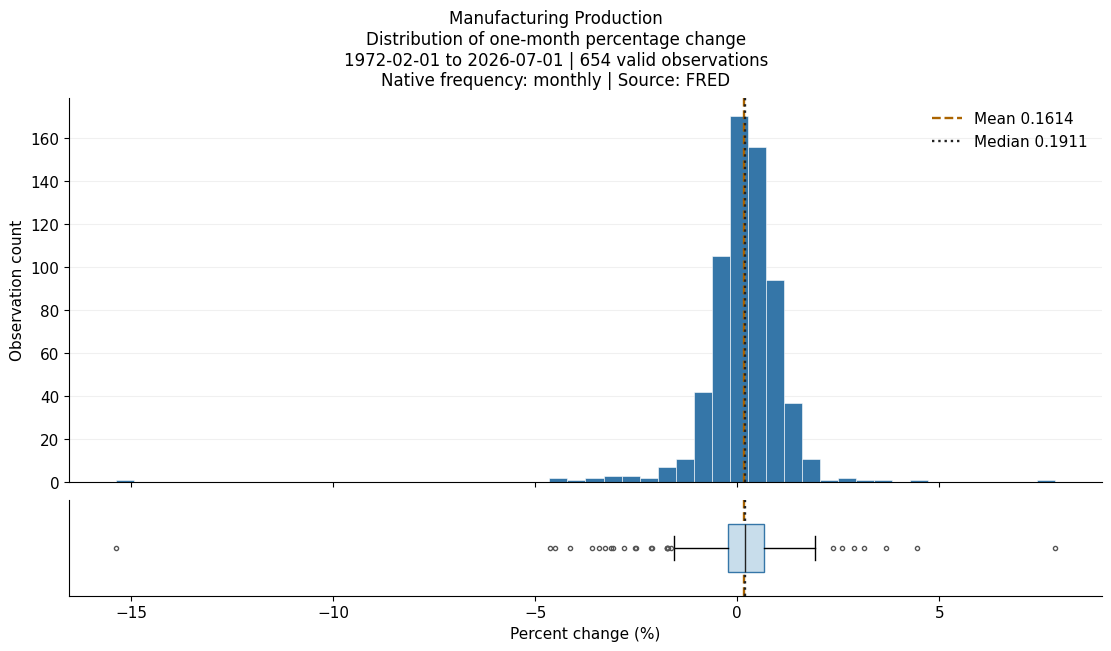

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,654,0.1614,0.1911,1.1,0.4437,-4.225,65.75,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: -0.304 / -1.582; delta: -4.225 / 65.751. Smaller moments alone do not establish stationarity or benchmark suitability.

In [11]:
plot_distribution('IPMAN', 'percentage_change')

In [12]:
dataset_header('PCEC96')

---
### PCEC96 - Real Personal Consumption Expenditure

**Economic meaning:** Measures inflation-adjusted spending by U.S. consumers on goods and services.

**Raw distribution observation:** Skewness 0.475; excess kurtosis -1.095; minimum 1.107e+04; maximum 1.69e+04. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

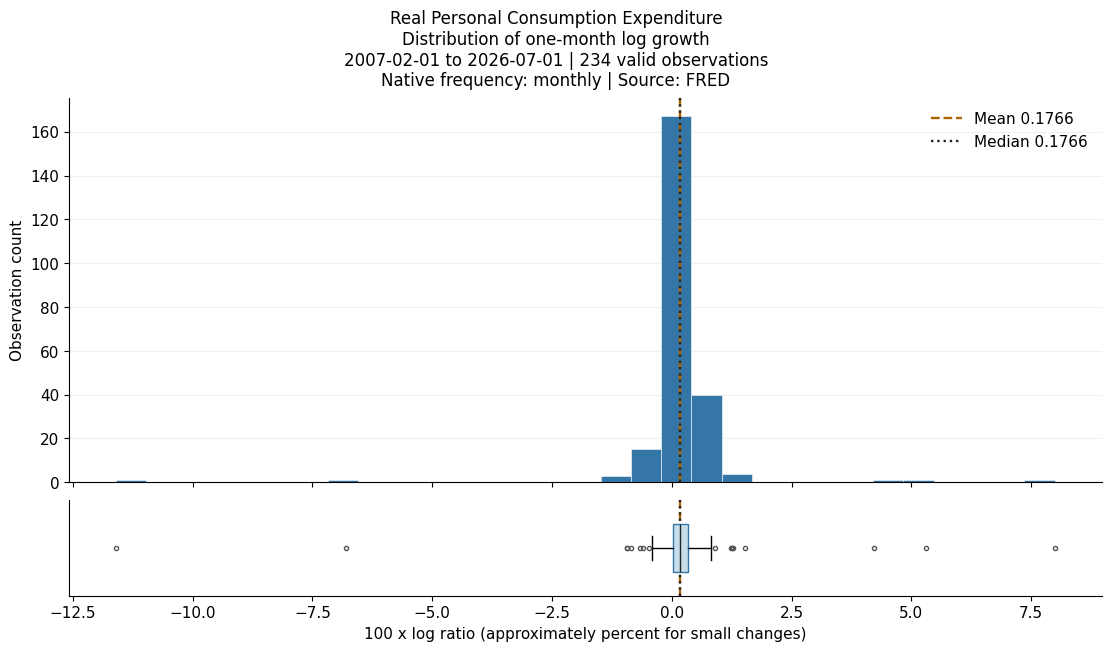

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,234,0.1766,0.1766,1.165,0.1635,-3.535,59.85,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.470 / -1.099; delta: -3.535 / 59.847. Smaller moments alone do not establish stationarity or benchmark suitability.

In [13]:
plot_distribution('PCEC96', 'log_change')

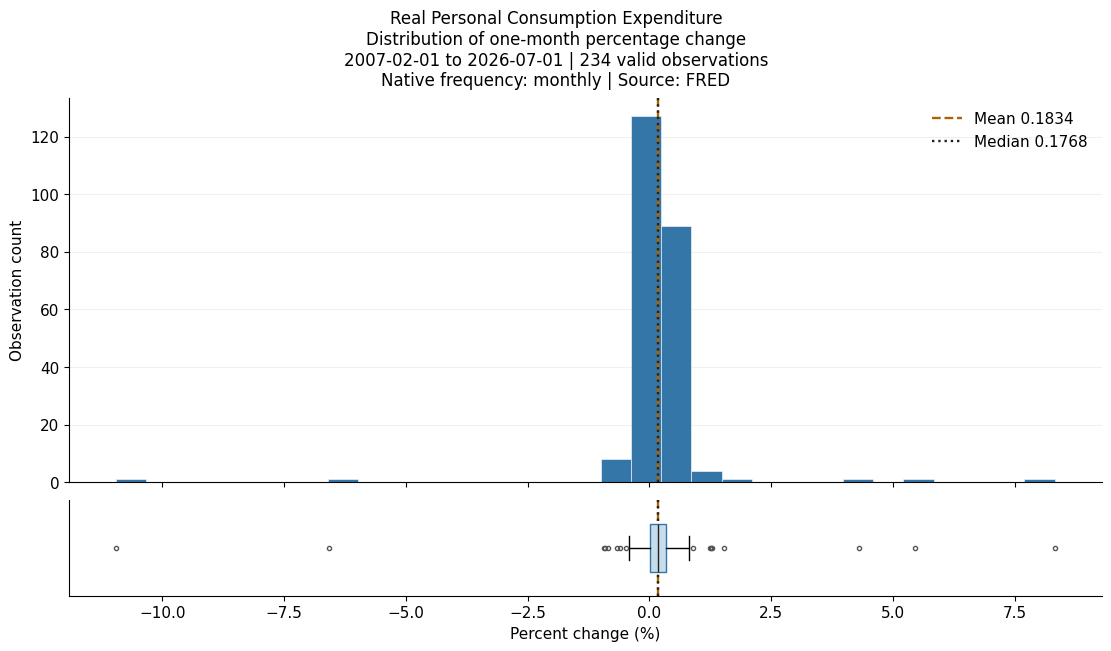

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,234,0.1834,0.1768,1.145,0.1637,-2.681,55.53,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.470 / -1.099; delta: -2.681 / 55.532. Smaller moments alone do not establish stationarity or benchmark suitability.

In [14]:
plot_distribution('PCEC96', 'percentage_change')

In [15]:
dataset_header('W875RX1')

---
### W875RX1 - Real Personal Income excluding transfers

**Economic meaning:** Measures inflation-adjusted personal income excluding current transfer receipts, separating income earned through economic activity from transfers.

**Raw distribution observation:** Skewness 0.376; excess kurtosis -1.060; minimum 2,426; maximum 1.672e+04. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

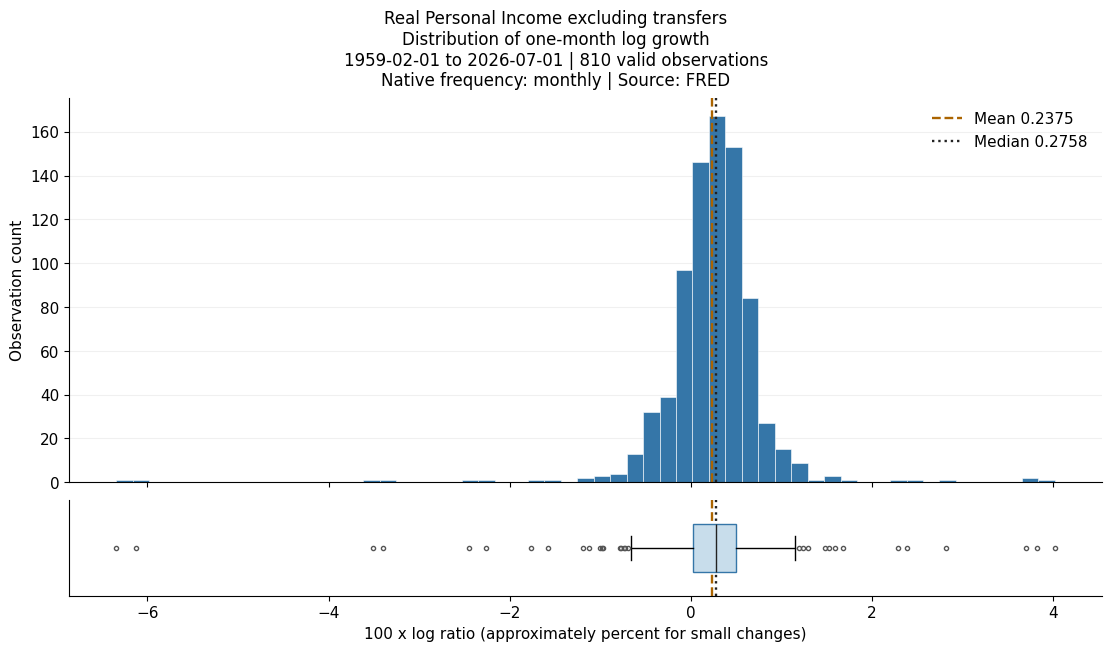

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,810,0.2375,0.2758,0.6095,0.2329,-2.822,39.05,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.376 / -1.061; delta: -2.822 / 39.045. Smaller moments alone do not establish stationarity or benchmark suitability.

In [16]:
plot_distribution('W875RX1', 'log_change')

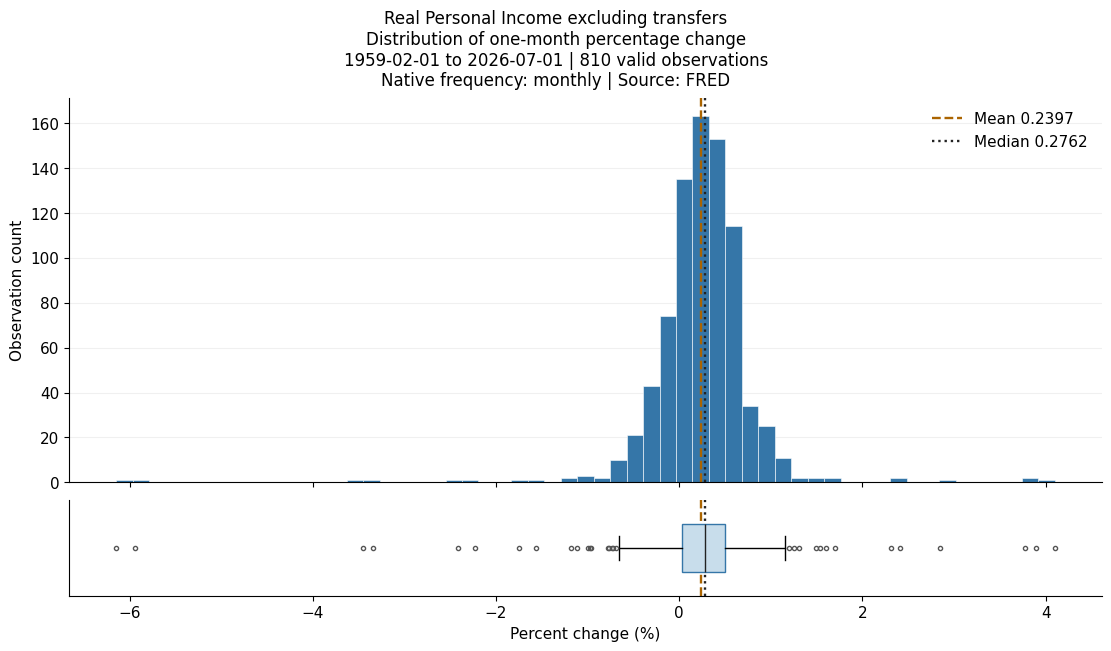

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,810,0.2397,0.2762,0.606,0.2337,-2.524,36.62,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.376 / -1.061; delta: -2.524 / 36.624. Smaller moments alone do not establish stationarity or benchmark suitability.

In [17]:
plot_distribution('W875RX1', 'percentage_change')

In [18]:
dataset_header('RPI')

---
### RPI - Real Personal Income

**Economic meaning:** Measures the inflation-adjusted income received by individuals, including earnings, property income, and transfer receipts.

**Raw distribution observation:** Skewness 0.459; excess kurtosis -0.954; minimum 2,584; maximum 2.292e+04. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

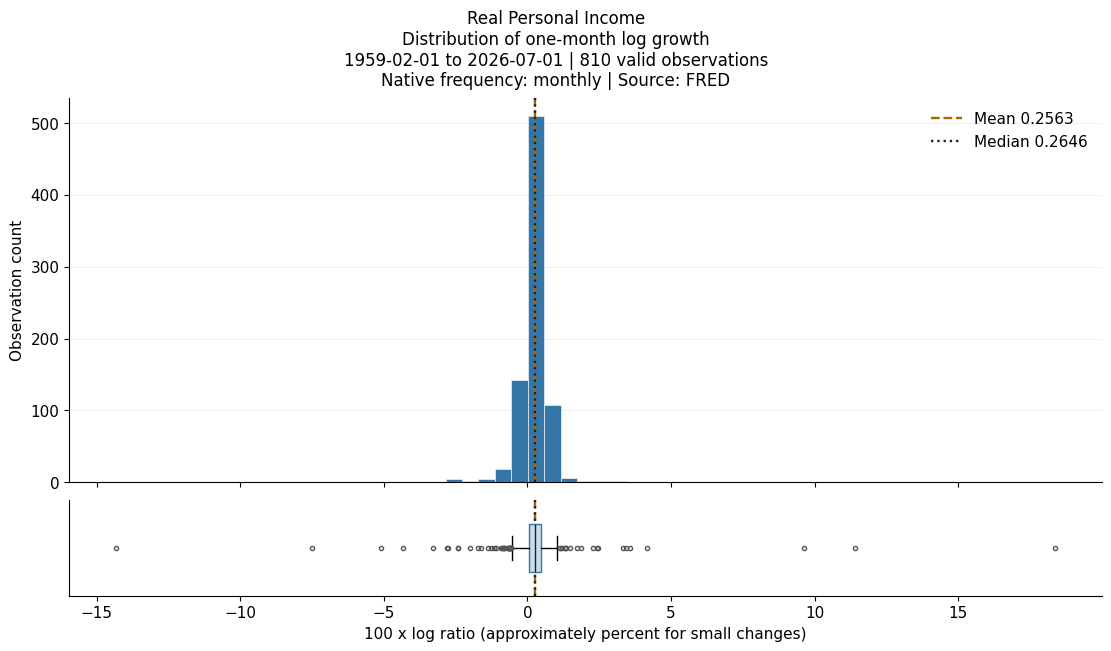

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,810,0.2563,0.2646,1.159,0.2054,3.448,122.7,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.459 / -0.955; delta: 3.448 / 122.676. Smaller moments alone do not establish stationarity or benchmark suitability.

In [19]:
plot_distribution('RPI', 'log_change')

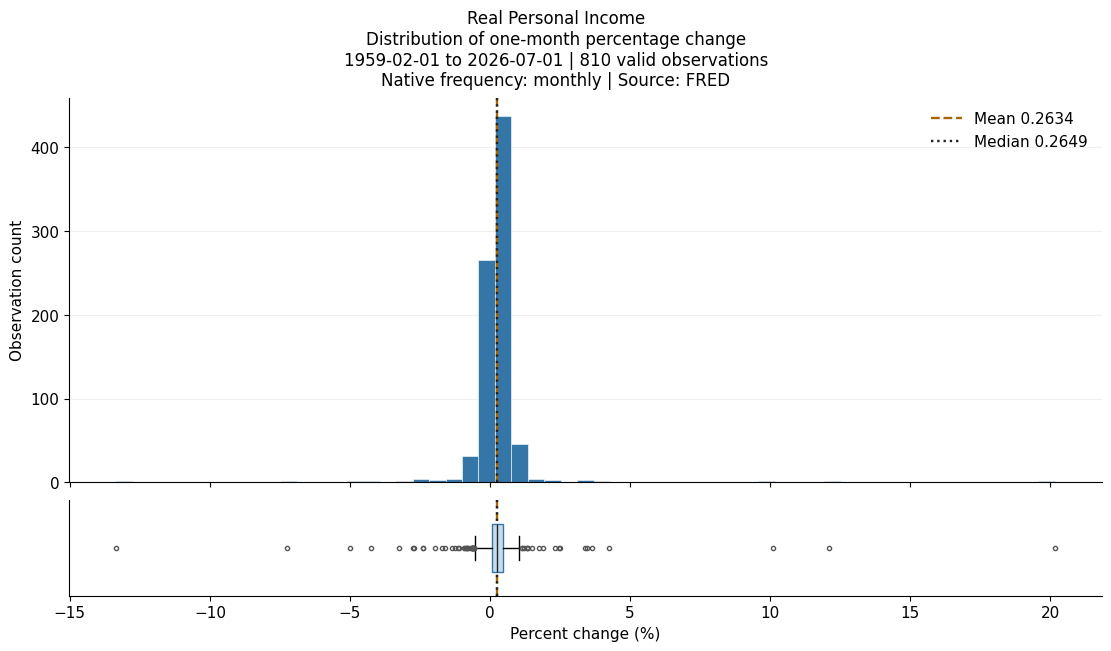

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,810,0.2634,0.2649,1.19,0.2061,5.375,136.8,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.459 / -0.955; delta: 5.375 / 136.764. Smaller moments alone do not establish stationarity or benchmark suitability.

In [20]:
plot_distribution('RPI', 'percentage_change')

In [21]:
dataset_header('RRSFS')

---
### RRSFS - Real Retail & Food Services Sales

**Economic meaning:** Measures inflation-adjusted sales at U.S. retail stores and food-service establishments.

**Raw distribution observation:** Skewness 0.224; excess kurtosis -0.698; minimum 1.141e+05; maximum 2.316e+05. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

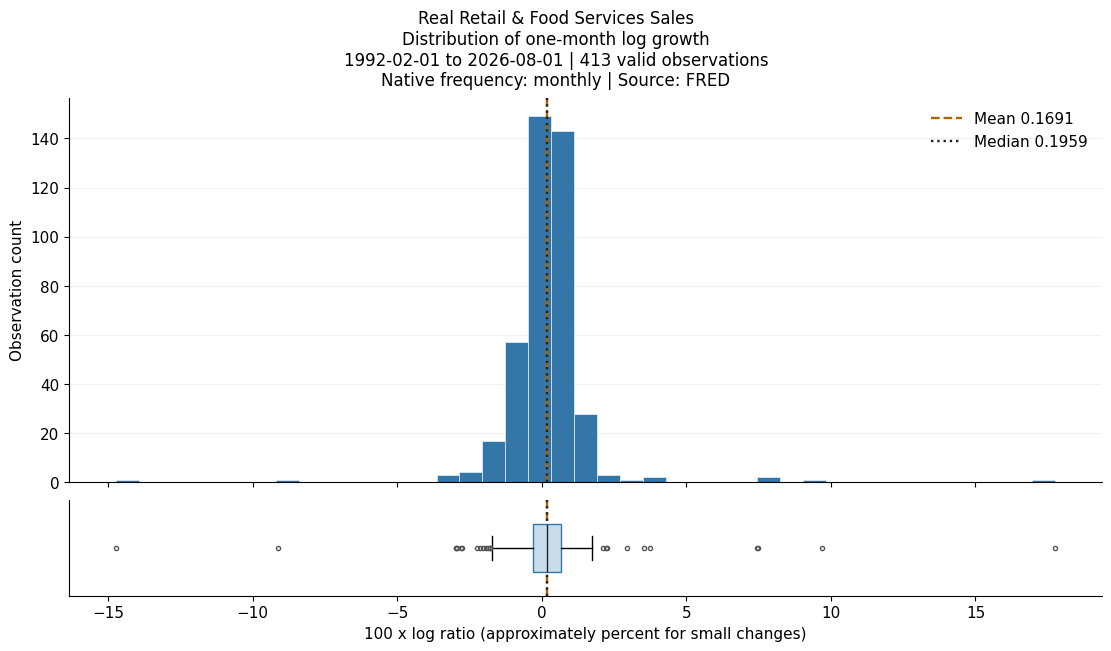

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,413,0.1691,0.1959,1.651,0.4792,1.544,52.37,1


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.231 / -0.688; delta: 1.544 / 52.374. Smaller moments alone do not establish stationarity or benchmark suitability.

In [22]:
plot_distribution('RRSFS', 'log_change')

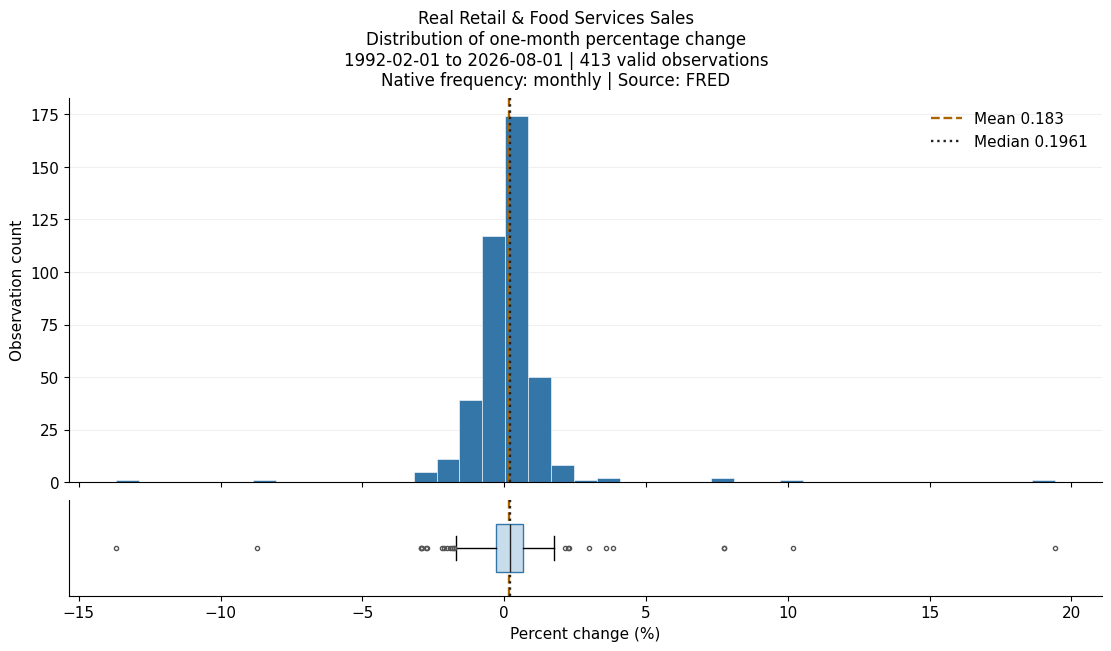

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,413,0.183,0.1961,1.682,0.479,2.816,57.89,1


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.231 / -0.688; delta: 2.816 / 57.894. Smaller moments alone do not establish stationarity or benchmark suitability.

In [23]:
plot_distribution('RRSFS', 'percentage_change')

In [24]:
dataset_header('HOUST')

---
### HOUST - Housing Starts

**Economic meaning:** Measures the number of new privately owned housing units on which construction has started in the United States.

**Raw distribution observation:** Skewness -0.060; excess kurtosis 0.265; minimum 478; maximum 2,494. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** MEDIUM. Positive housing quantity with strong cyclicality; compare growth and native-unit change without presuming a secular trend.

**Transformations shown:**
- one-month log growth
- one-month percentage change
- one-month absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

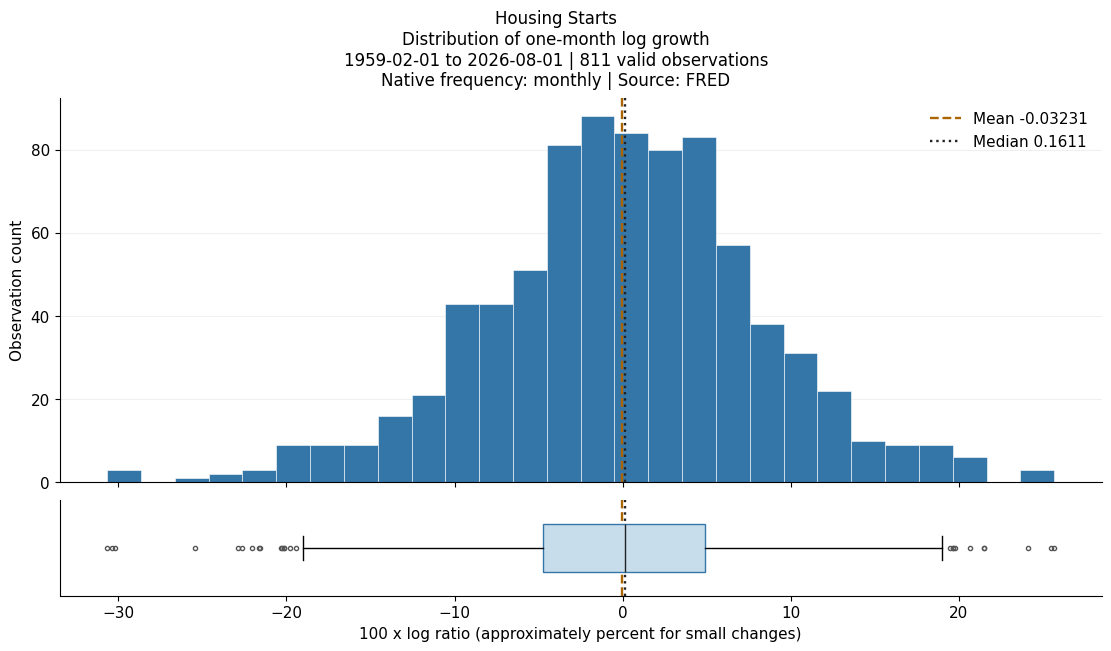

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,811,-0.03231,0.1611,8.267,4.828,-0.1868,0.7531,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: -0.058 / 0.263; delta: -0.187 / 0.753. Smaller moments alone do not establish stationarity or benchmark suitability.

In [25]:
plot_distribution('HOUST', 'log_change')

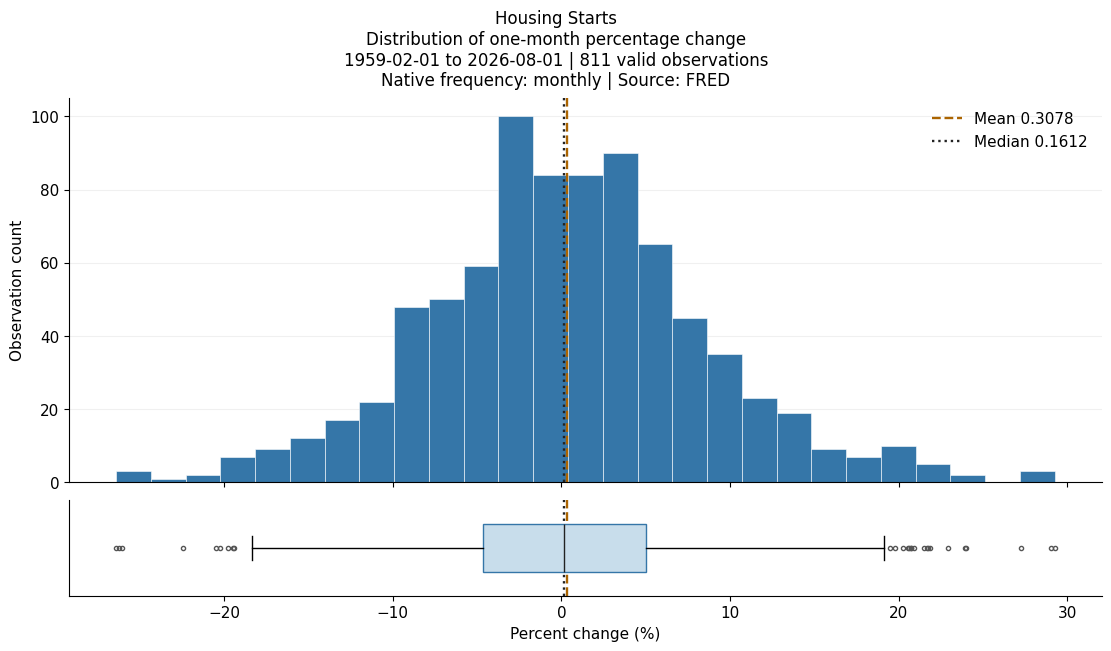

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,811,0.3078,0.1612,8.254,4.834,0.1438,0.6778,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: -0.058 / 0.263; delta: 0.144 / 0.678. Smaller moments alone do not establish stationarity or benchmark suitability.

In [26]:
plot_distribution('HOUST', 'percentage_change')

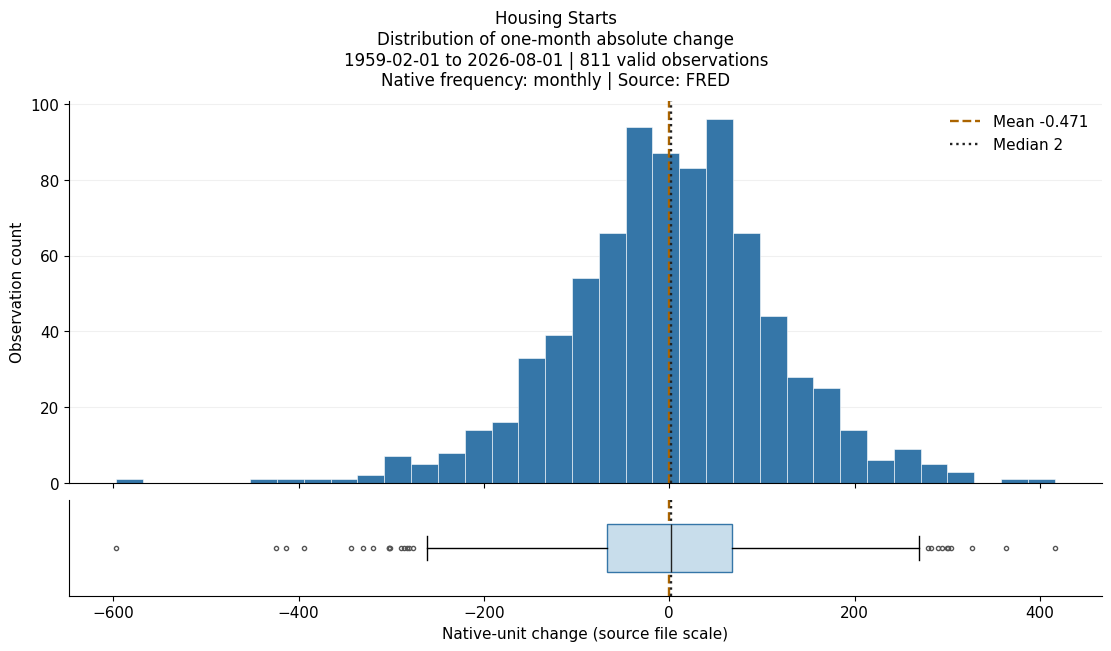

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,811,-0.471,2,115.3,67,-0.273,1.525,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: -0.058 / 0.263; delta: -0.273 / 1.525. Smaller moments alone do not establish stationarity or benchmark suitability.

In [27]:
plot_distribution('HOUST', 'absolute_delta')

In [28]:
dataset_header('PERMIT')

---
### PERMIT - Building Permits

**Economic meaning:** Measures the number of new privately owned housing units authorized by building permits in the United States.

**Raw distribution observation:** Skewness 0.051; excess kurtosis -0.149; minimum 513; maximum 2,419. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** MEDIUM. Positive housing quantity with strong cyclicality; compare growth and native-unit change without presuming a secular trend.

**Transformations shown:**
- one-month log growth
- one-month percentage change
- one-month absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

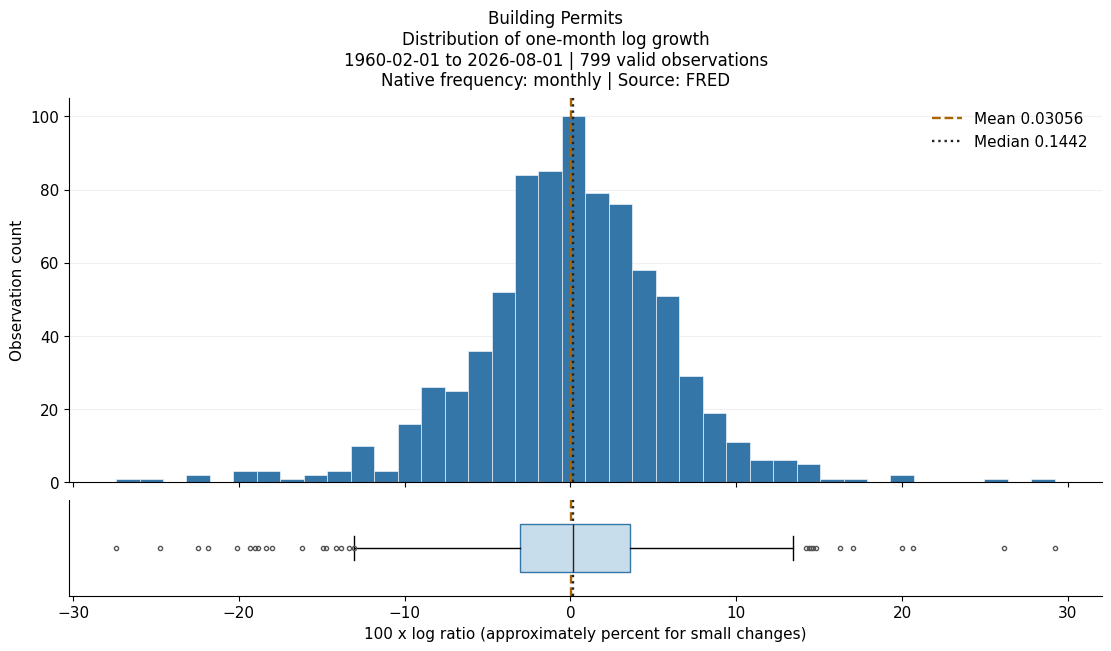

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,799,0.03056,0.1442,5.942,3.334,-0.1963,2.73,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: 0.048 / -0.149; delta: -0.196 / 2.730. Smaller moments alone do not establish stationarity or benchmark suitability.

In [29]:
plot_distribution('PERMIT', 'log_change')

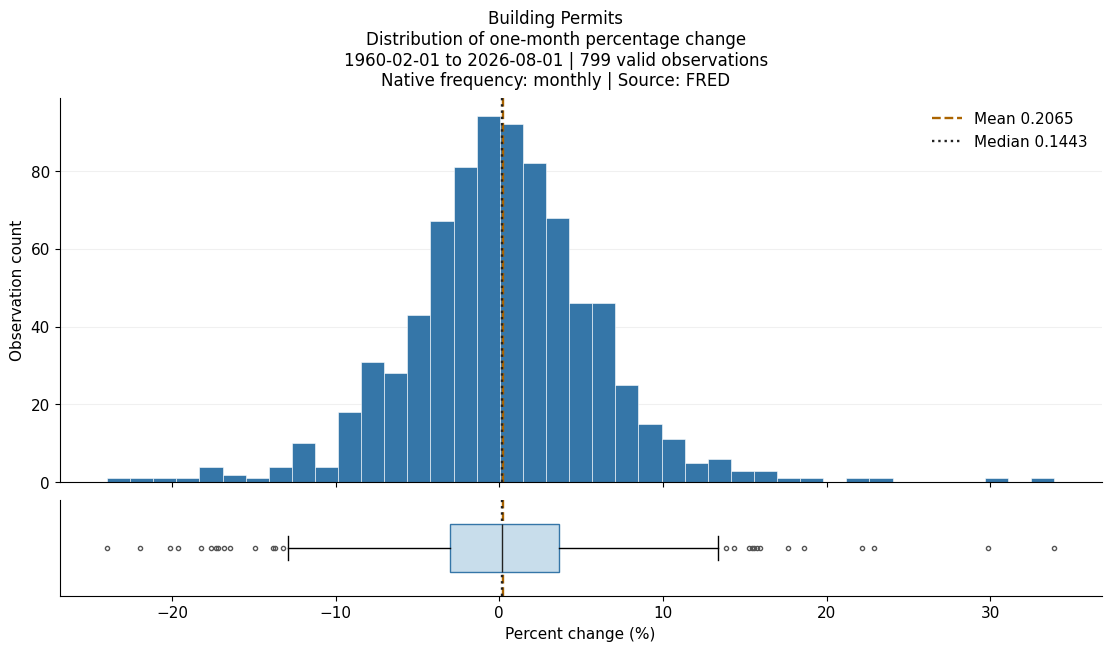

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,799,0.2065,0.1443,5.941,3.294,0.2288,3.098,0


**Diagnostic:** approximately_symmetric; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.048 / -0.149; delta: 0.229 / 3.098. Smaller moments alone do not establish stationarity or benchmark suitability.

In [30]:
plot_distribution('PERMIT', 'percentage_change')

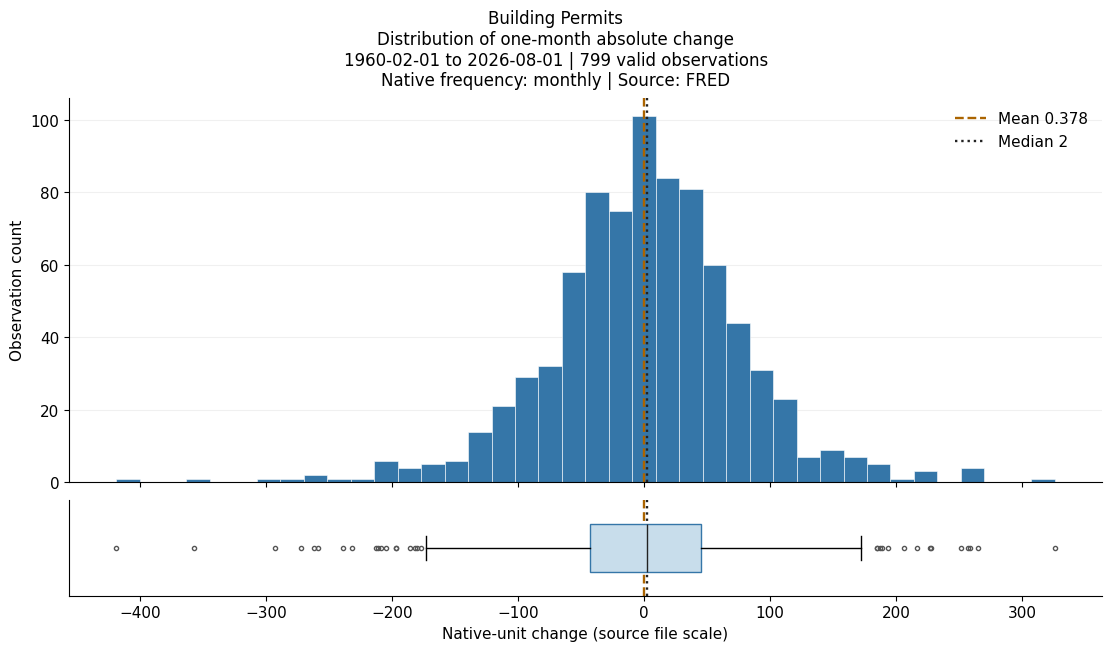

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,799,0.378,2,79.05,44,-0.2945,2.588,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: 0.048 / -0.149; delta: -0.295 / 2.588. Smaller moments alone do not establish stationarity or benchmark suitability.

In [31]:
plot_distribution('PERMIT', 'absolute_delta')

In [32]:
dataset_header('PAYEMS')

---
### PAYEMS - Nonfarm Payroll Employment

**Economic meaning:** Measures the number of payroll jobs at U.S. nonfarm establishments; it counts jobs rather than unique people.

**Raw distribution observation:** Skewness 0.044; excess kurtosis -1.418; minimum 2.992e+04; maximum 1.591e+05. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

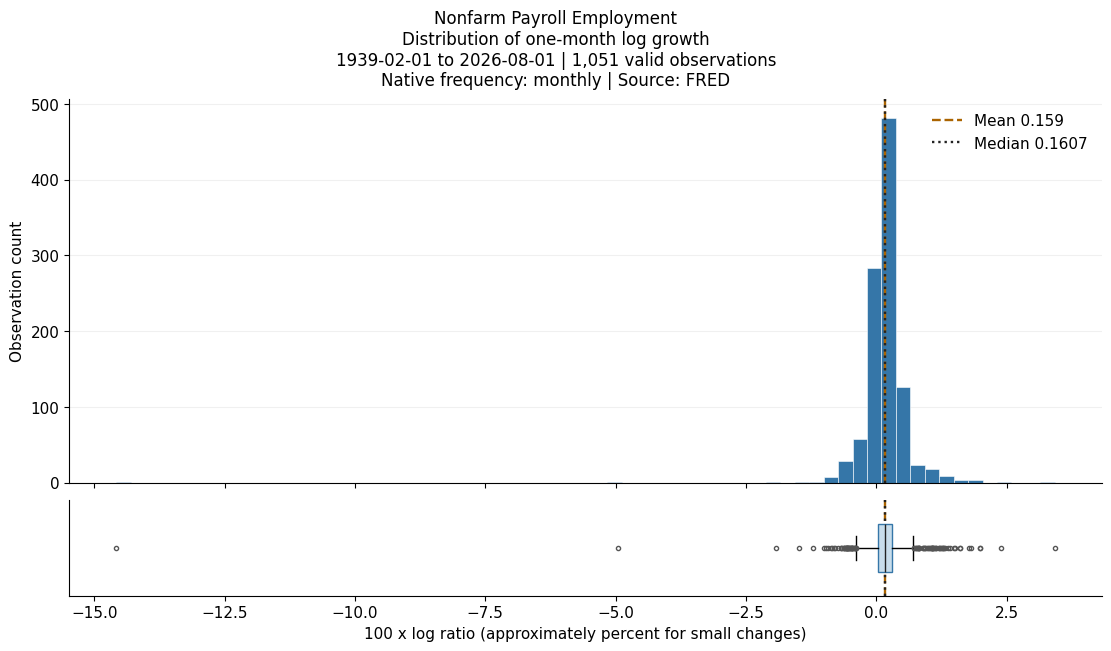

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,1051,0.159,0.1607,0.6063,0.1378,-13.96,338.1,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.044 / -1.418; delta: -13.964 / 338.088. Smaller moments alone do not establish stationarity or benchmark suitability.

In [33]:
plot_distribution('PAYEMS', 'log_change')

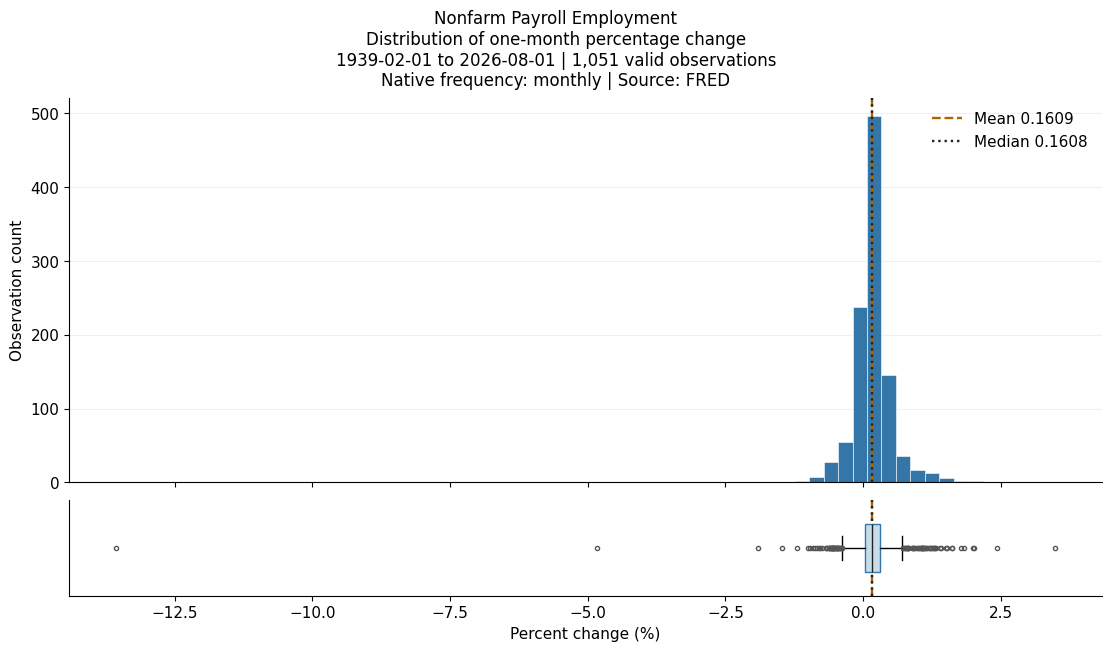

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,1051,0.1609,0.1608,0.5832,0.1381,-12.67,298.4,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.044 / -1.418; delta: -12.672 / 298.389. Smaller moments alone do not establish stationarity or benchmark suitability.

In [34]:
plot_distribution('PAYEMS', 'percentage_change')

In [35]:
dataset_header('JTSJOL')

---
### JTSJOL - Job Openings

**Economic meaning:** Measures the number of unfilled job openings at U.S. nonfarm establishments.

**Raw distribution observation:** Skewness 0.964; excess kurtosis 0.326; minimum 2,232; maximum 1.23e+04. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

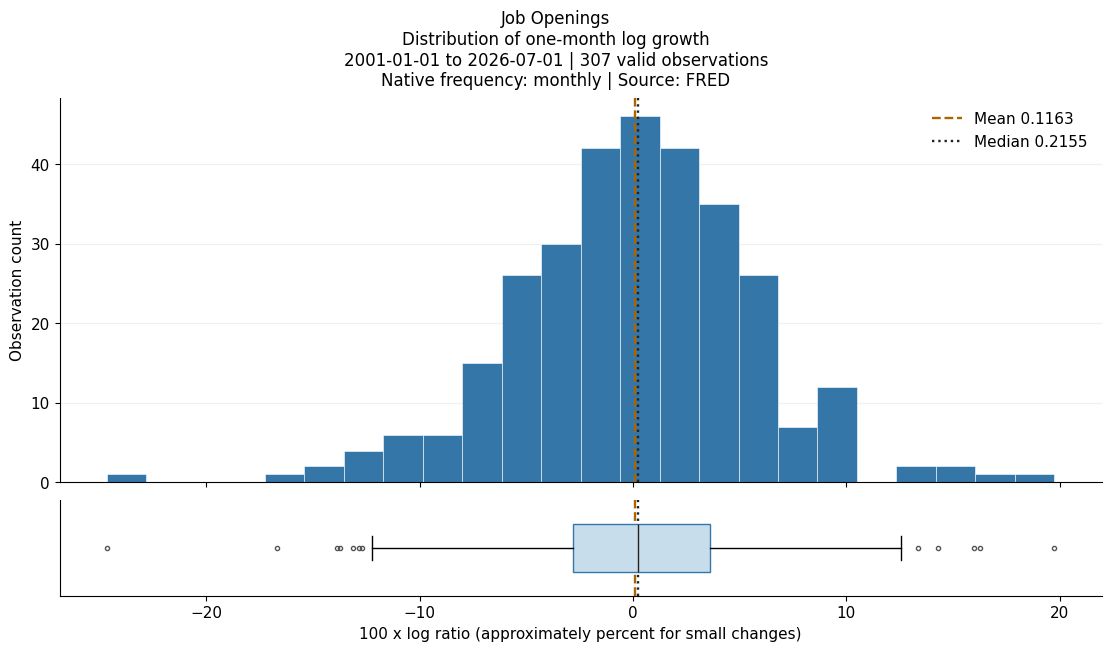

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,307,0.1163,0.2155,5.596,3.346,-0.217,1.601,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: 0.960 / 0.314; delta: -0.217 / 1.601. Smaller moments alone do not establish stationarity or benchmark suitability.

In [36]:
plot_distribution('JTSJOL', 'log_change')

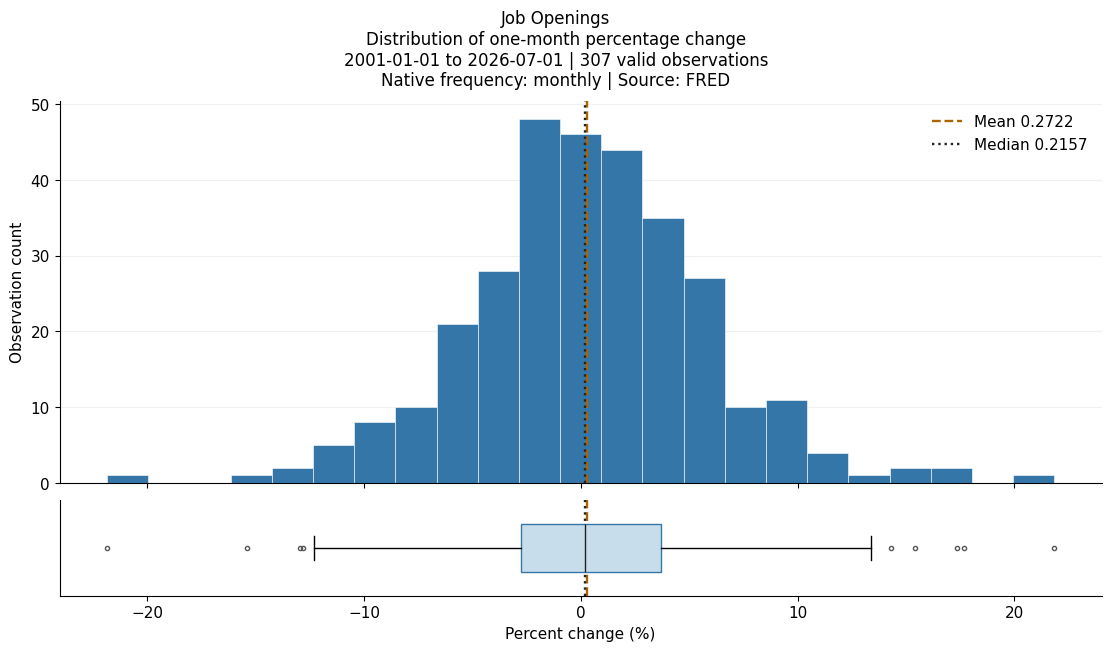

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,307,0.2722,0.2157,5.589,3.319,0.07276,1.444,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: 0.960 / 0.314; delta: 0.073 / 1.444. Smaller moments alone do not establish stationarity or benchmark suitability.

In [37]:
plot_distribution('JTSJOL', 'percentage_change')

In [38]:
dataset_header('CES0500000003')

---
### CES0500000003 - Average Hourly Earnings — Total Private

**Economic meaning:** Measures average hourly earnings of employees on U.S. private nonfarm payrolls.

**Raw distribution observation:** Skewness 0.638; excess kurtosis -0.790; minimum 20.04; maximum 37.75. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

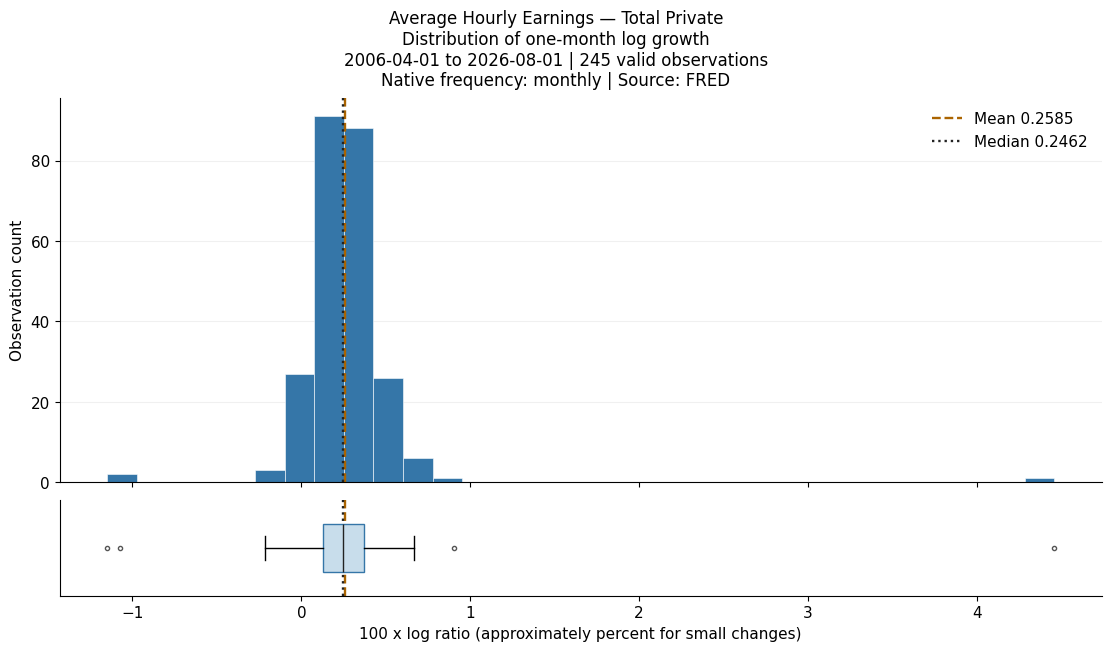

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,245,0.2585,0.2462,0.3394,0.1188,7.308,97.95,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.638 / -0.794; delta: 7.308 / 97.947. Smaller moments alone do not establish stationarity or benchmark suitability.

In [39]:
plot_distribution('CES0500000003', 'log_change')

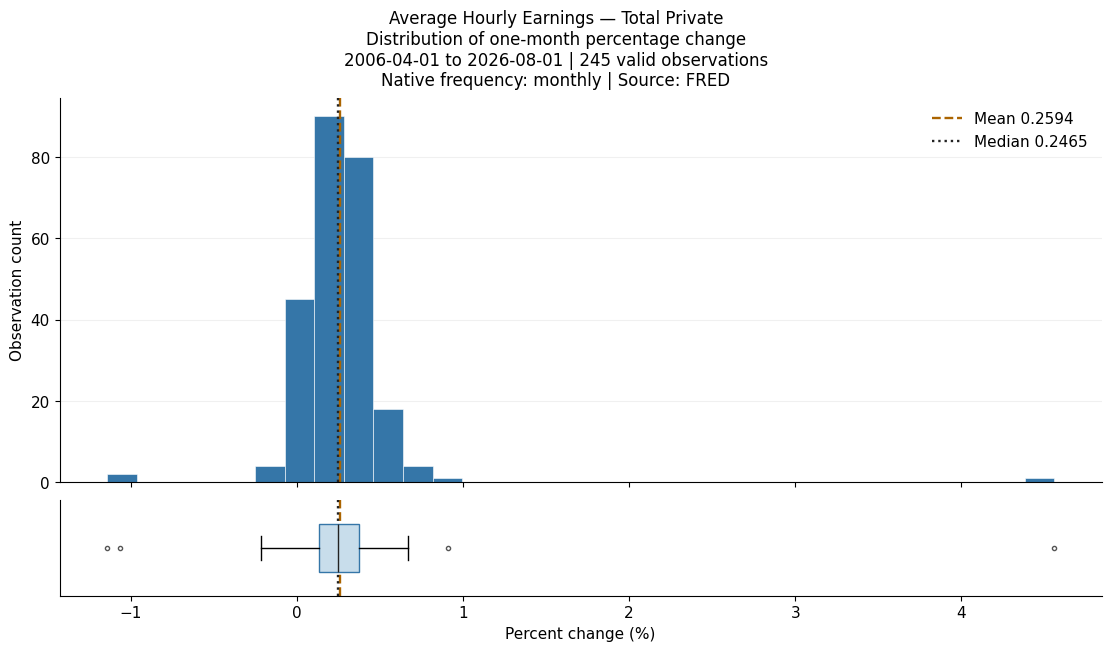

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,245,0.2594,0.2465,0.3445,0.1191,7.538,101.2,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.638 / -0.794; delta: 7.538 / 101.167. Smaller moments alone do not establish stationarity or benchmark suitability.

In [40]:
plot_distribution('CES0500000003', 'percentage_change')

In [41]:
dataset_header('CPIAUCSL')

---
### CPIAUCSL - CPI All Items

**Economic meaning:** Tracks prices paid by urban consumers for a broad basket of goods and services in the United States.

**Raw distribution observation:** Skewness 0.472; excess kurtosis -1.022; minimum 21.48; maximum 334.1. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

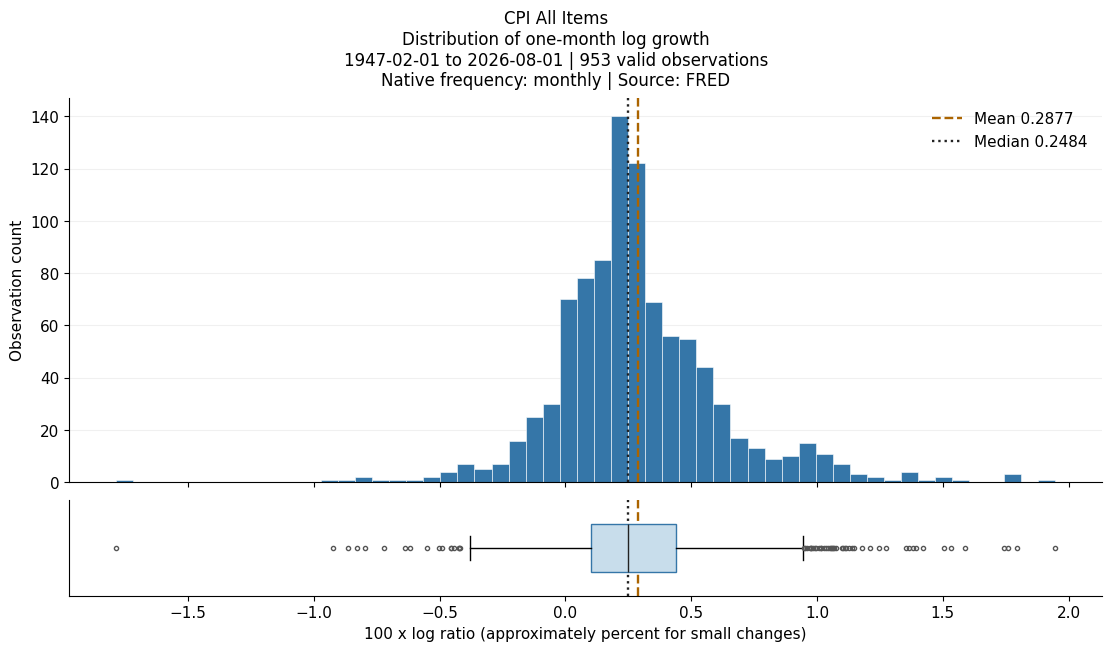

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,953,0.2877,0.2484,0.3398,0.1605,0.5593,4.092,1


**Diagnostic:** right_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.470 / -1.025; delta: 0.559 / 4.092. Smaller moments alone do not establish stationarity or benchmark suitability.

In [42]:
plot_distribution('CPIAUCSL', 'log_change')

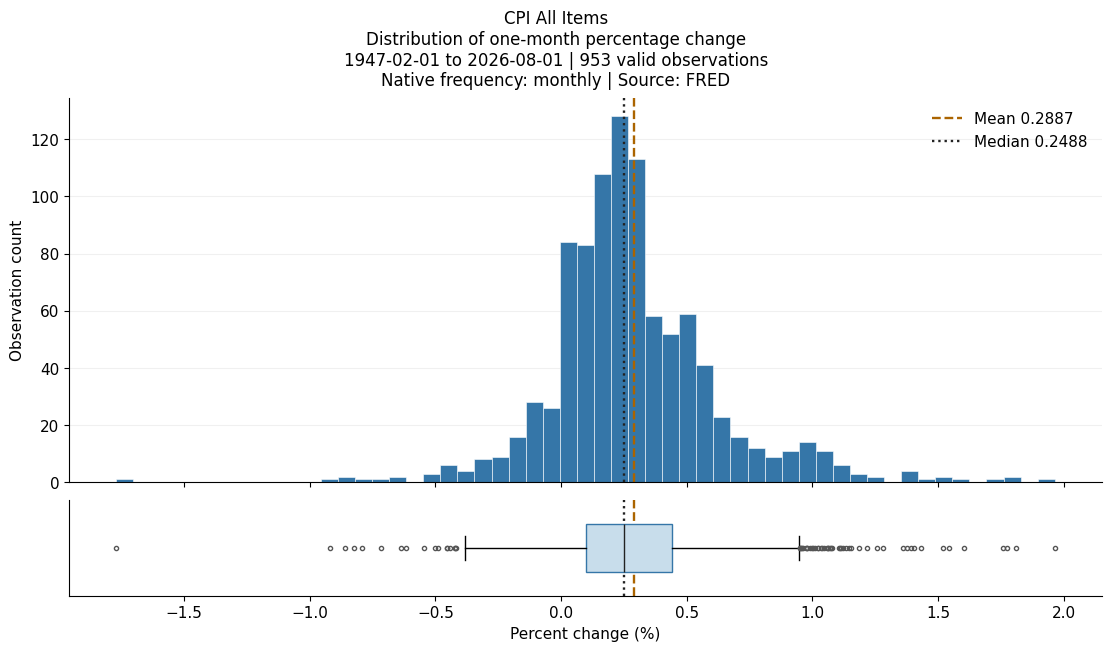

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,953,0.2887,0.2488,0.3411,0.161,0.5885,4.08,1


**Diagnostic:** right_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.470 / -1.025; delta: 0.589 / 4.080. Smaller moments alone do not establish stationarity or benchmark suitability.

In [43]:
plot_distribution('CPIAUCSL', 'percentage_change')

In [44]:
dataset_header('CPILFESL')

---
### CPILFESL - Core CPI

**Economic meaning:** Tracks prices paid by urban consumers for goods and services excluding food and energy.

**Raw distribution observation:** Skewness 0.268; excess kurtosis -1.110; minimum 28.5; maximum 337.8. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

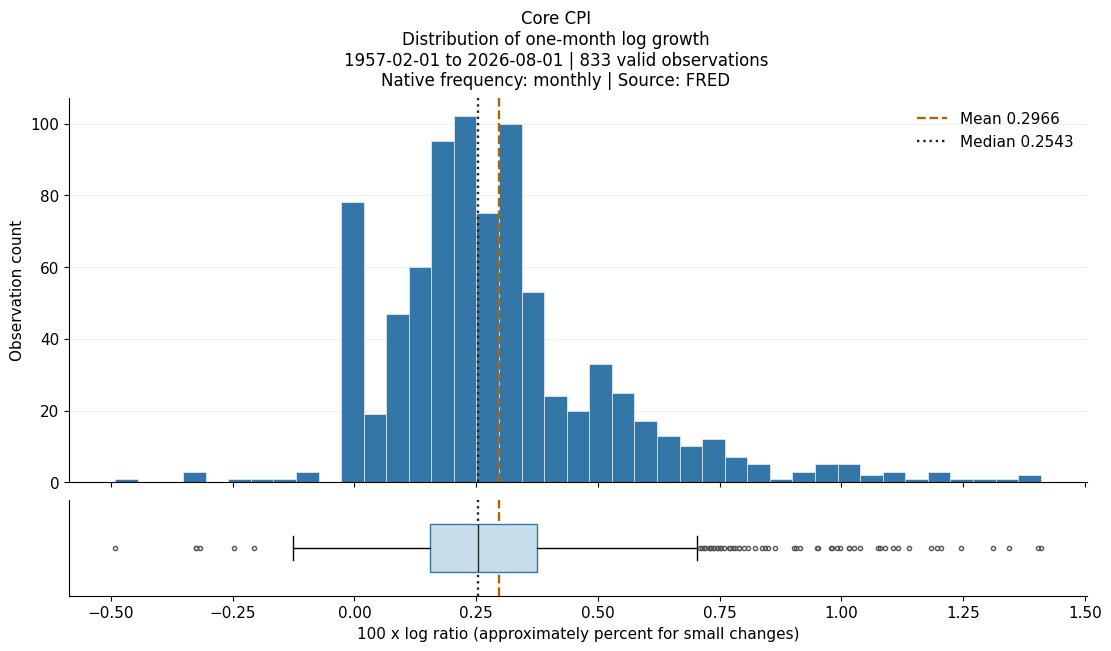

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,833,0.2966,0.2543,0.2422,0.108,1.316,3.133,1


**Diagnostic:** right_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.265 / -1.112; delta: 1.316 / 3.133. Smaller moments alone do not establish stationarity or benchmark suitability.

In [45]:
plot_distribution('CPILFESL', 'log_change')

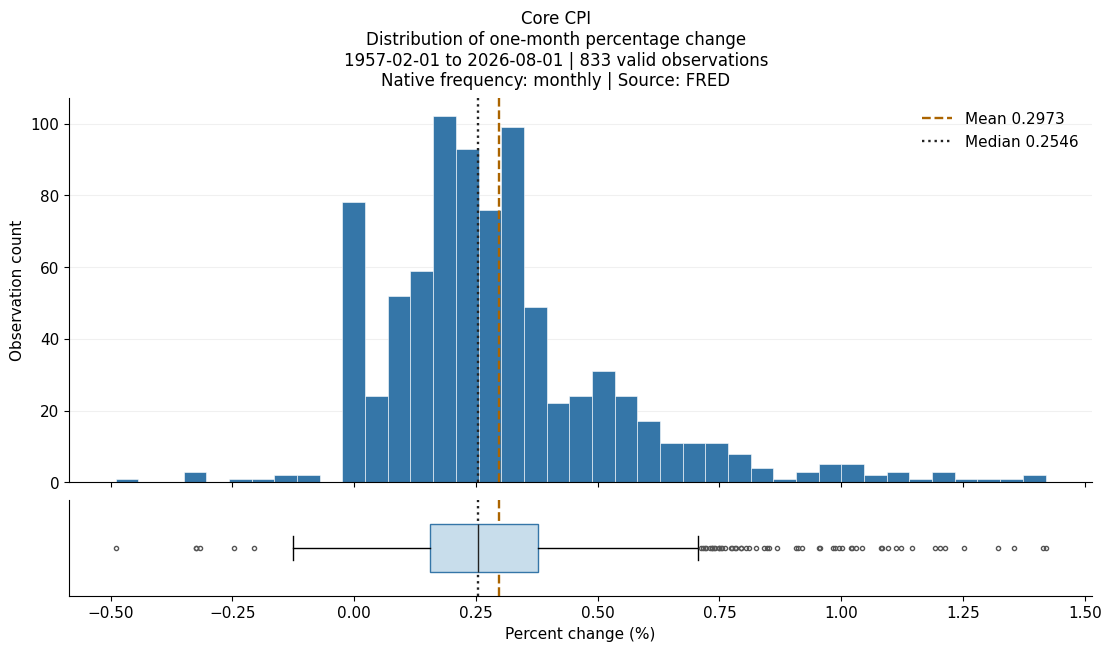

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,833,0.2973,0.2546,0.2433,0.1082,1.328,3.174,1


**Diagnostic:** right_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.265 / -1.112; delta: 1.328 / 3.174. Smaller moments alone do not establish stationarity or benchmark suitability.

In [46]:
plot_distribution('CPILFESL', 'percentage_change')

In [47]:
dataset_header('PCEPI')

---
### PCEPI - PCE Price Index

**Economic meaning:** Tracks prices of goods and services included in U.S. personal consumption expenditures.

**Raw distribution observation:** Skewness 0.128; excess kurtosis -1.139; minimum 15.16; maximum 131.7. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

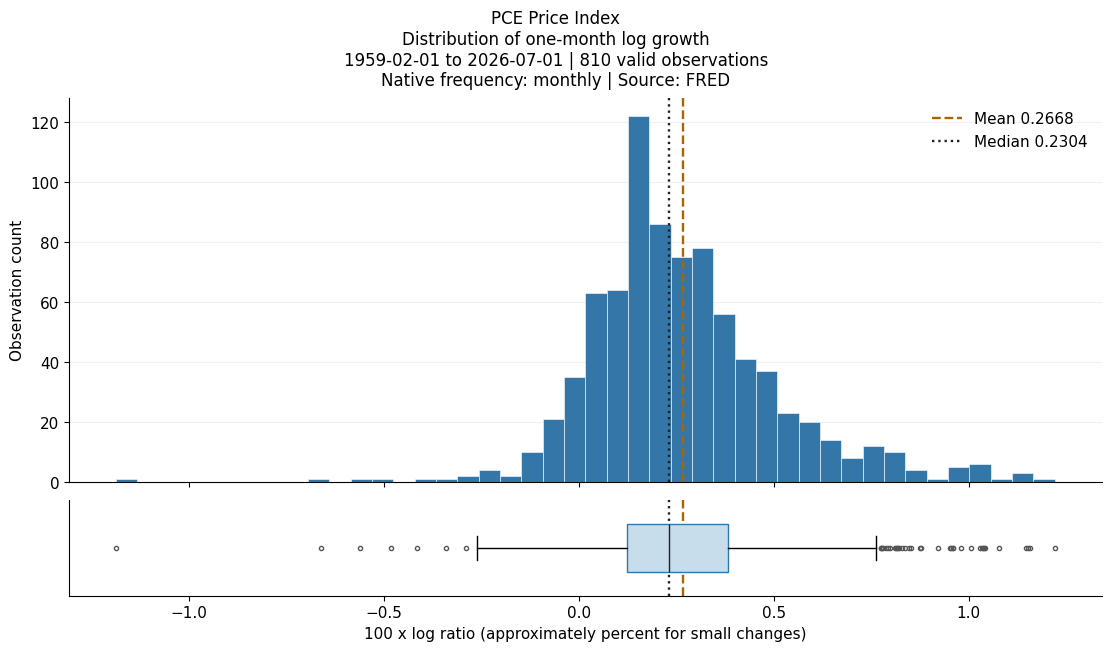

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,810,0.2668,0.2304,0.2448,0.1274,0.4865,3.011,0


**Diagnostic:** approximately_symmetric; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.127 / -1.138; delta: 0.486 / 3.011. Smaller moments alone do not establish stationarity or benchmark suitability.

In [48]:
plot_distribution('PCEPI', 'log_change')

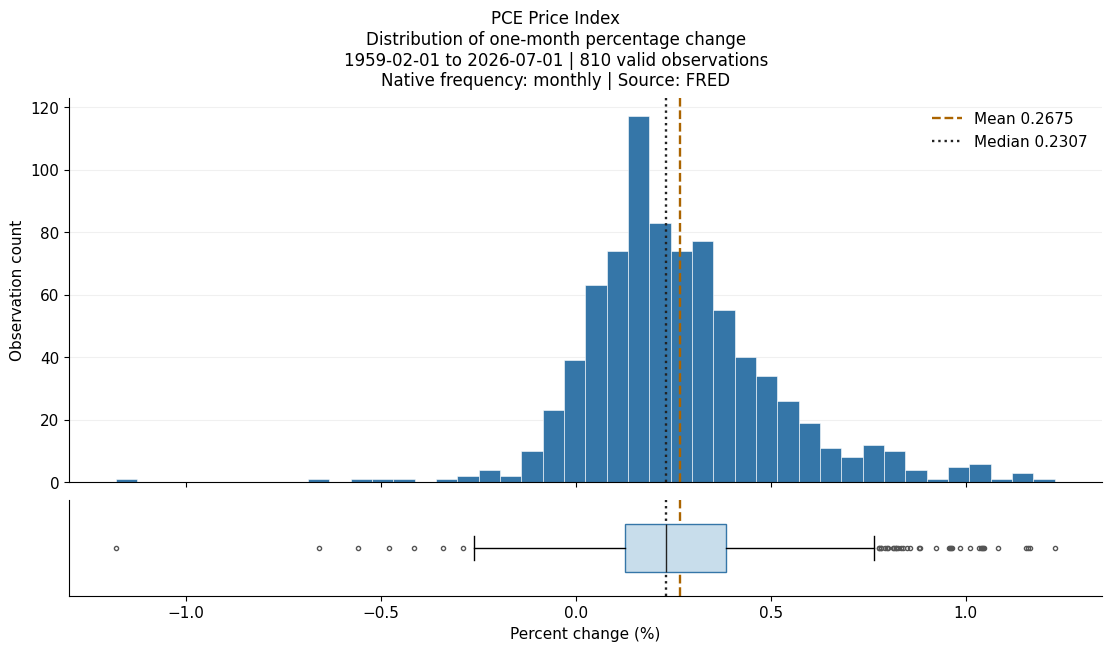

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,810,0.2675,0.2307,0.2456,0.1276,0.5039,2.983,0


**Diagnostic:** right_skewed. Matched-date raw skewness / excess kurtosis: 0.127 / -1.138; delta: 0.504 / 2.983. Smaller moments alone do not establish stationarity or benchmark suitability.

In [49]:
plot_distribution('PCEPI', 'percentage_change')

In [50]:
dataset_header('PCEPILFE')

---
### PCEPILFE - Core PCE Price Index

**Economic meaning:** Tracks prices in U.S. personal consumption expenditures excluding food and energy.

**Raw distribution observation:** Skewness 0.106; excess kurtosis -1.162; minimum 15.5; maximum 130.7. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

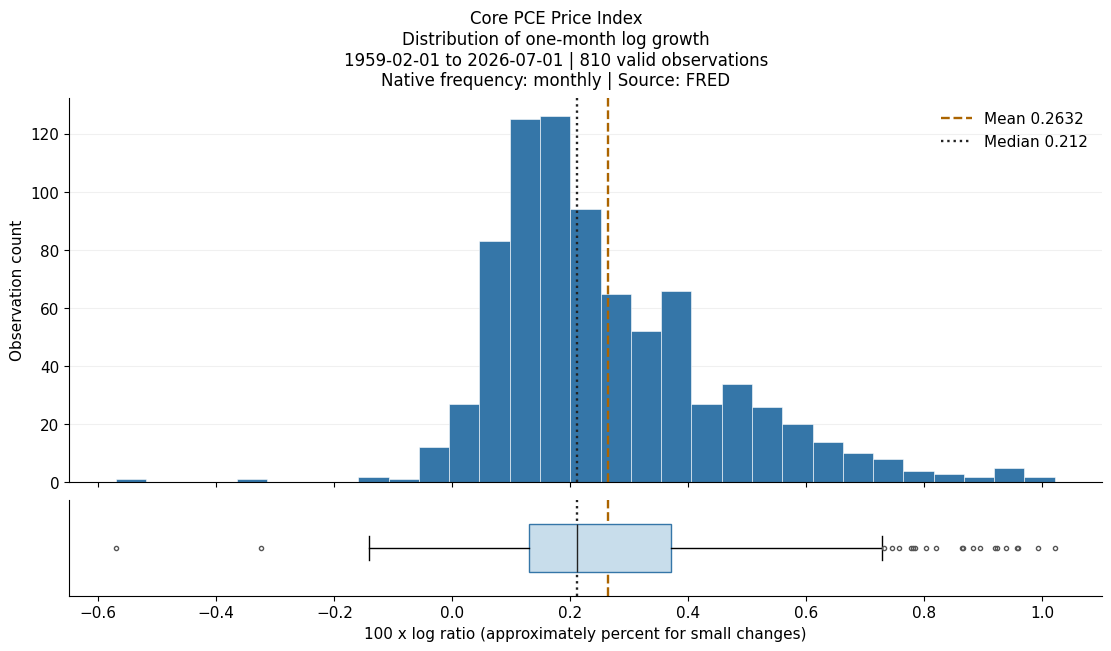

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,810,0.2632,0.212,0.1927,0.1072,0.9559,1.588,0


**Diagnostic:** right_skewed. Matched-date raw skewness / excess kurtosis: 0.105 / -1.161; delta: 0.956 / 1.588. Smaller moments alone do not establish stationarity or benchmark suitability.

In [51]:
plot_distribution('PCEPILFE', 'log_change')

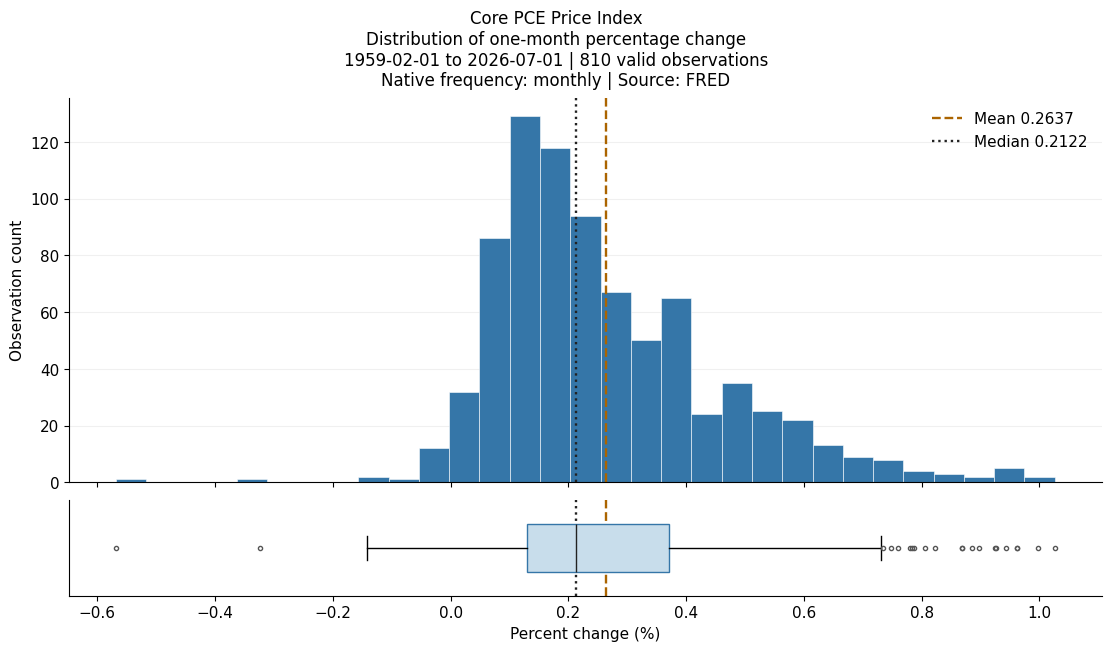

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,810,0.2637,0.2122,0.1934,0.1074,0.9636,1.598,0


**Diagnostic:** right_skewed. Matched-date raw skewness / excess kurtosis: 0.105 / -1.161; delta: 0.964 / 1.598. Smaller moments alone do not establish stationarity or benchmark suitability.

In [52]:
plot_distribution('PCEPILFE', 'percentage_change')

In [53]:
dataset_header('PPIFID')

---
### PPIFID - Producer Prices — Final Demand

**Economic meaning:** Tracks selling prices received by domestic producers for goods and services sold for final demand.

**Raw distribution observation:** Skewness 0.765; excess kurtosis -0.828; minimum 99.9; maximum 157.6. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

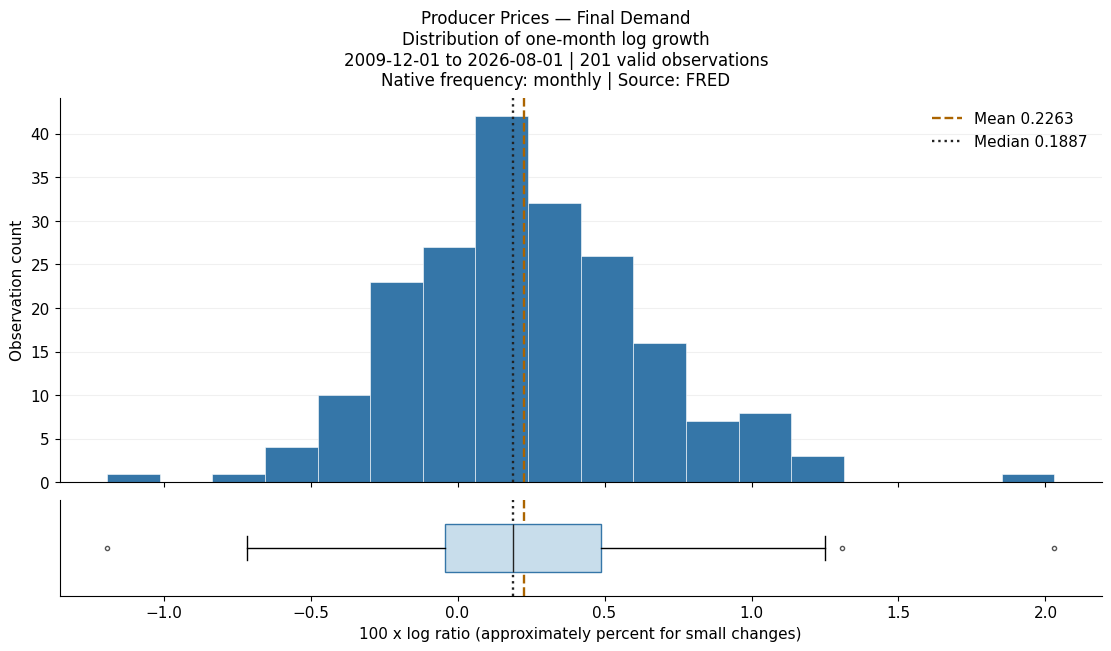

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,201,0.2263,0.1887,0.4283,0.2797,0.4104,1.298,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: 0.765 / -0.837; delta: 0.410 / 1.298. Smaller moments alone do not establish stationarity or benchmark suitability.

In [54]:
plot_distribution('PPIFID', 'log_change')

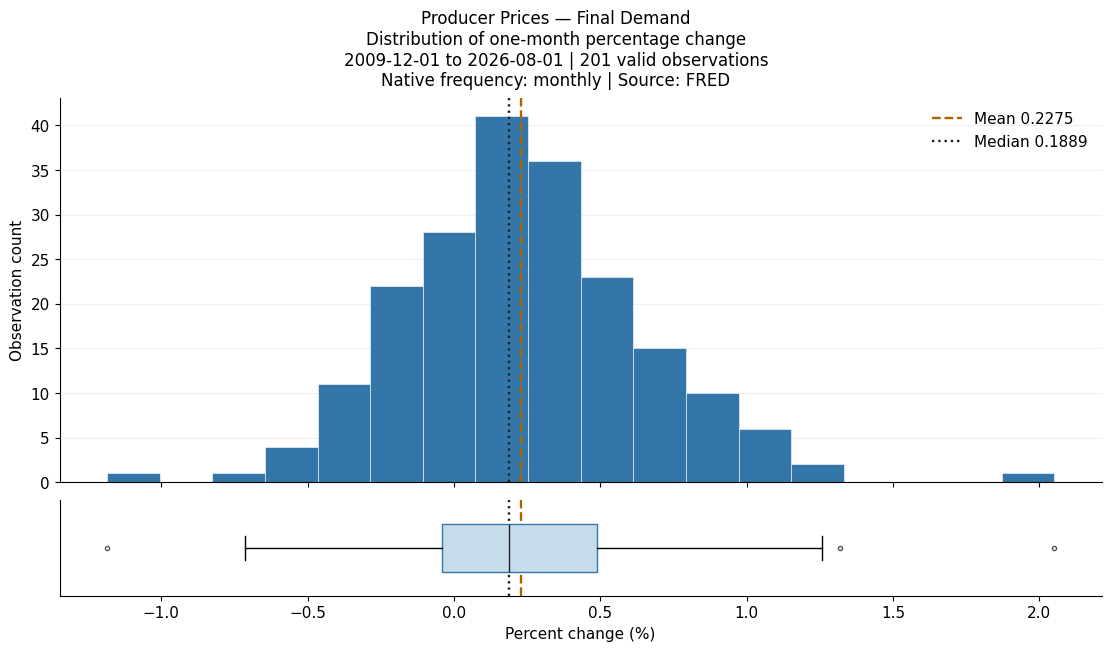

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,201,0.2275,0.1889,0.4297,0.28,0.4303,1.333,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: 0.765 / -0.837; delta: 0.430 / 1.333. Smaller moments alone do not establish stationarity or benchmark suitability.

In [55]:
plot_distribution('PPIFID', 'percentage_change')

In [56]:
dataset_header('PPIACO')

---
### PPIACO - Producer Prices — All Commodities

**Economic meaning:** Tracks selling prices received by domestic producers for a broad range of commodities.

**Raw distribution observation:** Skewness 0.926; excess kurtosis -0.314; minimum 10.3; maximum 290.2. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

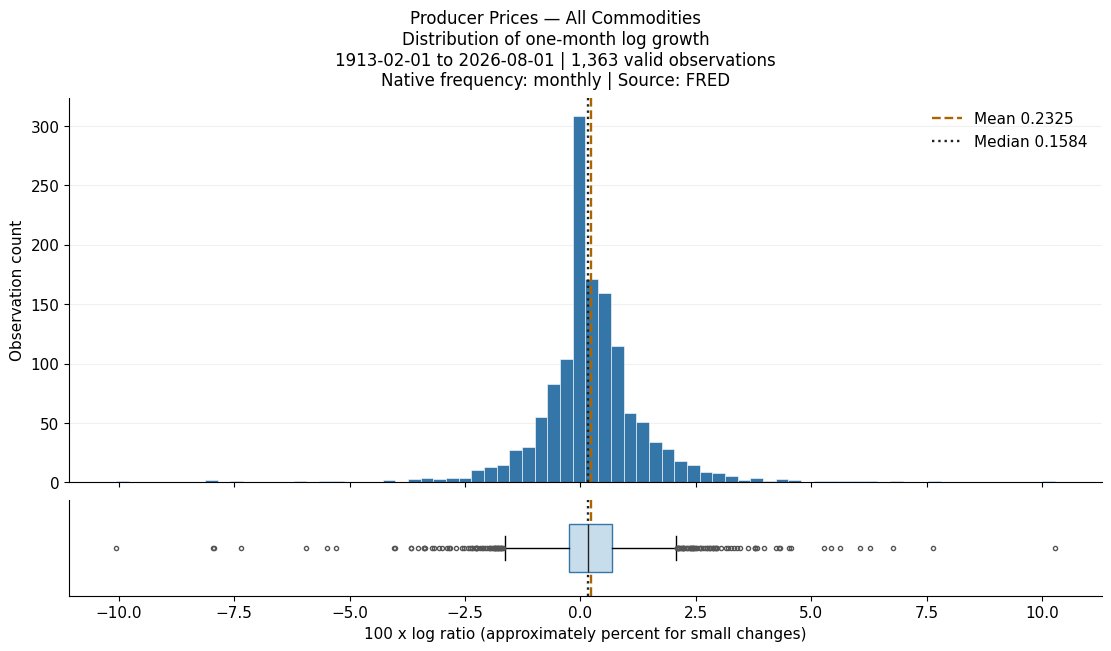

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,1363,0.2325,0.1584,1.279,0.4753,-0.1565,12.33,0


**Diagnostic:** approximately_symmetric; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.925 / -0.316; delta: -0.157 / 12.327. Smaller moments alone do not establish stationarity or benchmark suitability.

In [57]:
plot_distribution('PPIACO', 'log_change')

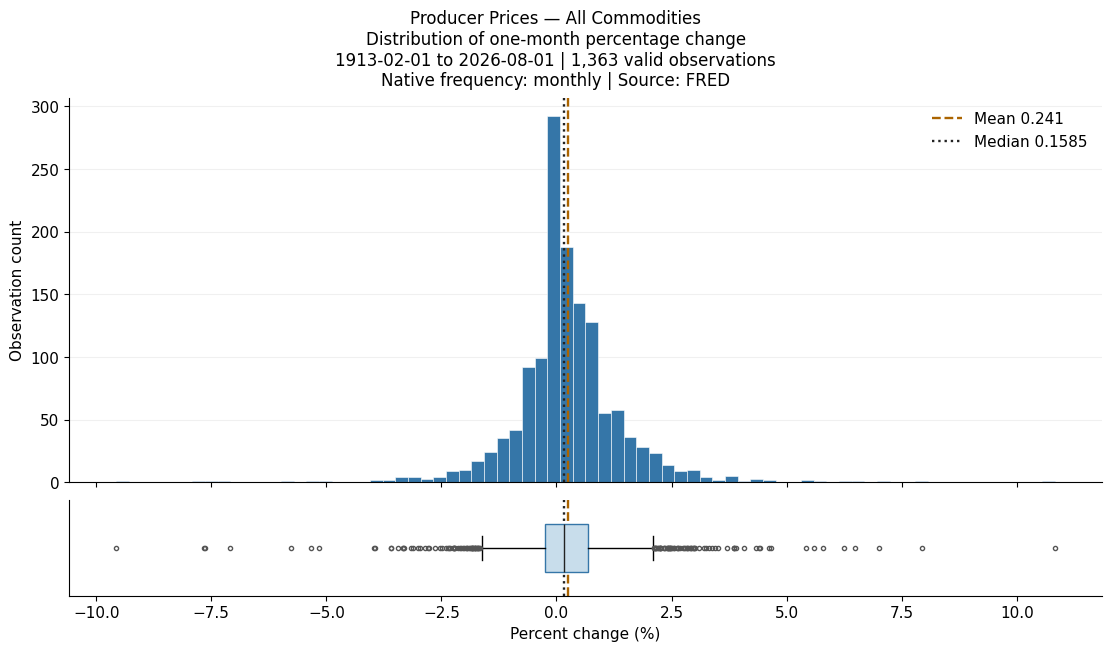

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,1363,0.241,0.1585,1.282,0.4759,0.1157,12.18,0


**Diagnostic:** approximately_symmetric; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.925 / -0.316; delta: 0.116 / 12.178. Smaller moments alone do not establish stationarity or benchmark suitability.

In [58]:
plot_distribution('PPIACO', 'percentage_change')

In [59]:
dataset_header('BUSLOANS')

---
### BUSLOANS - Commercial & Industrial Loans

**Economic meaning:** Measures the outstanding value of commercial and industrial loans held by U.S. commercial banks.

**Raw distribution observation:** Skewness 1.148; excess kurtosis 0.240; minimum 11.29; maximum 3,036. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

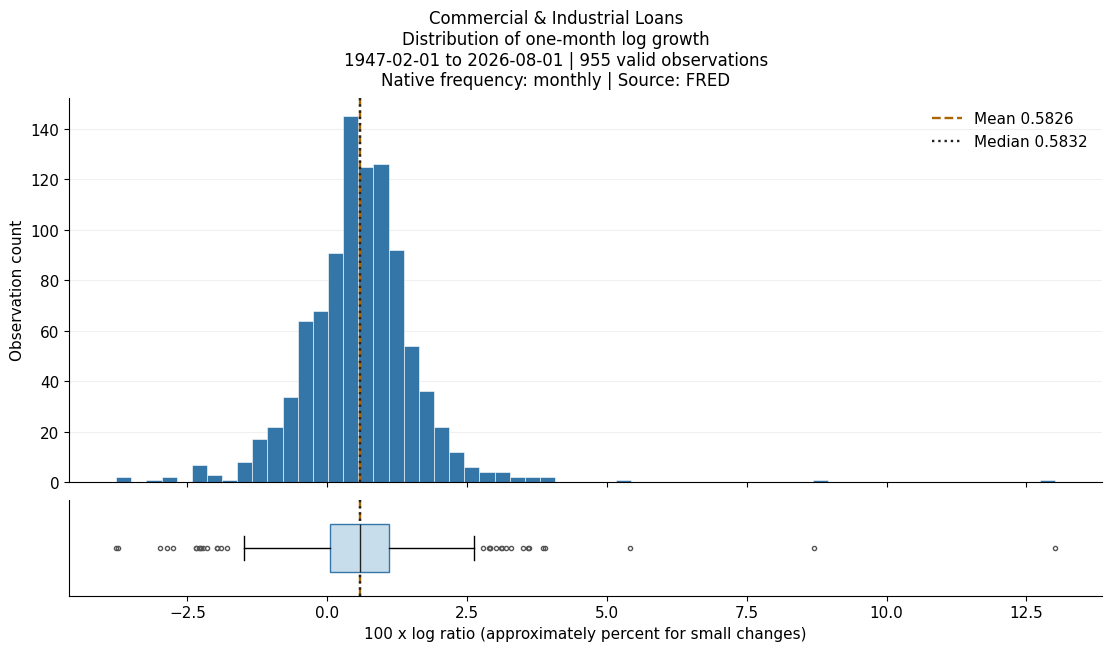

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,955,0.5826,0.5832,1.056,0.528,2.021,24.33,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.147 / 0.237; delta: 2.021 / 24.335. Smaller moments alone do not establish stationarity or benchmark suitability.

In [60]:
plot_distribution('BUSLOANS', 'log_change')

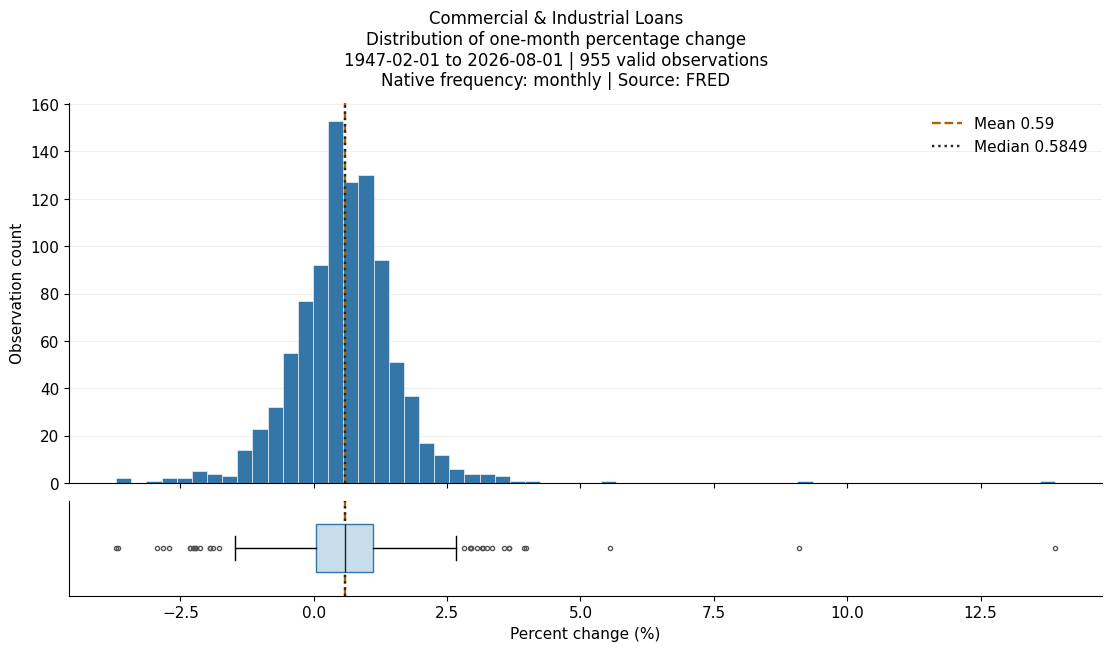

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,955,0.59,0.5849,1.075,0.5297,2.392,29.17,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.147 / 0.237; delta: 2.392 / 29.171. Smaller moments alone do not establish stationarity or benchmark suitability.

In [61]:
plot_distribution('BUSLOANS', 'percentage_change')

In [62]:
dataset_header('TOTALSL')

---
### TOTALSL - Consumer Credit

**Economic meaning:** Measures outstanding consumer credit owned and securitized, covering revolving and nonrevolving credit rather than home mortgages.

**Raw distribution observation:** Skewness 1.144; excess kurtosis 0.067; minimum 5,354; maximum 5.186e+06. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

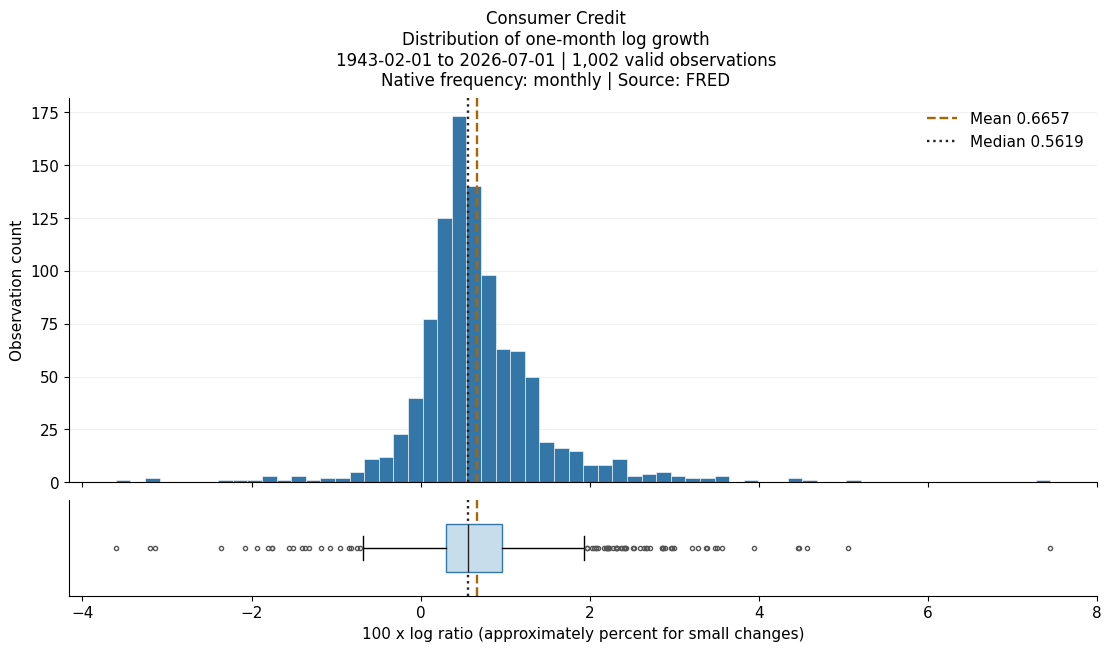

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,1002,0.6657,0.5619,0.8052,0.317,1.14,10.08,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.143 / 0.064; delta: 1.140 / 10.082. Smaller moments alone do not establish stationarity or benchmark suitability.

In [63]:
plot_distribution('TOTALSL', 'log_change')

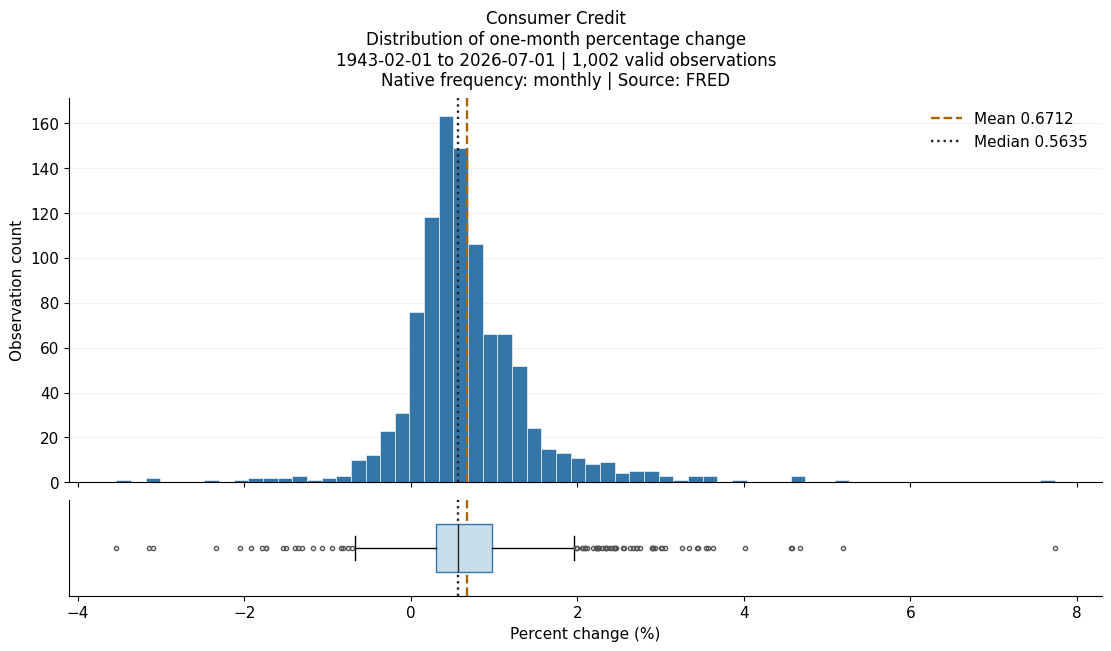

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,1002,0.6712,0.5635,0.8145,0.3188,1.271,10.67,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.143 / 0.064; delta: 1.271 / 10.669. Smaller moments alone do not establish stationarity or benchmark suitability.

In [64]:
plot_distribution('TOTALSL', 'percentage_change')

In [65]:
dataset_header('M2SL')

---
### M2SL - M2 Money Supply

**Economic meaning:** Measures a broad stock of money that includes currency, transaction deposits, and selected liquid savings instruments.

**Raw distribution observation:** Skewness 1.353; excess kurtosis 0.809; minimum 286.6; maximum 2.322e+04. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** monthly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-month log growth
- one-month percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

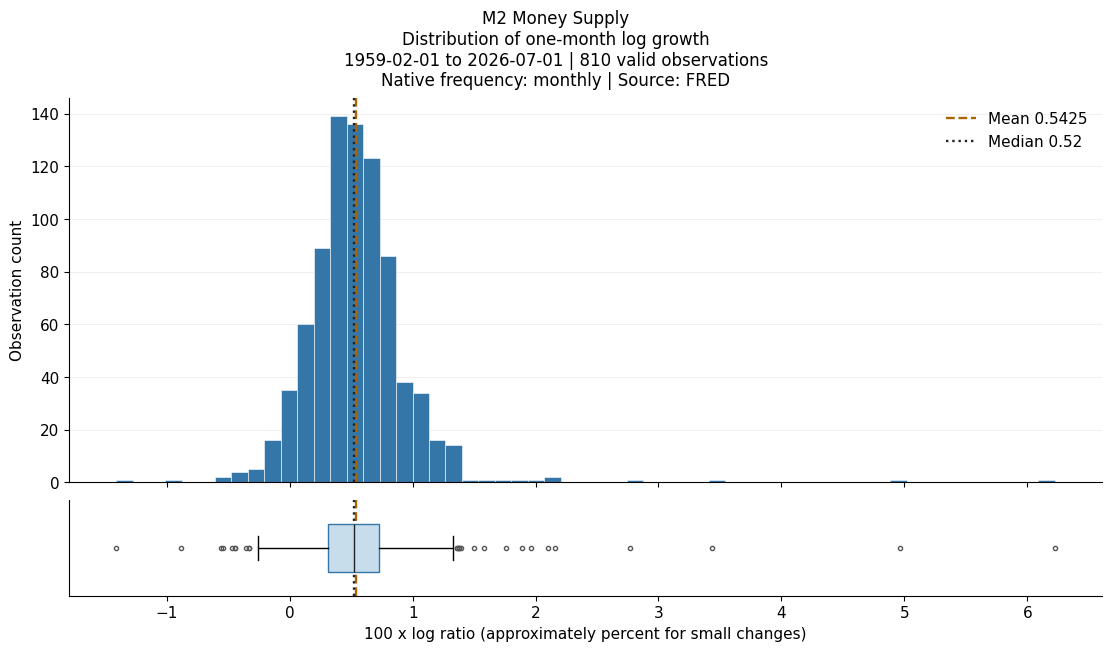

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,810,0.5425,0.52,0.4577,0.2068,3.946,42.11,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.352 / 0.805; delta: 3.946 / 42.106. Smaller moments alone do not establish stationarity or benchmark suitability.

In [66]:
plot_distribution('M2SL', 'log_change')

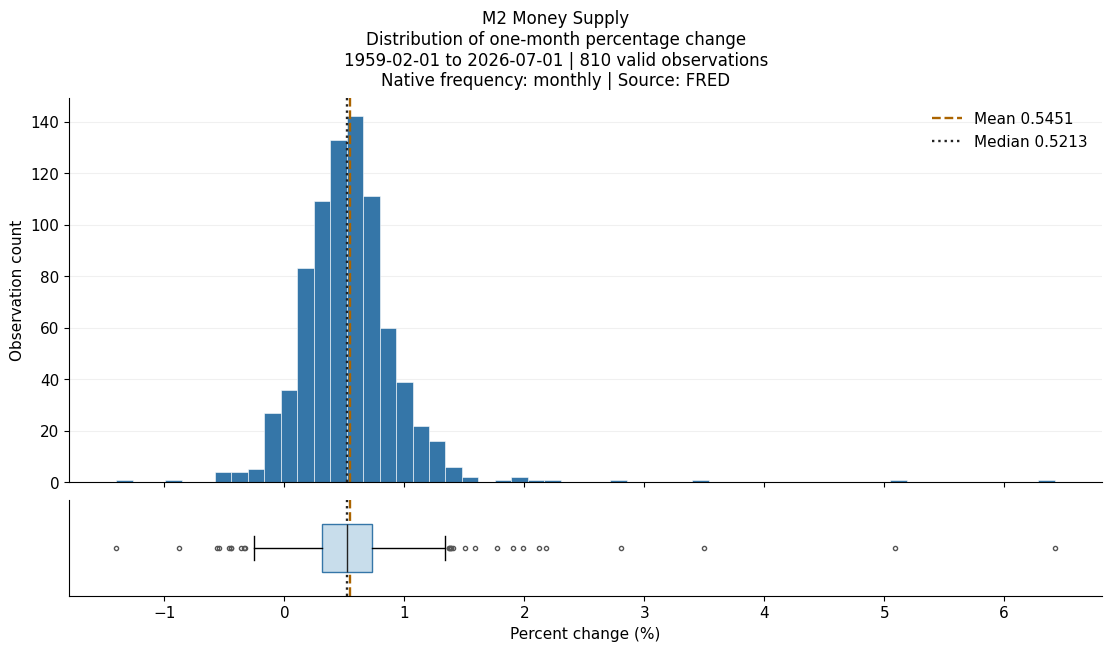

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,810,0.5451,0.5213,0.4645,0.2076,4.144,44.99,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.352 / 0.805; delta: 4.144 / 44.992. Smaller moments alone do not establish stationarity or benchmark suitability.

In [67]:
plot_distribution('M2SL', 'percentage_change')

In [68]:
dataset_header('EXPGSC1')

---
### EXPGSC1 - Real Exports of Goods and Services

**Economic meaning:** Measures the inflation-adjusted value of U.S. exports of goods and services.

**Raw distribution observation:** Skewness 0.753; excess kurtosis -0.930; minimum 57.66; maximum 2,788. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** quarterly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-quarter log growth
- one-quarter percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

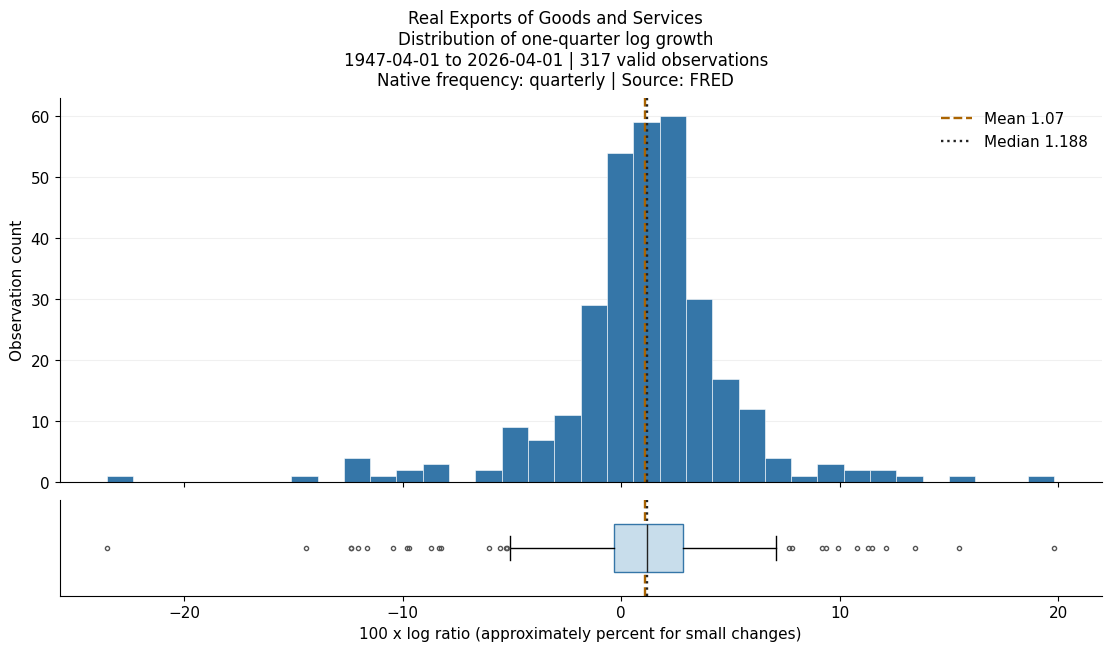

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,317,1.07,1.188,4.143,1.629,-0.7505,6.881,0


**Diagnostic:** left_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.749 / -0.936; delta: -0.751 / 6.881. Smaller moments alone do not establish stationarity or benchmark suitability.

In [69]:
plot_distribution('EXPGSC1', 'log_change')

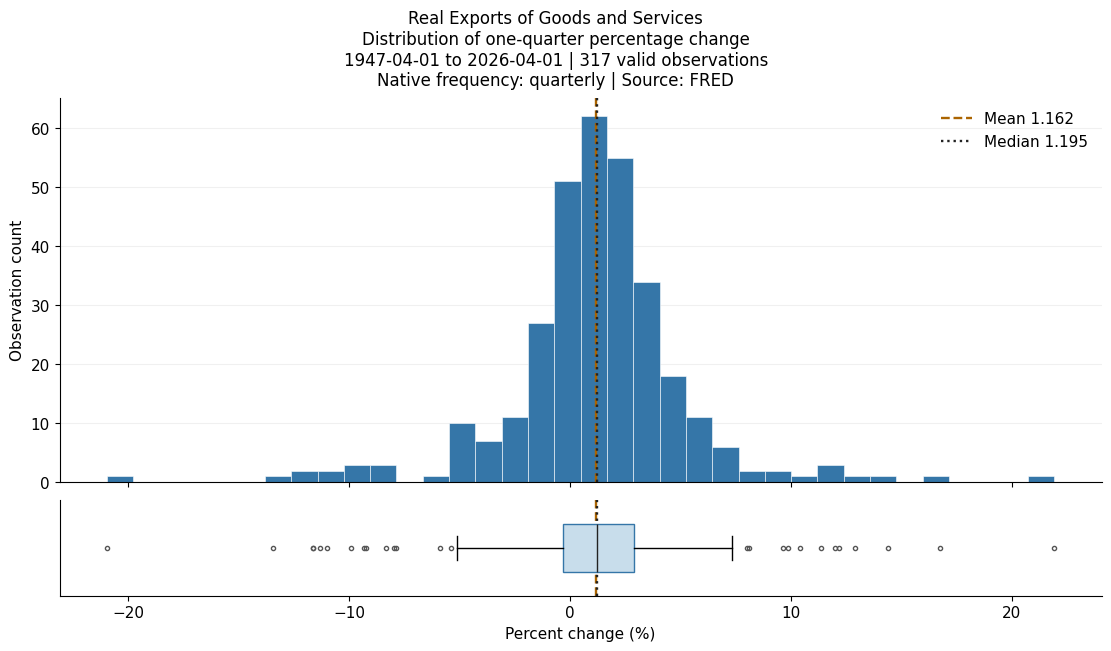

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,317,1.162,1.195,4.142,1.641,-0.2477,6.159,0


**Diagnostic:** approximately_symmetric; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.749 / -0.936; delta: -0.248 / 6.159. Smaller moments alone do not establish stationarity or benchmark suitability.

In [70]:
plot_distribution('EXPGSC1', 'percentage_change')

In [71]:
dataset_header('IMPGSC1')

---
### IMPGSC1 - Real Imports of Goods and Services

**Economic meaning:** Measures the inflation-adjusted value of U.S. imports of goods and services.

**Raw distribution observation:** Skewness 0.838; excess kurtosis -0.705; minimum 48.69; maximum 4,040. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** quarterly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-quarter log growth
- one-quarter percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

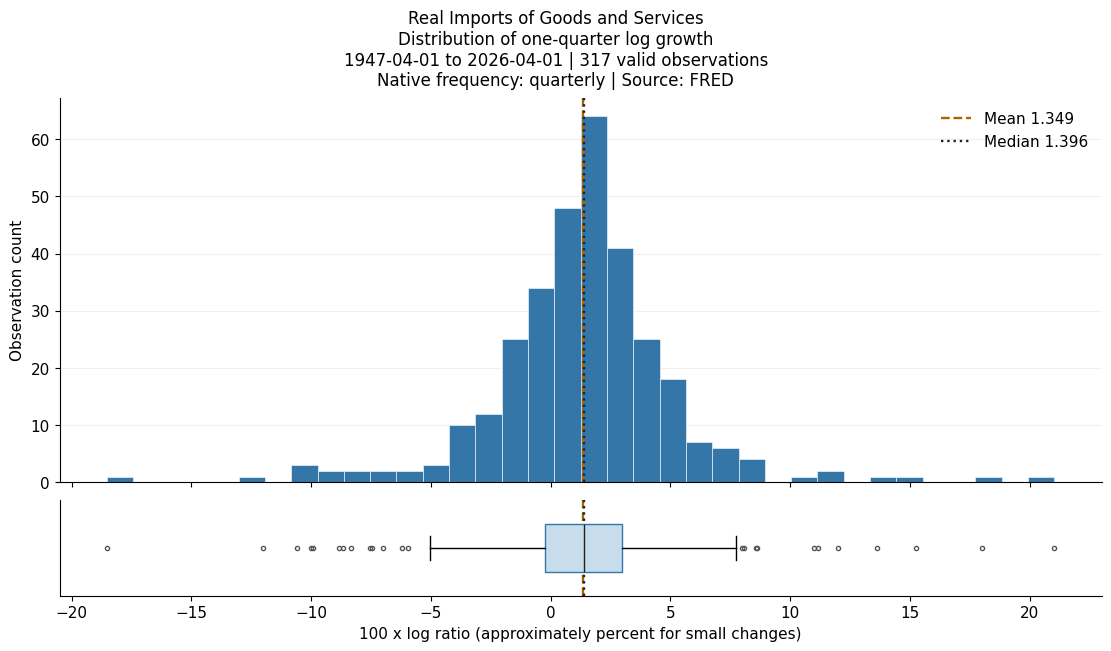

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,317,1.349,1.396,3.934,1.638,0.04336,5.773,0


**Diagnostic:** approximately_symmetric; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.834 / -0.712; delta: 0.043 / 5.773. Smaller moments alone do not establish stationarity or benchmark suitability.

In [72]:
plot_distribution('IMPGSC1', 'log_change')

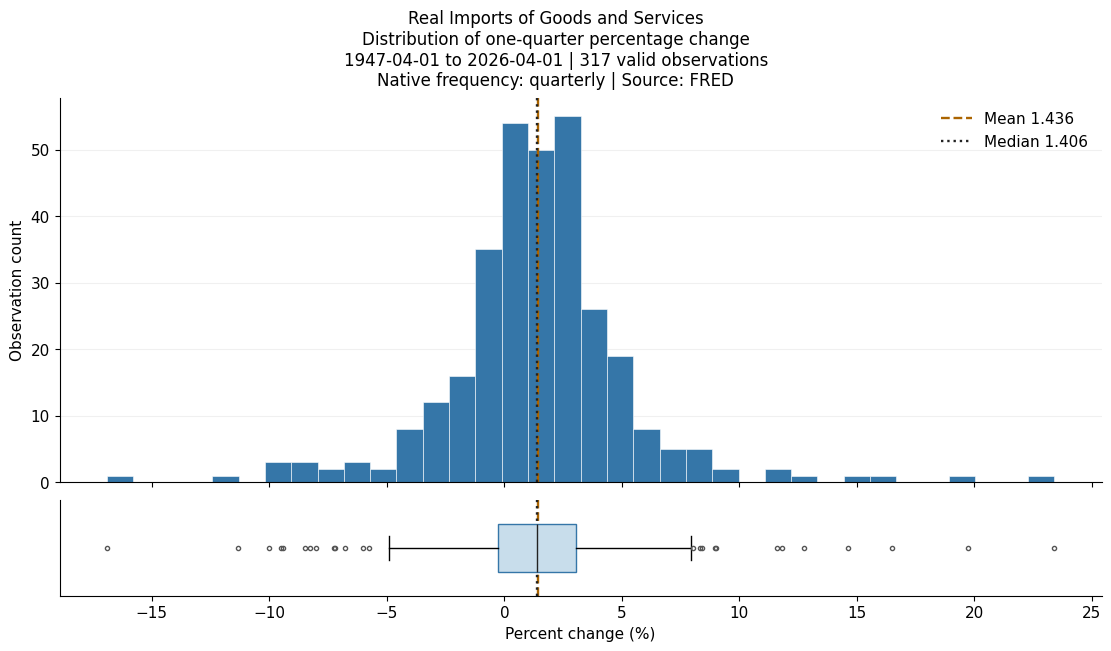

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,317,1.436,1.406,4.006,1.648,0.5016,6.293,0


**Diagnostic:** right_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.834 / -0.712; delta: 0.502 / 6.293. Smaller moments alone do not establish stationarity or benchmark suitability.

In [73]:
plot_distribution('IMPGSC1', 'percentage_change')

In [74]:
dataset_header('OPHNFB')

---
### OPHNFB - Nonfarm Business Sector Labor Productivity

**Economic meaning:** Measures real output per hour worked in the U.S. nonfarm business sector.

**Raw distribution observation:** Skewness 0.465; excess kurtosis -0.981; minimum 22.07; maximum 120. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Log-growth / percentage-growth mode

**Native frequency:** quarterly. **Suitability:** HIGH. Positive quantity, stock, or index: proportional movement has economic meaning; histogram shape alone does not select this family.

**Transformations shown:**
- one-quarter log growth
- one-quarter percentage change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

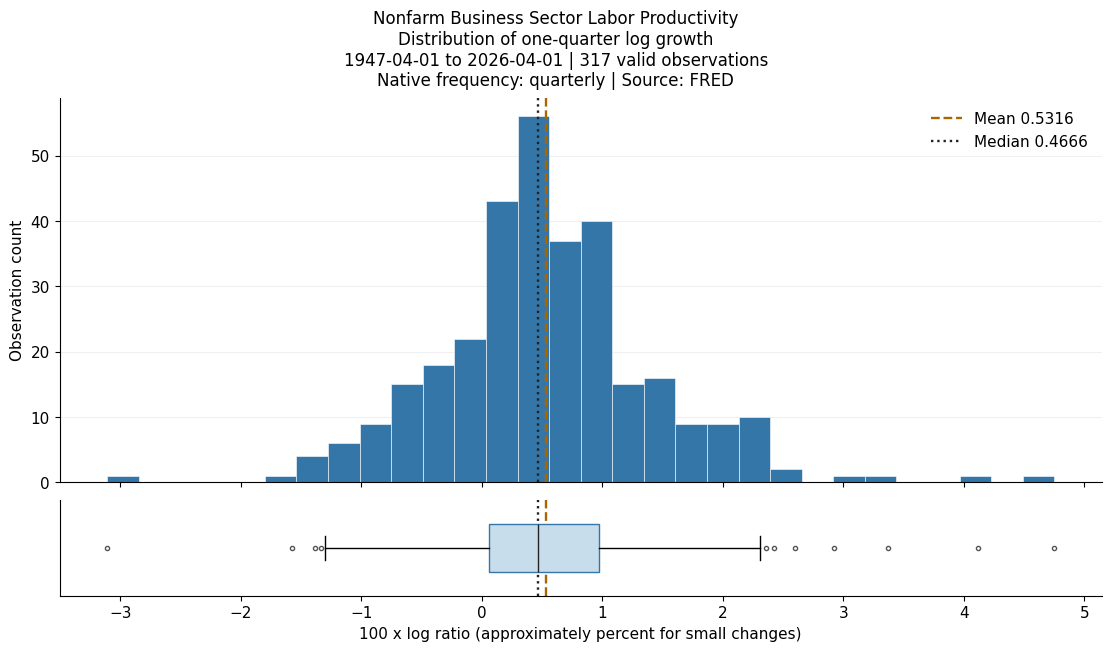

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,317,0.5316,0.4666,0.9019,0.4643,0.4729,2.511,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: 0.464 / -0.983; delta: 0.473 / 2.511. Smaller moments alone do not establish stationarity or benchmark suitability.

In [75]:
plot_distribution('OPHNFB', 'log_change')

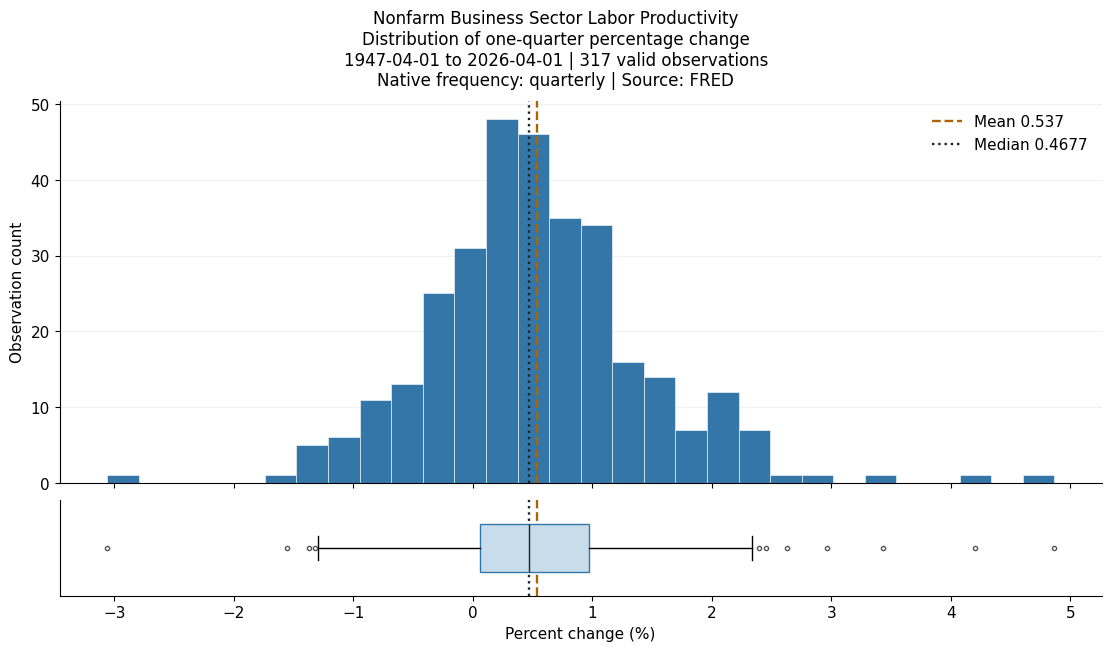

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,317,0.537,0.4677,0.9087,0.4676,0.5306,2.615,0


**Diagnostic:** right_skewed. Matched-date raw skewness / excess kurtosis: 0.464 / -0.983; delta: 0.531 / 2.615. Smaller moments alone do not establish stationarity or benchmark suitability.

In [76]:
plot_distribution('OPHNFB', 'percentage_change')

## 4. First-Difference Candidates

In [77]:
dataset_header('UNRATE')

---
### UNRATE - Unemployment Rate

**Economic meaning:** Measures the percentage of the U.S. civilian labor force that is unemployed and actively seeking work.

**Raw distribution observation:** Skewness 0.892; excess kurtosis 1.110; minimum 2.5; maximum 14.8. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** First-difference mode

**Native frequency:** monthly. **Suitability:** HIGH. Point/hour changes retain the economic meaning of rates, utilization, and hours; percentage growth can be misleading.

**Transformations shown:**
- one-month absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

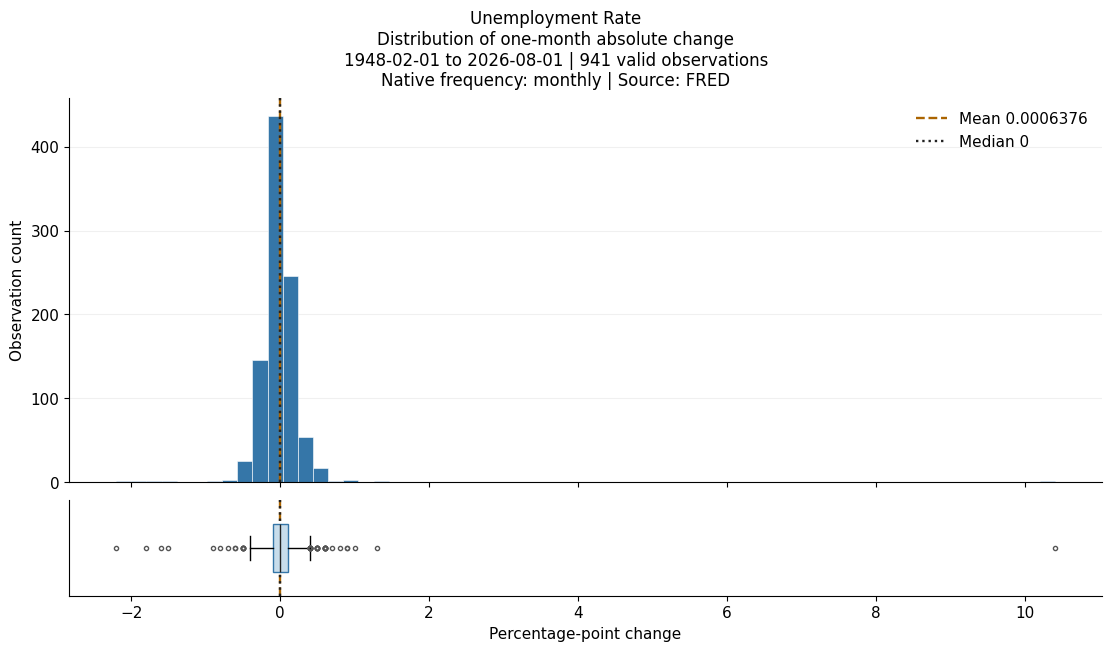

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,941,0.0006376,0,0.4131,0.1,16.72,429.1,1


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.891 / 1.110; delta: 16.722 / 429.137. Smaller moments alone do not establish stationarity or benchmark suitability.

In [78]:
plot_distribution('UNRATE', 'absolute_delta')

In [79]:
dataset_header('AWHAETP')

---
### AWHAETP - Average Weekly Hours — Total Private

**Economic meaning:** Measures average weekly hours worked by employees on U.S. private nonfarm payrolls.

**Raw distribution observation:** Skewness -0.414; excess kurtosis 1.709; minimum 33.7; maximum 35. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** First-difference mode

**Native frequency:** monthly. **Suitability:** HIGH. Point/hour changes retain the economic meaning of rates, utilization, and hours; percentage growth can be misleading.

**Transformations shown:**
- one-month absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

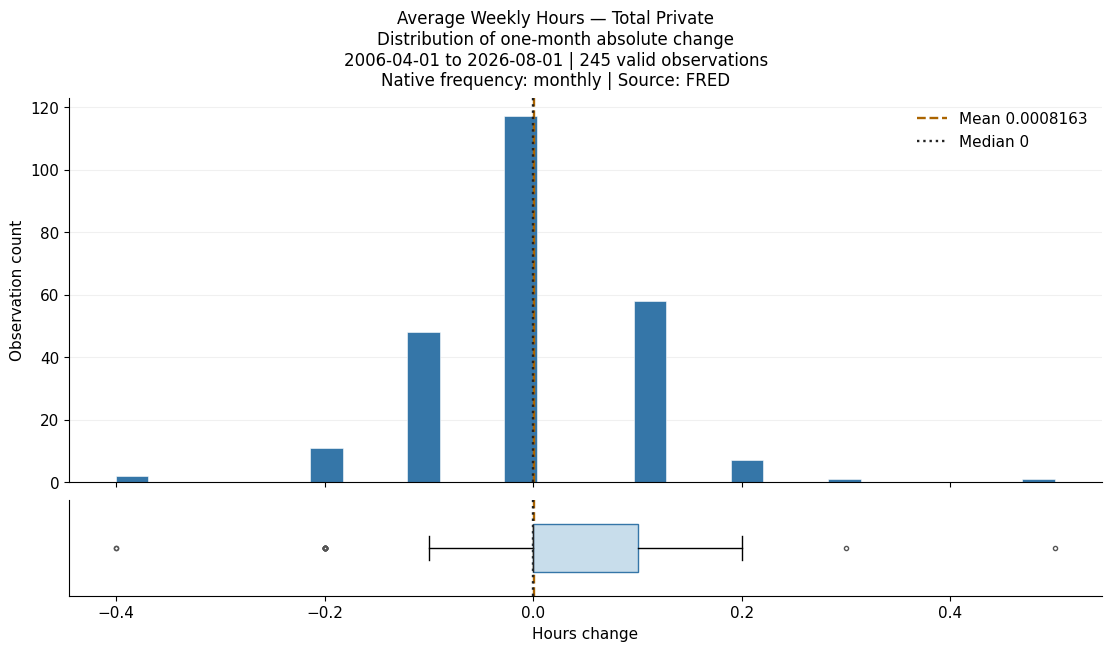

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,245,0.0008163,0,0.1,0.1,-0.01643,3.735,0


**Diagnostic:** approximately_symmetric; heavy_tailed. Matched-date raw skewness / excess kurtosis: -0.423 / 1.724; delta: -0.016 / 3.735. Smaller moments alone do not establish stationarity or benchmark suitability.

In [80]:
plot_distribution('AWHAETP', 'absolute_delta')

In [81]:
dataset_header('AWHMAN')

---
### AWHMAN - Average Weekly Hours — Manufacturing

**Economic meaning:** Measures average weekly hours worked by production and nonsupervisory employees in U.S. manufacturing.

**Raw distribution observation:** Skewness 1.168; excess kurtosis 5.232; minimum 37; maximum 45.7. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** First-difference mode

**Native frequency:** monthly. **Suitability:** HIGH. Point/hour changes retain the economic meaning of rates, utilization, and hours; percentage growth can be misleading.

**Transformations shown:**
- one-month absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

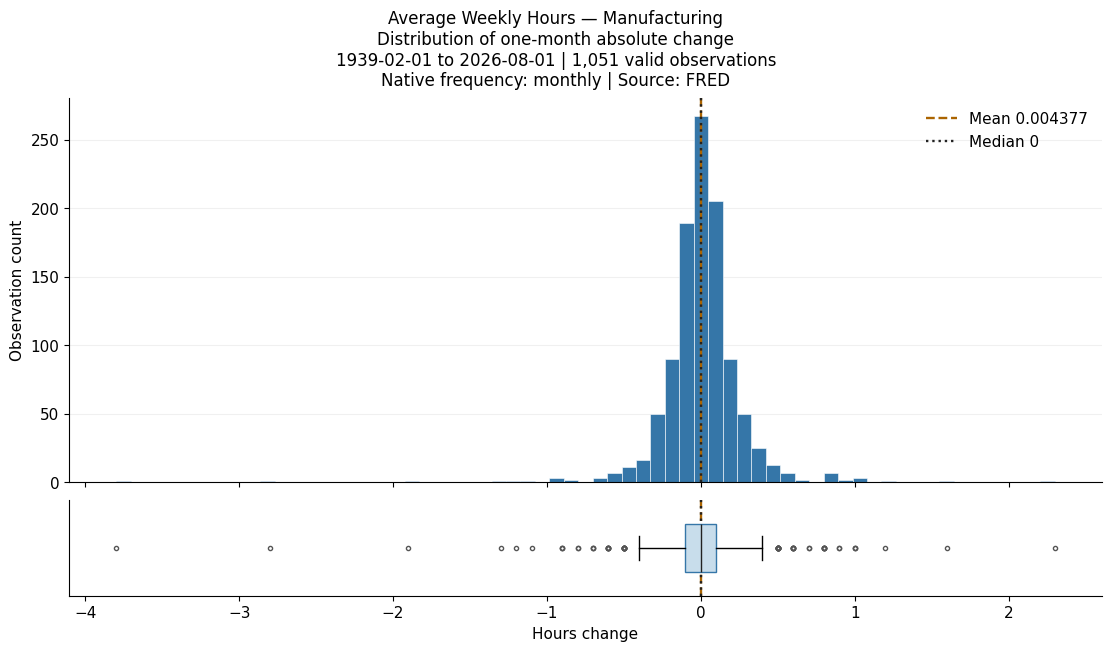

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,1051,0.004377,0,0.2968,0.1,-2.439,39.43,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.207 / 5.271; delta: -2.439 / 39.429. Smaller moments alone do not establish stationarity or benchmark suitability.

In [82]:
plot_distribution('AWHMAN', 'absolute_delta')

In [83]:
dataset_header('CIVPART')

---
### CIVPART - Labor Force Participation Rate

**Economic meaning:** Measures the share of the civilian noninstitutional population aged 16 and over that is working or actively seeking work.

**Raw distribution observation:** Skewness -0.007; excess kurtosis -1.416; minimum 58.1; maximum 67.3. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** First-difference mode

**Native frequency:** monthly. **Suitability:** HIGH. Point/hour changes retain the economic meaning of rates, utilization, and hours; percentage growth can be misleading.

**Transformations shown:**
- one-month absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

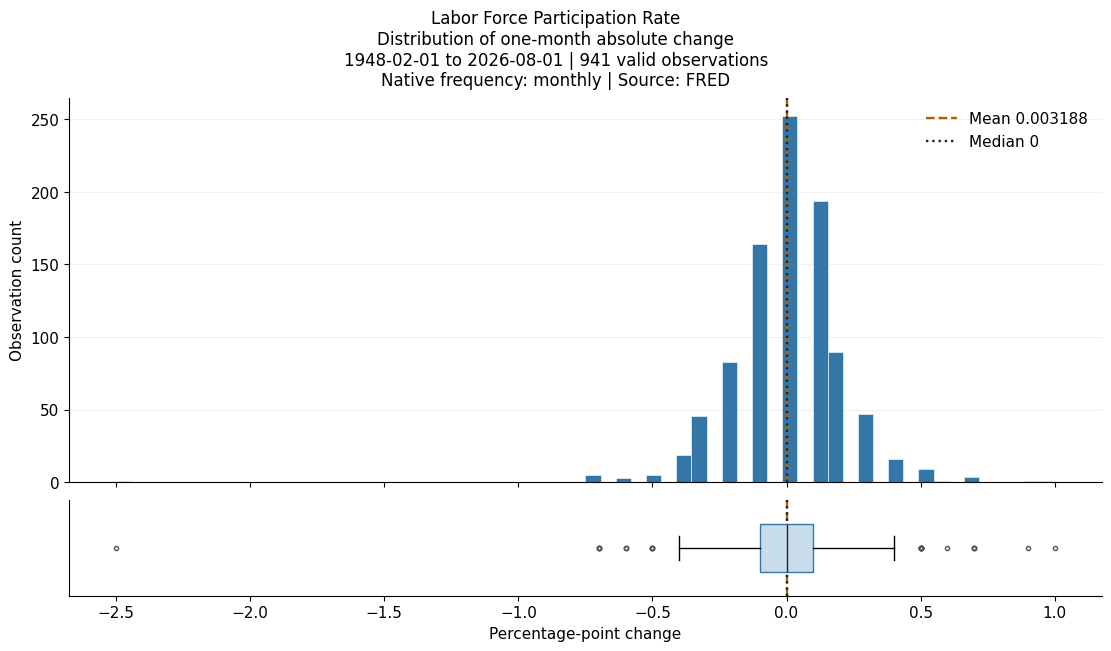

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,941,0.003188,0,0.2111,0.1,-1.661,22.04,1


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: -0.009 / -1.417; delta: -1.661 / 22.039. Smaller moments alone do not establish stationarity or benchmark suitability.

In [84]:
plot_distribution('CIVPART', 'absolute_delta')

In [85]:
dataset_header('FEDFUNDS')

---
### FEDFUNDS - Federal Funds Rate

**Economic meaning:** Measures the effective overnight interest rate at which depository institutions lend reserve balances to one another.

**Raw distribution observation:** Skewness 1.089; excess kurtosis 1.769; minimum 0.05; maximum 19.1. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** First-difference mode

**Native frequency:** monthly. **Suitability:** HIGH. Point/hour changes retain the economic meaning of rates, utilization, and hours; percentage growth can be misleading.

**Transformations shown:**
- one-month absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

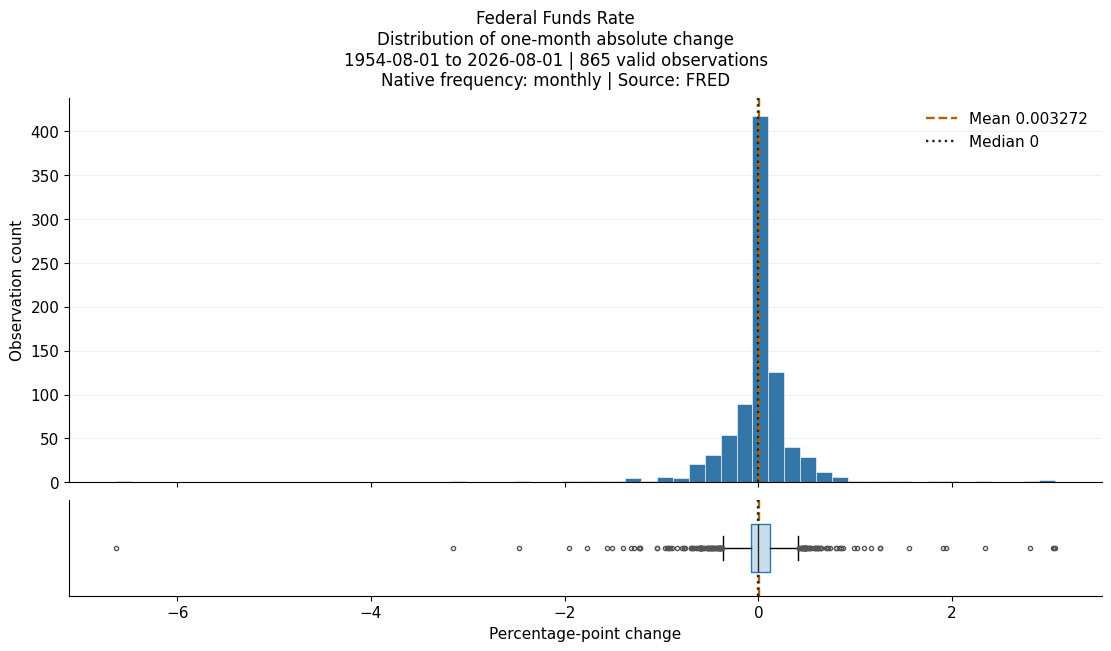

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,865,0.003272,0,0.4788,0.1,-2.449,53.27,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.088 / 1.769; delta: -2.449 / 53.272. Smaller moments alone do not establish stationarity or benchmark suitability.

In [86]:
plot_distribution('FEDFUNDS', 'absolute_delta')

In [87]:
dataset_header('TCU')

---
### TCU - Total Capacity Utilization

**Economic meaning:** Measures industrial output as a percentage of estimated production capacity across manufacturing, mining, and utilities.

**Raw distribution observation:** Skewness -0.195; excess kurtosis 0.231; minimum 64.08; maximum 89.39. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** First-difference mode

**Native frequency:** monthly. **Suitability:** HIGH. Point/hour changes retain the economic meaning of rates, utilization, and hours; percentage growth can be misleading.

**Transformations shown:**
- one-month absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

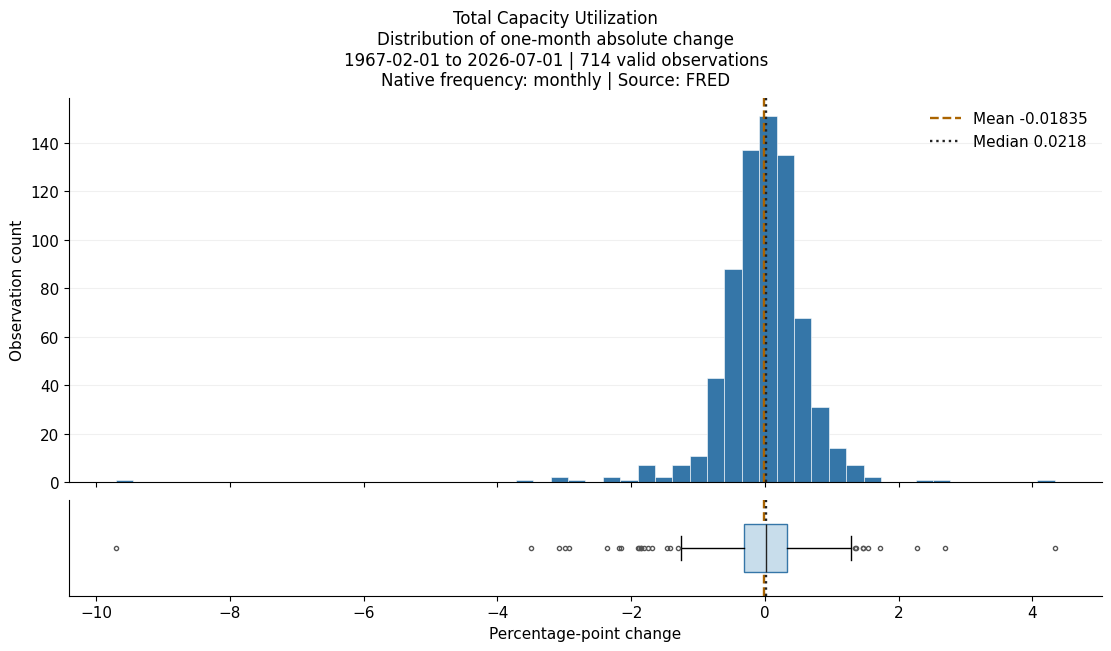

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,714,-0.01835,0.0218,0.7179,0.3268,-3.648,49.74,0


**Diagnostic:** left_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: -0.204 / 0.233; delta: -3.648 / 49.740. Smaller moments alone do not establish stationarity or benchmark suitability.

In [88]:
plot_distribution('TCU', 'absolute_delta')

## 5. Stress / Event Variables

In [89]:
dataset_header('ICSA')

---
### ICSA - Initial Claims

**Economic meaning:** Counts initial applications for unemployment insurance benefits, providing a weekly measure of new claims.

**Raw distribution observation:** Skewness 14.458; excess kurtosis 289.568; minimum 1.62e+05; maximum 6.137e+06. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Exploratory stress delta

**Native frequency:** weekly. **Suitability:** SPECIAL_CASE. Event-sensitive stress measure; right tails do not automatically indicate secular growth. Compare absolute and proportional changes.

**Transformations shown:**
- one-week absolute change
- one-week percentage change
- one-week log growth

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

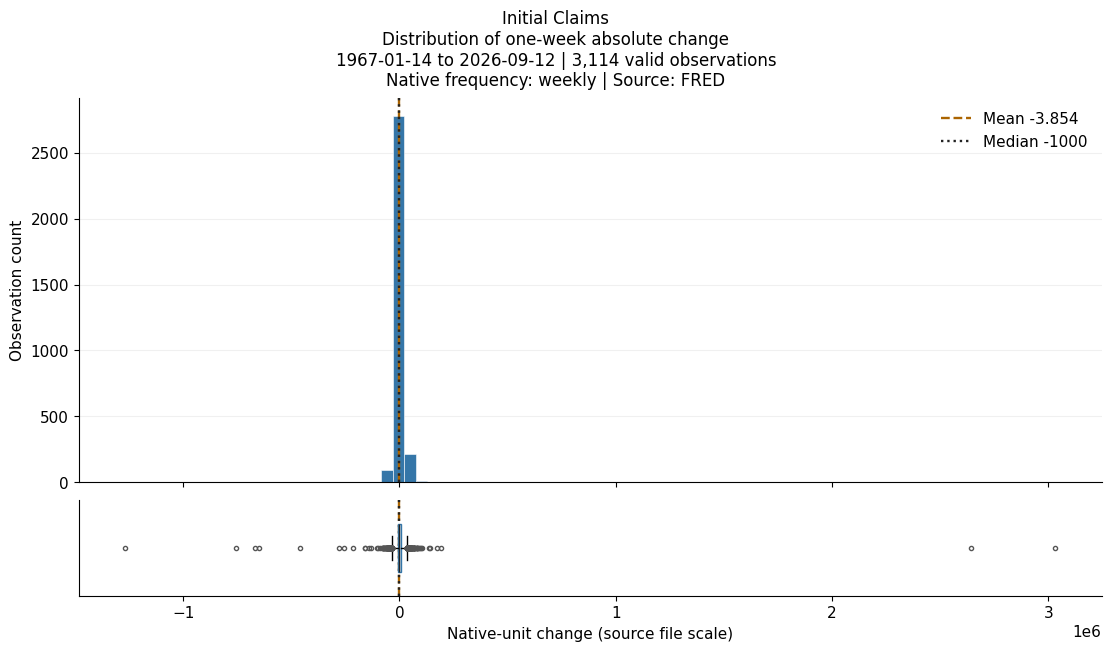

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,3114,-3.854,"-1,000",8.166e+04,"8,000",25.45,985,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 14.458 / 289.538; delta: 25.447 / 985.009. Smaller moments alone do not establish stationarity or benchmark suitability.

In [90]:
plot_distribution('ICSA', 'absolute_delta')

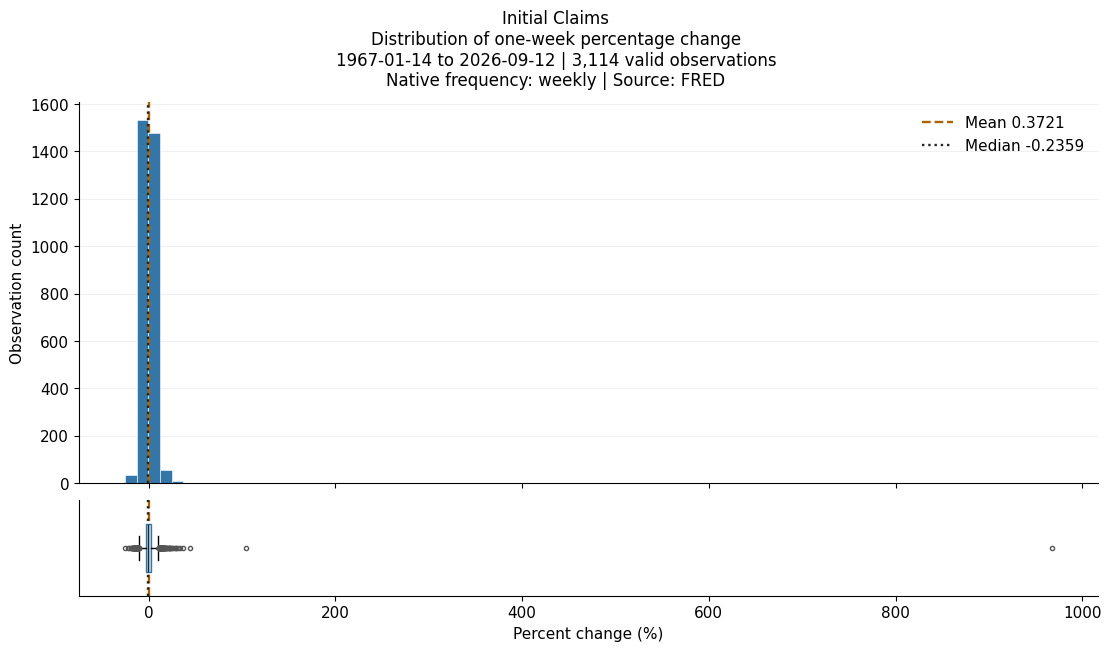

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,3114,0.3721,-0.2359,18.17,2.578,48.49,"2,577",0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 14.458 / 289.538; delta: 48.494 / 2576.890. Smaller moments alone do not establish stationarity or benchmark suitability.

In [91]:
plot_distribution('ICSA', 'percentage_change')

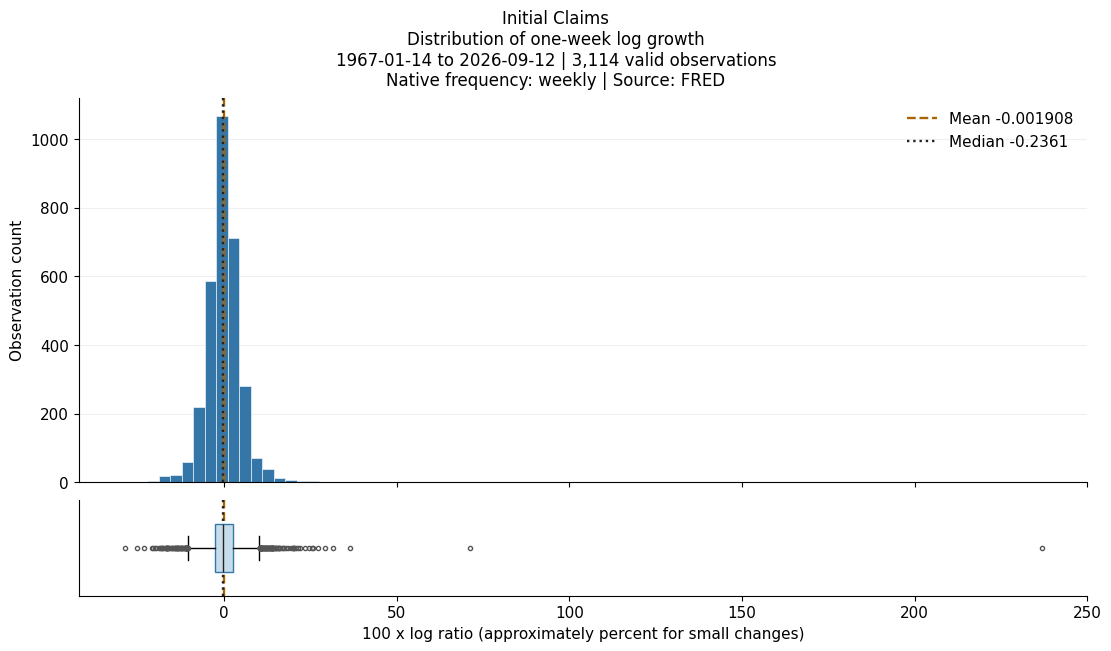

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,3114,-0.001908,-0.2361,6.726,2.577,14.56,497.9,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 14.458 / 289.538; delta: 14.556 / 497.879. Smaller moments alone do not establish stationarity or benchmark suitability.

In [92]:
plot_distribution('ICSA', 'log_change')

In [93]:
dataset_header('DRBLACBS')

---
### DRBLACBS - Delinquency Rate on Business Loans

**Economic meaning:** Measures the percentage of business loans at commercial banks that are delinquent.

**Raw distribution observation:** Skewness 1.161; excess kurtosis 0.143; minimum 0.72; maximum 6.75. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Exploratory stress delta

**Native frequency:** quarterly. **Suitability:** SPECIAL_CASE. Event-sensitive stress measure; right tails do not automatically indicate secular growth. Compare absolute and proportional changes.

**Transformations shown:**
- one-quarter absolute change
- one-quarter percentage change
- one-quarter log growth

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

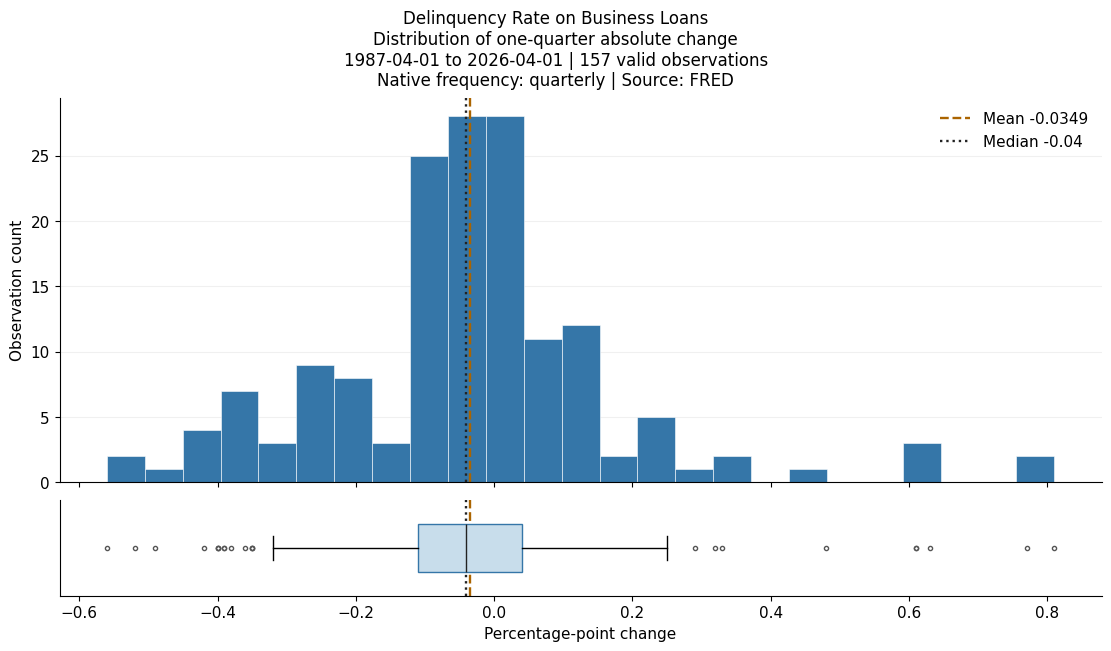

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,157,-0.0349,-0.04,0.2164,0.08,0.8684,3.046,0


**Diagnostic:** right_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.167 / 0.165; delta: 0.868 / 3.046. Smaller moments alone do not establish stationarity or benchmark suitability.

In [94]:
plot_distribution('DRBLACBS', 'absolute_delta')

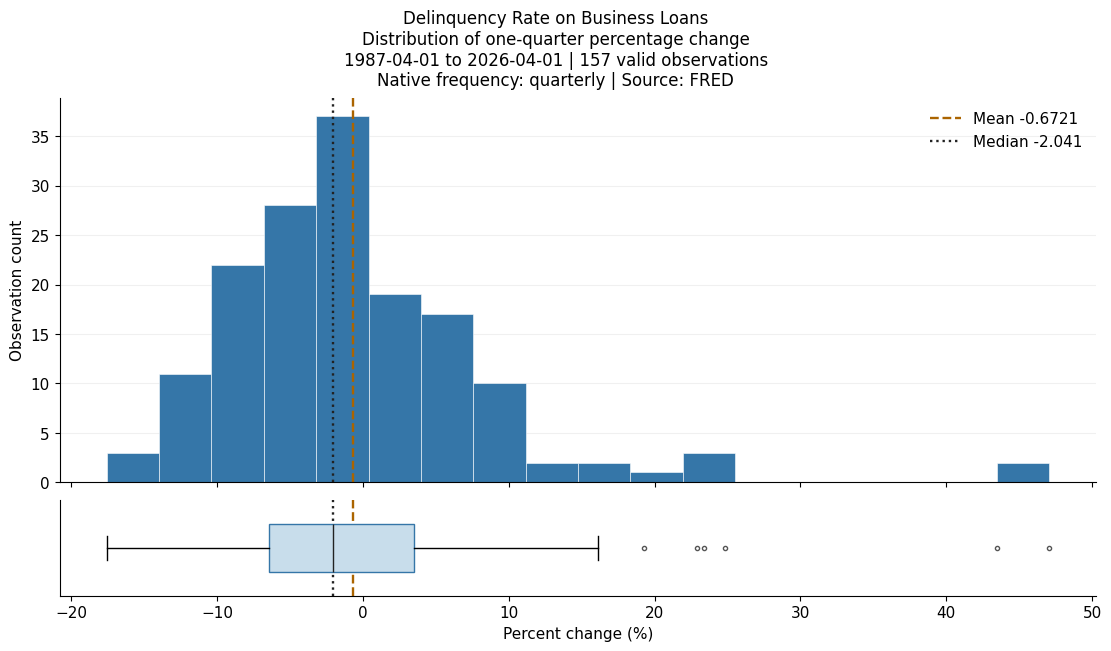

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,157,-0.6721,-2.041,9.209,5.041,1.963,7.133,0


**Diagnostic:** right_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.167 / 0.165; delta: 1.963 / 7.133. Smaller moments alone do not establish stationarity or benchmark suitability.

In [95]:
plot_distribution('DRBLACBS', 'percentage_change')

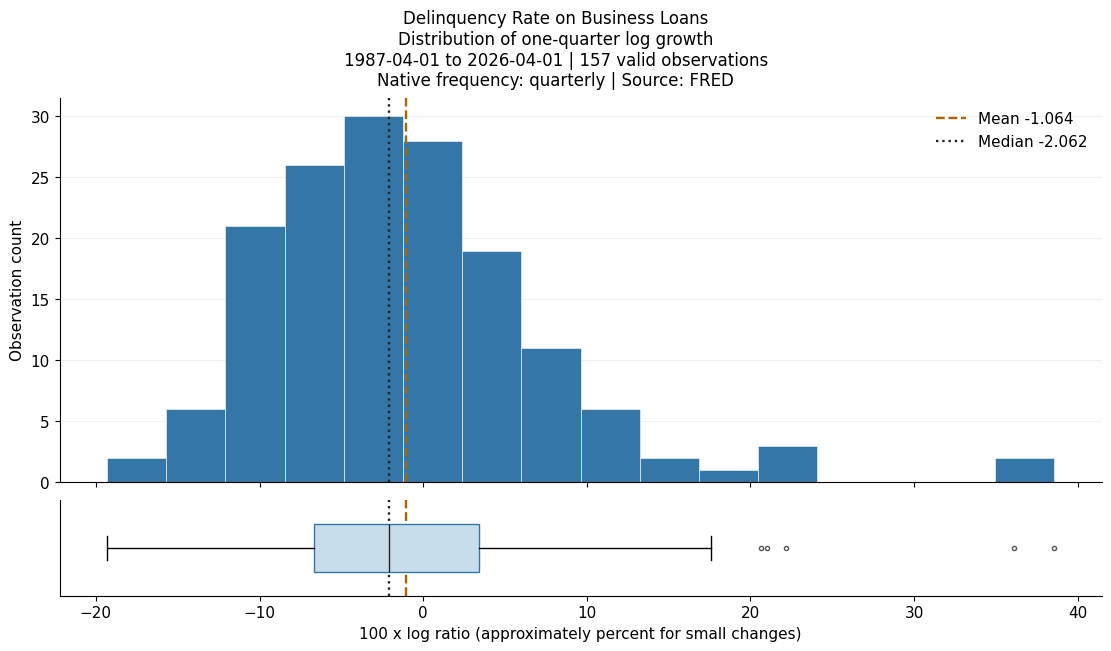

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,157,-1.064,-2.062,8.675,5.018,1.382,4.085,0


**Diagnostic:** right_skewed; heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.167 / 0.165; delta: 1.382 / 4.085. Smaller moments alone do not establish stationarity or benchmark suitability.

In [96]:
plot_distribution('DRBLACBS', 'log_change')

## 6. Semantic-Balance Variables

In [97]:
dataset_header('DRTSCILM')

---
### DRTSCILM - SLOOS: Banks Tightening C&I Lending Standards

**Economic meaning:** Measures the net percentage of surveyed banks reporting tighter lending standards for commercial and industrial loans to large and middle-market firms.

**Raw distribution observation:** Skewness 1.038; excess kurtosis 0.484; minimum -32.4; maximum 83.6. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Semantic-balance mode

**Native frequency:** quarterly. **Suitability:** SPECIAL_CASE. Native zero remains economically meaningful. Delta measures momentum, not a replacement for the level.

**Transformations shown:**
- one-quarter absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

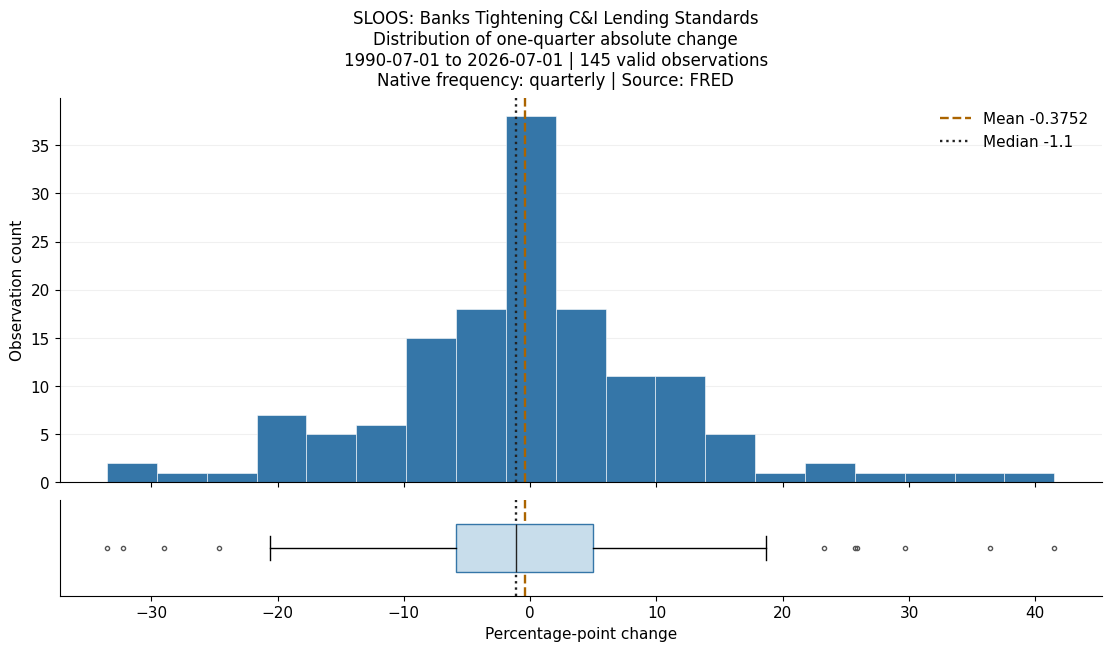

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,145,-0.3752,-1.1,11.69,5.8,0.2683,1.758,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: 1.062 / 0.603; delta: 0.268 / 1.758. Smaller moments alone do not establish stationarity or benchmark suitability.

In [98]:
plot_distribution('DRTSCILM', 'absolute_delta')

In [99]:
dataset_header('DRSDCILM')

---
### DRSDCILM - SLOOS: Stronger Demand for C&I Loans

**Economic meaning:** Measures the net percentage of surveyed banks reporting stronger demand for commercial and industrial loans from large and middle-market firms.

**Raw distribution observation:** Skewness -0.420; excess kurtosis -0.107; minimum -70.2; maximum 45.8. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** Semantic-balance mode

**Native frequency:** quarterly. **Suitability:** SPECIAL_CASE. Native zero remains economically meaningful. Delta measures momentum, not a replacement for the level.

**Transformations shown:**
- one-quarter absolute change

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

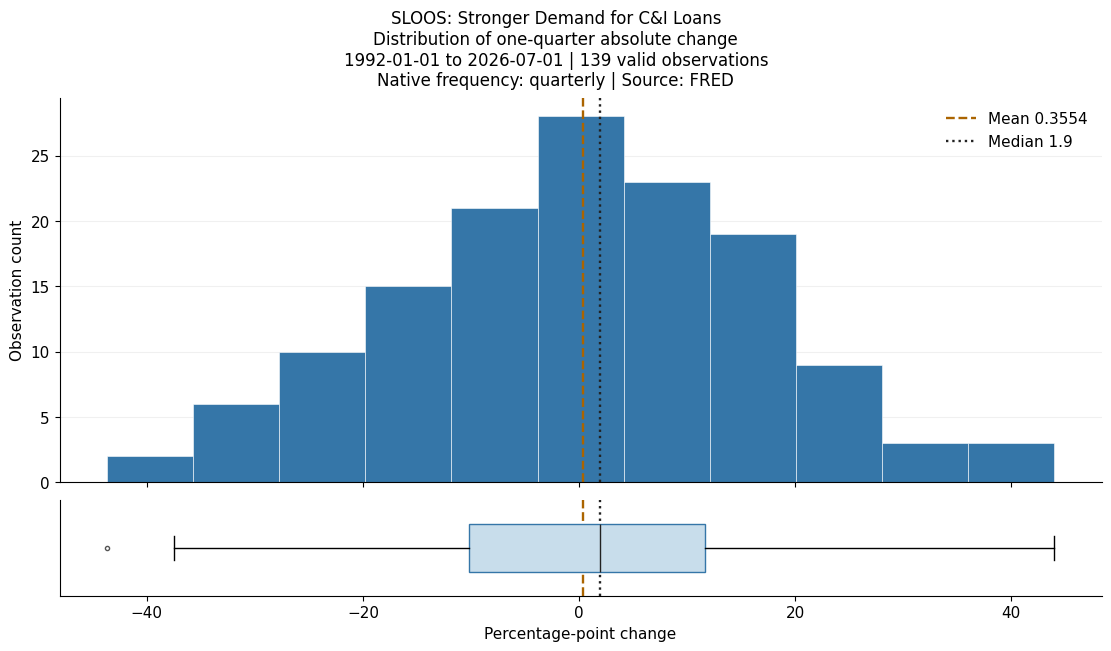

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,139,0.3554,1.9,16.92,11.1,-0.05778,-0.09625,0


**Diagnostic:** approximately_symmetric. Matched-date raw skewness / excess kurtosis: -0.439 / -0.062; delta: -0.058 / -0.096. Smaller moments alone do not establish stationarity or benchmark suitability.

In [100]:
plot_distribution('DRSDCILM', 'absolute_delta')

## 7. Regime-Sensitive Liquidity Variables

In [101]:
dataset_header('TOTRESNS')

---
### TOTRESNS - Total Bank Reserves

**Economic meaning:** Measures total reserves held by depository institutions, including reserve balances and qualifying vault cash.

**Raw distribution observation:** Skewness 1.545; excess kurtosis 0.890; minimum 18; maximum 4,193. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** REGIME-SENSITIVE - DELTA ANALYSIS ONLY

**Native frequency:** monthly. **Suitability:** SPECIAL_CASE. Delta is useful, but liquidity/policy regime changes may persist after transformation.

**Transformations shown:**
- one-month absolute change
- one-month percentage change
- one-month log growth

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

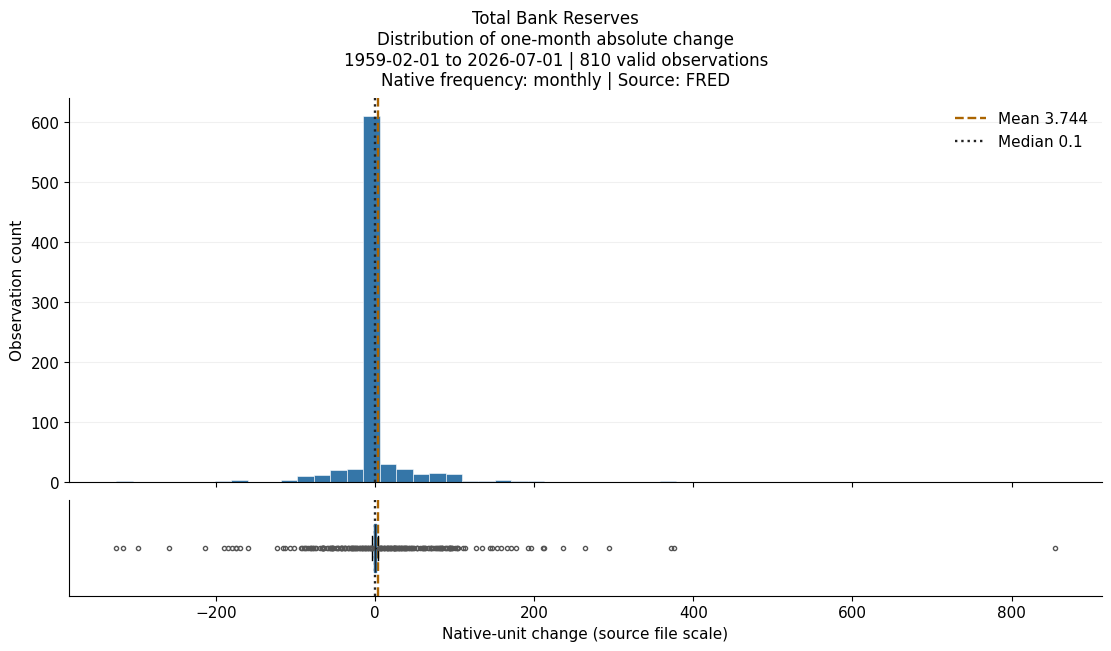

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,810,3.744,0.1,58.99,0.8,4.042,62.33,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.543 / 0.884; delta: 4.042 / 62.328. Smaller moments alone do not establish stationarity or benchmark suitability.

In [102]:
plot_distribution('TOTRESNS', 'absolute_delta')

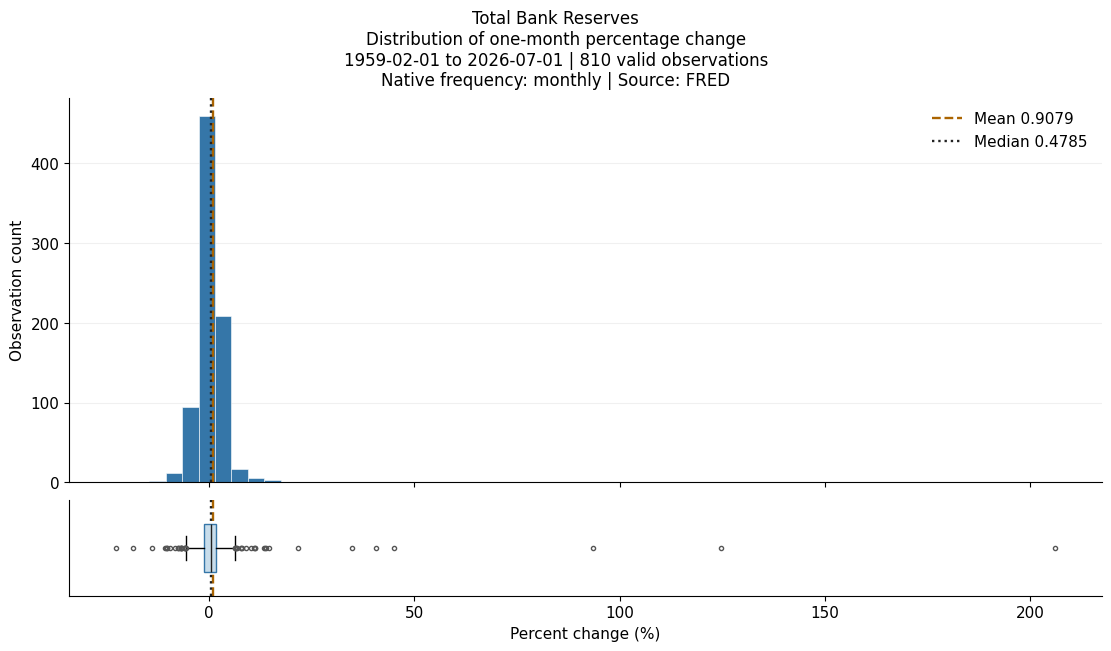

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,810,0.9079,0.4785,9.902,1.532,14.64,266.9,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.543 / 0.884; delta: 14.642 / 266.863. Smaller moments alone do not establish stationarity or benchmark suitability.

In [103]:
plot_distribution('TOTRESNS', 'percentage_change')

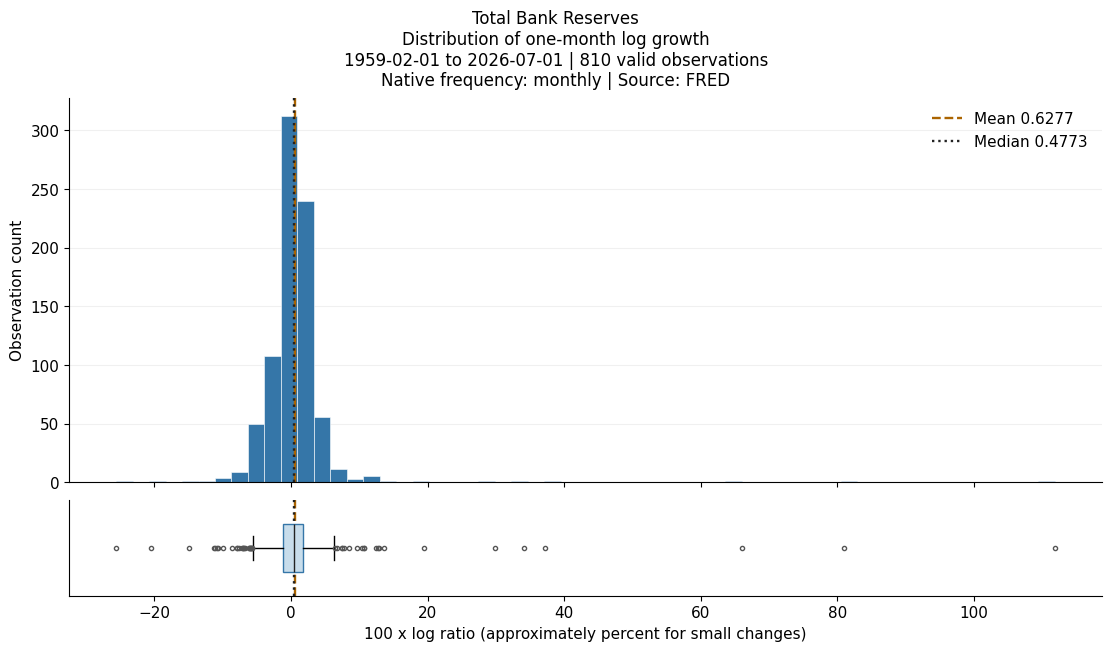

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,810,0.6277,0.4773,6.58,1.532,9.794,141.6,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 1.543 / 0.884; delta: 9.794 / 141.585. Smaller moments alone do not establish stationarity or benchmark suitability.

In [104]:
plot_distribution('TOTRESNS', 'log_change')

In [105]:
dataset_header('WRESBAL')

---
### WRESBAL - Reserve Balances with Federal Reserve Banks

**Economic meaning:** Measures reserve balances held by depository institutions at Federal Reserve Banks.

**Raw distribution observation:** Skewness -0.106; excess kurtosis -1.237; minimum 2,795; maximum 4.276e+06. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** REGIME-SENSITIVE - DELTA ANALYSIS ONLY

**Native frequency:** weekly. **Suitability:** SPECIAL_CASE. Delta is useful, but liquidity/policy regime changes may persist after transformation.

**Transformations shown:**
- one-week absolute change
- one-week percentage change
- one-week log growth

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

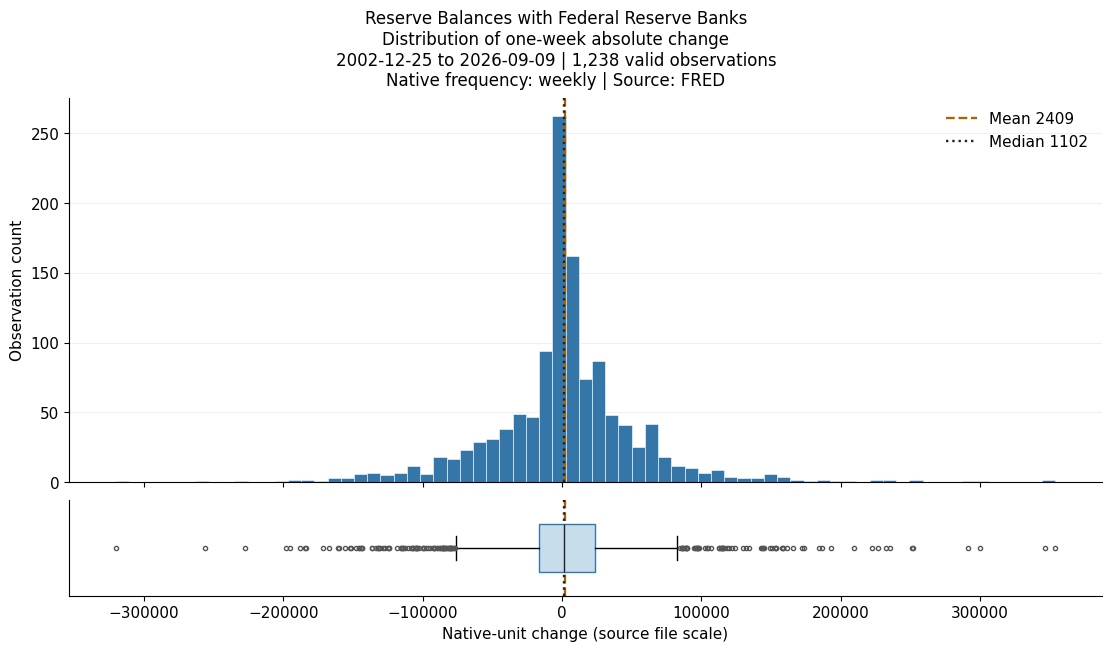

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,1238,"2,409","1,102",5.827e+04,2.069e+04,0.4784,5.924,0


**Diagnostic:** approximately_symmetric; heavy_tailed. Matched-date raw skewness / excess kurtosis: -0.107 / -1.236; delta: 0.478 / 5.924. Smaller moments alone do not establish stationarity or benchmark suitability.

In [106]:
plot_distribution('WRESBAL', 'absolute_delta')

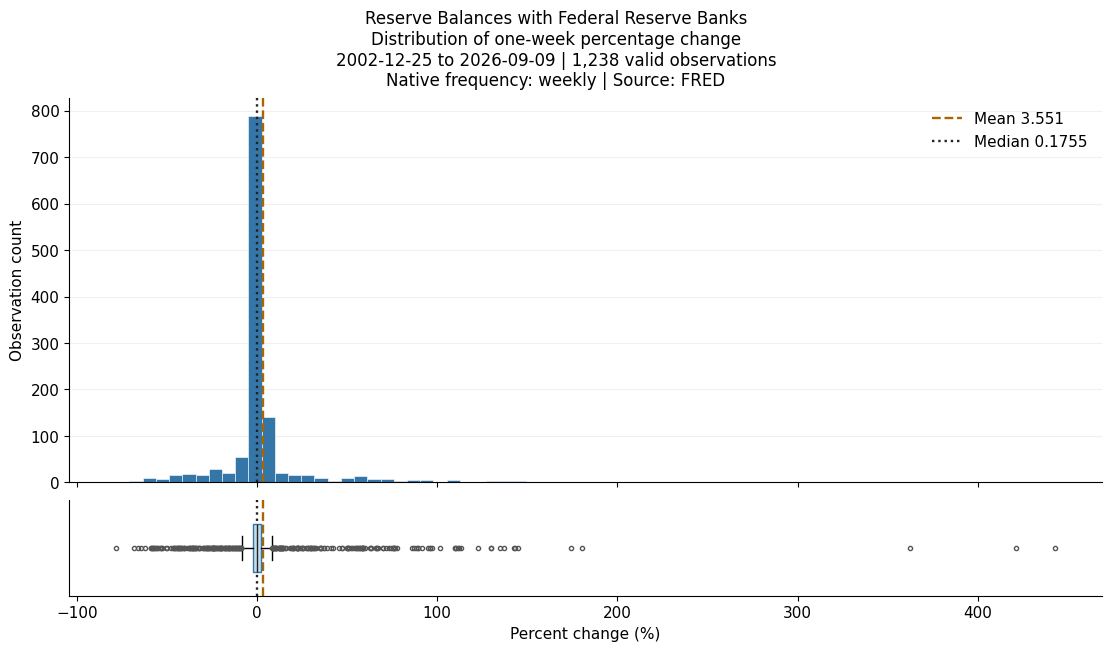

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,1238,3.551,0.1755,31.64,2.168,6.345,70.77,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: -0.107 / -1.236; delta: 6.345 / 70.775. Smaller moments alone do not establish stationarity or benchmark suitability.

In [107]:
plot_distribution('WRESBAL', 'percentage_change')

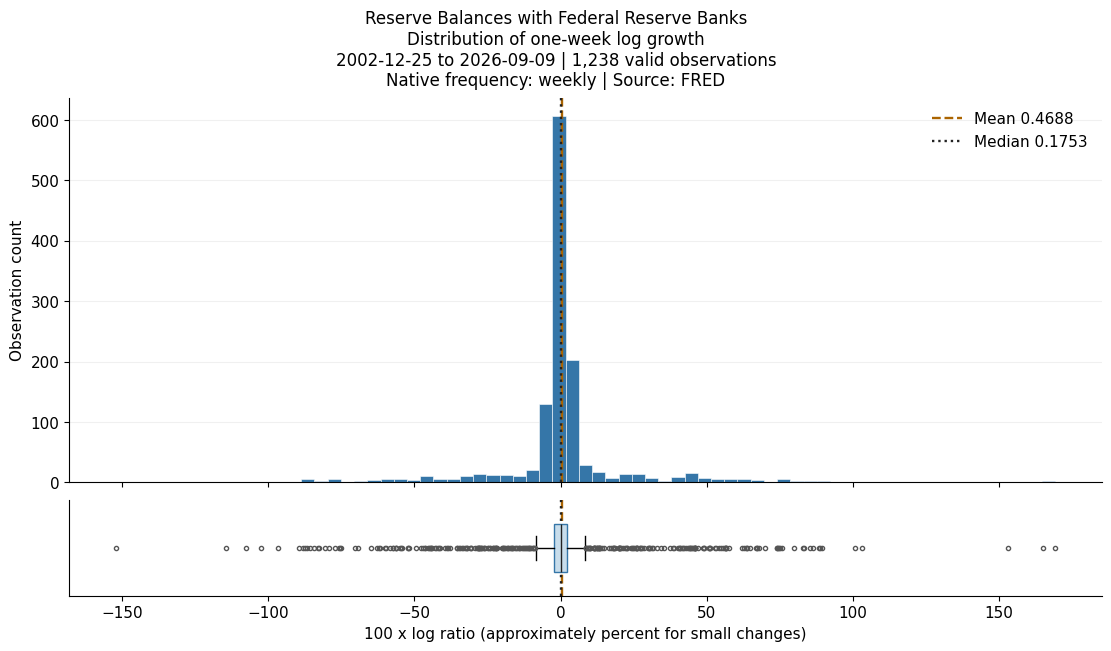

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,1238,0.4688,0.1753,23.5,2.164,0.4573,11.48,0


**Diagnostic:** approximately_symmetric; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: -0.107 / -1.236; delta: 0.457 / 11.478. Smaller moments alone do not establish stationarity or benchmark suitability.

In [108]:
plot_distribution('WRESBAL', 'log_change')

In [109]:
dataset_header('WALCL')

---
### WALCL - Federal Reserve Total Assets

**Economic meaning:** Measures the total assets on the Federal Reserve balance sheet.

**Raw distribution observation:** Skewness 0.364; excess kurtosis -1.037; minimum 7.128e+05; maximum 8.965e+06. Histogram moments do not establish trend or stationarity.

**Candidate delta family:** REGIME-SENSITIVE - DELTA ANALYSIS ONLY

**Native frequency:** weekly. **Suitability:** SPECIAL_CASE. Delta is useful, but liquidity/policy regime changes may persist after transformation.

**Transformations shown:**
- one-week absolute change
- one-week percentage change
- one-week log growth

Economic description: Resources.md. Data: cleaned CSV; provider recorded as FRED.

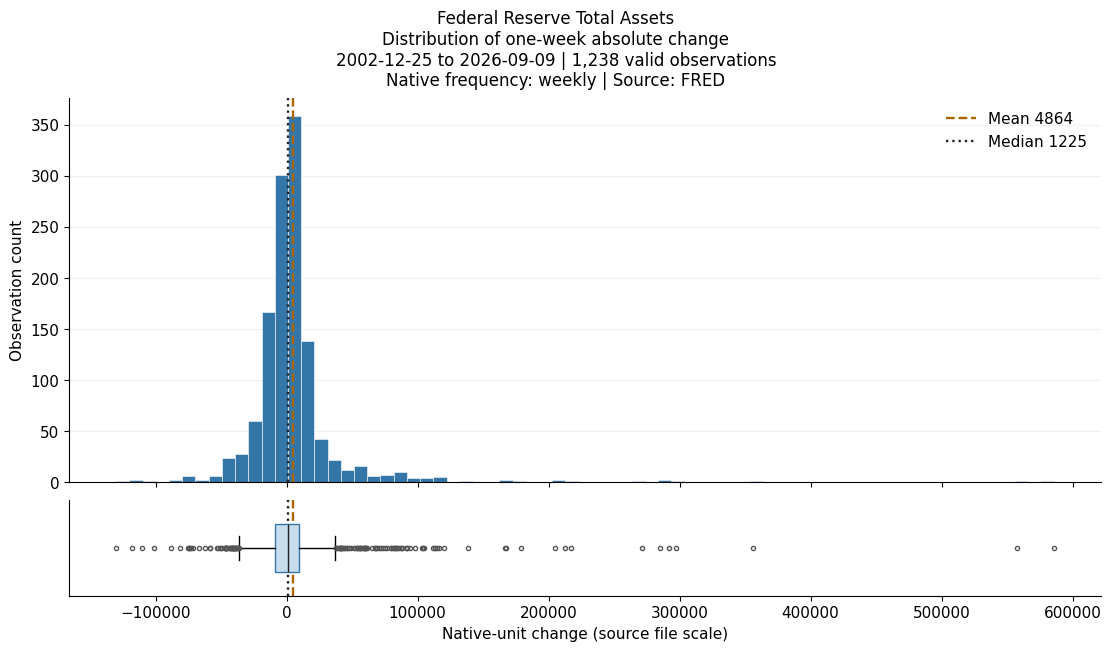

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
absolute_delta,1238,"4,864","1,225",4.085e+04,"9,190",6.508,72.8,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.363 / -1.037; delta: 6.508 / 72.803. Smaller moments alone do not establish stationarity or benchmark suitability.

In [110]:
plot_distribution('WALCL', 'absolute_delta')

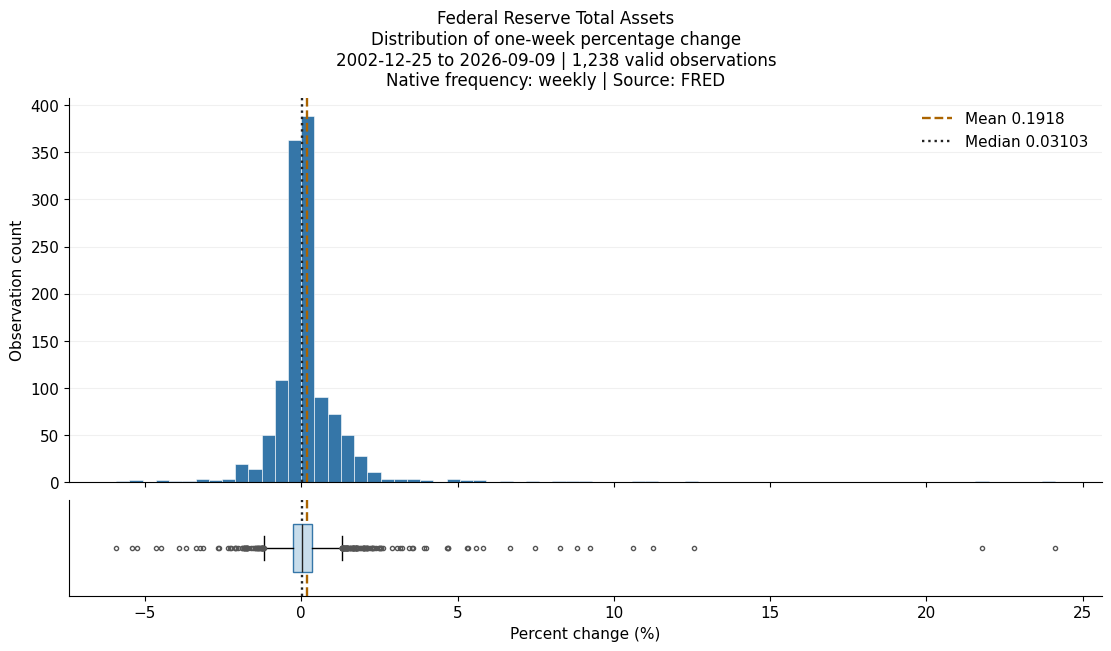

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
percentage_change,1238,0.1918,0.03103,1.525,0.3073,7.033,91.37,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.363 / -1.037; delta: 7.033 / 91.369. Smaller moments alone do not establish stationarity or benchmark suitability.

In [111]:
plot_distribution('WALCL', 'percentage_change')

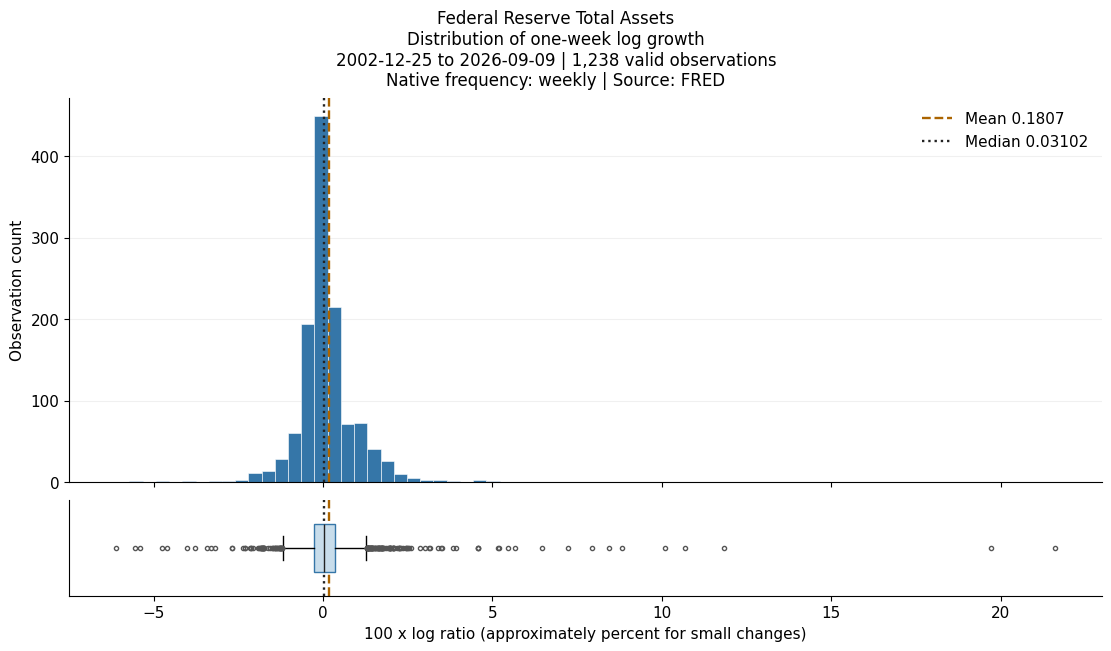

transformation,observations,mean,median,std,MAD,skewness,kurtosis,gap_pairs_skipped
log_change,1238,0.1807,0.03102,1.452,0.3071,6.142,74.95,0


**Diagnostic:** right_skewed; highly_heavy_tailed. Matched-date raw skewness / excess kurtosis: 0.363 / -1.037; delta: 6.142 / 74.949. Smaller moments alone do not establish stationarity or benchmark suitability.

In [112]:
plot_distribution('WALCL', 'log_change')

## 8. Transformation Comparison

One row per dataset/transformation. Full moments and quantiles appear first; matched-date raw comparisons and flags follow. The in-memory comparison dataframe also retains suitability reasons, native_frequency, delta_horizon, and every exclusion count. Mean-median gaps are not used as a cross-variable model score.

In [113]:
table(comparison[['series_id','dataset_name','category','frequency','family','transformation','observations',
 'mean','median','std','MAD','minimum','maximum','q01','q05','q10','q25','q50','q75','q90','q95','q99',
 'skewness','kurtosis','mean_minus_median','absolute_mean_median_gap','gap_pairs_skipped']])
table(comparison[['dataset_name','transformation','raw_skewness_matched','skewness','raw_kurtosis_matched','kurtosis',
 'smaller_absolute_skewness','smaller_absolute_kurtosis','nonpositive_skipped','nonfinite_skipped','behavior_label','delta_suitability']])


series_id,dataset_name,category,frequency,family,transformation,observations,mean,median,std,MAD,minimum,maximum,q01,q05,q10,q25,q50,q75,q90,q95,q99,skewness,kurtosis,mean_minus_median,absolute_mean_median_gap,gap_pairs_skipped
INDPRO,Industrial Production,growth_activity,monthly,growth,log_change,1290,0.2365,0.2532,1.9,0.5823,-14.14,15.32,-5.905,-2.411,-1.33,-0.3389,0.2532,0.8071,1.865,2.919,6.012,-0.02418,13.09,-0.01667,0.01667,0
INDPRO,Industrial Production,growth_activity,monthly,growth,percentage_change,1290,0.2549,0.2535,1.907,0.5822,-13.19,16.55,-5.734,-2.382,-1.322,-0.3384,0.2535,0.8104,1.883,2.962,6.197,0.4106,13.87,0.001372,0.001372,0
IPMAN,Manufacturing Production,growth_activity,monthly,growth,log_change,654,0.155,0.1909,1.128,0.4428,-16.69,7.565,-3.244,-1.057,-0.6746,-0.2348,0.1909,0.6654,1.043,1.405,2.102,-5.12,80.14,-0.03591,0.03591,0
IPMAN,Manufacturing Production,growth_activity,monthly,growth,percentage_change,654,0.1614,0.1911,1.1,0.4437,-15.37,7.859,-3.192,-1.052,-0.6724,-0.2345,0.1911,0.6676,1.048,1.415,2.124,-4.225,65.75,-0.02973,0.02973,0
PCEC96,Real Personal Consumption Expenditure,growth_activity,monthly,growth,log_change,234,0.1766,0.1766,1.165,0.1635,-11.59,7.994,-0.9252,-0.367,-0.175,0.02026,0.1766,0.3489,0.5634,0.7766,3.326,-3.535,59.85,-7.15e-05,7.15e-05,0
PCEC96,Real Personal Consumption Expenditure,growth_activity,monthly,growth,percentage_change,234,0.1834,0.1768,1.145,0.1637,-10.95,8.322,-0.921,-0.3663,-0.1748,0.02026,0.1768,0.3495,0.565,0.7796,3.391,-2.681,55.53,0.006607,0.006607,0
W875RX1,Real Personal Income excluding transfers,growth_activity,monthly,growth,log_change,810,0.2375,0.2758,0.6095,0.2329,-6.344,4.017,-1.185,-0.4098,-0.2548,0.02634,0.2758,0.4929,0.6856,0.8935,1.525,-2.822,39.05,-0.03825,0.03825,0
W875RX1,Real Personal Income excluding transfers,growth_activity,monthly,growth,percentage_change,810,0.2397,0.2762,0.606,0.2337,-6.147,4.099,-1.178,-0.409,-0.2545,0.02634,0.2762,0.4941,0.6879,0.8975,1.537,-2.524,36.62,-0.0365,0.0365,0
RPI,Real Personal Income,growth_activity,monthly,growth,log_change,810,0.2563,0.2646,1.159,0.2054,-14.33,18.36,-2.379,-0.4574,-0.2282,0.05853,0.2646,0.4697,0.6709,0.8741,2.405,3.448,122.7,-0.008309,0.008309,0
RPI,Real Personal Income,growth_activity,monthly,growth,percentage_change,810,0.2634,0.2649,1.19,0.2061,-13.35,20.16,-2.35,-0.4564,-0.228,0.05855,0.2649,0.4708,0.6732,0.8779,2.434,5.375,136.8,-0.001509,0.001509,0


dataset_name,transformation,raw_skewness_matched,skewness,raw_kurtosis_matched,kurtosis,smaller_absolute_skewness,smaller_absolute_kurtosis,nonpositive_skipped,nonfinite_skipped,behavior_label,delta_suitability
Industrial Production,log_change,0.3402,-0.02418,-1.391,13.09,True,False,0,0,approximately_symmetric; highly_heavy_tailed,HIGH
Industrial Production,percentage_change,0.3402,0.4106,-1.391,13.87,False,False,0,0,approximately_symmetric; highly_heavy_tailed,HIGH
Manufacturing Production,log_change,-0.3036,-5.12,-1.582,80.14,False,False,0,0,left_skewed; highly_heavy_tailed,HIGH
Manufacturing Production,percentage_change,-0.3036,-4.225,-1.582,65.75,False,False,0,0,left_skewed; highly_heavy_tailed,HIGH
Real Personal Consumption Expenditure,log_change,0.4698,-3.535,-1.099,59.85,False,False,0,0,left_skewed; highly_heavy_tailed,HIGH
Real Personal Consumption Expenditure,percentage_change,0.4698,-2.681,-1.099,55.53,False,False,0,0,left_skewed; highly_heavy_tailed,HIGH
Real Personal Income excluding transfers,log_change,0.3758,-2.822,-1.061,39.05,False,False,0,0,left_skewed; highly_heavy_tailed,HIGH
Real Personal Income excluding transfers,percentage_change,0.3758,-2.524,-1.061,36.62,False,False,0,0,left_skewed; highly_heavy_tailed,HIGH
Real Personal Income,log_change,0.4586,3.448,-0.9547,122.7,False,False,0,0,right_skewed; highly_heavy_tailed,HIGH
Real Personal Income,percentage_change,0.4586,5.375,-0.9547,136.8,False,False,0,0,right_skewed; highly_heavy_tailed,HIGH


## 9. Summary

Lists below are computed from the results. Best-looking is a descriptive screen only: at least 60 observations, absolute skewness <= 0.5, excess kurtosis <= 3, and HIGH/MEDIUM economic suitability. Problematic means absolute skewness > 1, excess kurtosis > 10, insufficient history, or undefined moments. Candidates between these screens remain unclassified. No variable is removed or final winner selected.

In [114]:
display(Markdown(f'**Total cleaned datasets: {len(inventory)}. Candidate transformations: {len(comparison)}.**'))
table(pd.DataFrame([{'family':FAMILY_NAMES[k],'datasets':len(v)} for k,v in FAMILY_IDS.items()]))
best=comparison.loc[(comparison.observations>=60)&(comparison.skewness.abs()<=0.5)&(comparison["kurtosis"]<=3)&comparison["kurtosis"].notna()&comparison.delta_suitability.isin(['HIGH','MEDIUM'])]
problematic=comparison.loc[(comparison.skewness.abs()>1)|(comparison["kurtosis"]>10)|(comparison.observations<60)|comparison.skewness.isna()|comparison["kurtosis"].isna()]
for title,frame in [('Best-looking delta candidates under the descriptive screen',best),('Problematic delta candidates under the descriptive screen',problematic)]:
    display(Markdown('### '+title))
    if frame.empty: display(Markdown('No candidates meet this screen; this does not establish economic usefulness.'))
    else: table(frame[['dataset_name','transformation','frequency','observations','skewness','kurtosis','behavior_label']])
improved=comparison.smaller_absolute_skewness & comparison.smaller_absolute_kurtosis
display(Markdown(f'**Matched-date shape comparison:** {improved.sum()} of {len(comparison)} candidates reduce both absolute skewness and absolute excess kurtosis relative to raw ending-date levels. This is shape evidence only, not a stationarity, multimodality, independence, or regime-stability test.'))
display(Markdown('### Variables requiring special treatment'))
table(inventory.loc[inventory.delta_suitability.eq('SPECIAL_CASE'),['dataset_name','candidate_delta_family','reason']])
display(Markdown('### Variables likely requiring regime-aware analysis later'))
table(inventory.loc[inventory.series_id.isin(FAMILY_IDS['regime_sensitive']),['dataset_name','reason']])
display(Markdown('Growth candidates express proportional movement; rates/hours express native point changes. Housing retains both alternatives. Claims and delinquency retain stress-event interpretation. Lending standards/demand retain meaningful levels alongside momentum. Liquidity variables need policy-regime investigation. Other families may also contain breaks; this study does not test or rule them out. Crisis observations remain included.'))


**Total cleaned datasets: 36. Candidate transformations: 71.**

family,datasets
Log-growth / percentage-growth mode,23
First-difference mode,6
Exploratory stress delta,2
Semantic-balance mode,2
REGIME-SENSITIVE - DELTA ANALYSIS ONLY,3


### Best-looking delta candidates under the descriptive screen

dataset_name,transformation,frequency,observations,skewness,kurtosis,behavior_label
Housing Starts,log_change,monthly,811,-0.1868,0.7531,approximately_symmetric
Housing Starts,percentage_change,monthly,811,0.1438,0.6778,approximately_symmetric
Housing Starts,absolute_delta,monthly,811,-0.273,1.525,approximately_symmetric
Building Permits,log_change,monthly,799,-0.1963,2.73,approximately_symmetric
Building Permits,absolute_delta,monthly,799,-0.2945,2.588,approximately_symmetric
Job Openings,log_change,monthly,307,-0.217,1.601,approximately_symmetric
Job Openings,percentage_change,monthly,307,0.07276,1.444,approximately_symmetric
Producer Prices — Final Demand,log_change,monthly,201,0.4104,1.298,approximately_symmetric
Producer Prices — Final Demand,percentage_change,monthly,201,0.4303,1.333,approximately_symmetric
Nonfarm Business Sector Labor Productivity,log_change,quarterly,317,0.4729,2.511,approximately_symmetric


### Problematic delta candidates under the descriptive screen

...

### Variables requiring special treatment

dataset_name,candidate_delta_family,reason
Initial Claims,Exploratory stress delta,Event-sensitive stress measure; right tails do not automatically indicate secular growth. Compare absolute and proportional changes.
SLOOS: Banks Tightening C&I Lending Standards,Semantic-balance mode,"Native zero remains economically meaningful. Delta measures momentum, not a replacement for the level."
SLOOS: Stronger Demand for C&I Loans,Semantic-balance mode,"Native zero remains economically meaningful. Delta measures momentum, not a replacement for the level."
Delinquency Rate on Business Loans,Exploratory stress delta,Event-sensitive stress measure; right tails do not automatically indicate secular growth. Compare absolute and proportional changes.
Total Bank Reserves,REGIME-SENSITIVE - DELTA ANALYSIS ONLY,"Delta is useful, but liquidity/policy regime changes may persist after transformation."
Reserve Balances with Federal Reserve Banks,REGIME-SENSITIVE - DELTA ANALYSIS ONLY,"Delta is useful, but liquidity/policy regime changes may persist after transformation."
Federal Reserve Total Assets,REGIME-SENSITIVE - DELTA ANALYSIS ONLY,"Delta is useful, but liquidity/policy regime changes may persist after transformation."


### Variables likely requiring regime-aware analysis later

dataset_name,reason
Total Bank Reserves,"Delta is useful, but liquidity/policy regime changes may persist after transformation."
Reserve Balances with Federal Reserve Banks,"Delta is useful, but liquidity/policy regime changes may persist after transformation."
Federal Reserve Total Assets,"Delta is useful, but liquidity/policy regime changes may persist after transformation."


Growth candidates express proportional movement; rates/hours express native point changes. Housing retains both alternatives. Claims and delinquency retain stress-event interpretation. Lending standards/demand retain meaningful levels alongside momentum. Liquidity variables need policy-regime investigation. Other families may also contain breaks; this study does not test or rule them out. Crisis observations remain included.

### Future Position / Velocity / Acceleration architecture

- Position: current economic level/state and its meaningful native zero, if any.
- Velocity: one native-step first difference or growth, as explored here.
- Acceleration: change in a selected velocity. A later study must require consecutive native periods and two valid component velocities, preserving gap masks.

Acceleration columns and plots are deferred until a velocity definition is chosen. Future rolling references must use information available at the evaluation date and account for revisions, release timing, and regimes. This study sets no zero point, expected baseline, rolling benchmark, z-score, composite, or model.

In [115]:
assert len(rendered_figures)==len(set(rendered_figures))==len(comparison)==71
assert set(raw_data)==set(registry)==set(inventory.series_id)
assert all(sha256(ROOT/path)==digest for path,digest in source_hashes.items())
print('Verified: 36 datasets, 71 inline distributions; cleaned inputs and reference files unchanged.')
print('Python',platform.python_version(),'| pandas',pd.__version__,'| NumPy',np.__version__,'| matplotlib',matplotlib.__version__)
provenance=pd.DataFrame([{'source_file':p,'sha256':h} for p,h in source_hashes.items()])
table(provenance)


Verified: 36 datasets, 71 inline distributions; cleaned inputs and reference files unchanged.
Python 3.14.2 | pandas 3.0.2 | NumPy 2.4.4 | matplotlib 3.10.8


source_file,sha256
data\cleaned\AWHAETP.csv,5e13c1384dcc2272a903fd01464b109170018146f7afe13ea93198b611b19db6
data\cleaned\AWHMAN.csv,d3a322ac9f4b42e5bd36c4117ced5105e802fa10b1c3e076d0dafb9fc5aa9442
data\cleaned\BUSLOANS.csv,9d14679f234a1ebd4e70ba1ded2058d603f124346c94fe25dbd17848348a476d
data\cleaned\CES0500000003.csv,201bb613a88d01db0e3fbc32d6b05c37c157374949579365938492cd936f10cf
data\cleaned\CIVPART.csv,123f1eede7f58a87a9848d607a58b5f3e76295ec738d3da71bc70d4715261f96
data\cleaned\CPIAUCSL.csv,d5fc9dbc3e150588c79182f78e6cb2745ea71651801e44c8ce3a27102780bab4
data\cleaned\CPILFESL.csv,cc30014eb52b0d8a29ae4be51c712ee4a16ead144209836c27794da46cedb531
data\cleaned\DRBLACBS.csv,f4f7a6624fc95b0be70c963f5cfba106bf3aea5f6cb70b19bd4e497d2e1a6002
data\cleaned\DRSDCILM.csv,e5e251b3b8aae6f80410d9d28ee78017447e794292c293380097dacba7afe13b
data\cleaned\DRTSCILM.csv,967ab7be5634815d82818abbebc17f9e2e037f474b8e33fe07c427dc68904c59
